# H&M Customer Analytics - Modeling


In [ ]:
# STEP 0: Need Some Packages et al.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import sys
import warnings
import os
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✓ All packages imported successfully")


✓ All packages imported successfully


In [ ]:
# STEP 1: LOAD DATA
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set data path to Cleaned_Datasets folder in Google Drive
data_path = '/content/drive/MyDrive/Cleaned_Datasets'

# Load rfm_utils
rfm_utils_file = os.path.join(data_path, 'rfm_utils.py')
if data_path not in sys.path:
    sys.path.insert(0, data_path)
from rfm_utils import getDataFrame, getIndependentScore

# Load data files
print("Loading data files...")
customers = pd.read_csv(os.path.join(data_path, 'customers_clean.csv'))
articles = pd.read_csv(os.path.join(data_path, 'articles_clean.csv'))
transactions = pd.read_csv(os.path.join(data_path, 'transactions_clean_df.csv'))

print(f"✓ Customers: {len(customers)} records")
print(f"✓ Articles: {len(articles)} records")
print(f"✓ Transactions: {len(transactions)} records")

# Convert date column
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'], errors='coerce')
transactions = transactions.dropna(subset=['t_dat'])

# Filter to recent 6 months only
max_date = transactions['t_dat'].max()
cutoff_date = max_date - pd.DateOffset(months=6)
transactions_recent = transactions[transactions['t_dat'] >= cutoff_date].copy()

print(f"\n✓ Using transactions from {cutoff_date.date()} to {max_date.date()}")
print(f"✓ Recent 6 months transactions: {len(transactions_recent)} records")


Mounted at /content/drive
Loading data files...
✓ Customers: 1371980 records
✓ Articles: 105421 records
✓ Transactions: 28813419 records

✓ Using transactions from 2020-03-22 to 2020-09-22
✓ Recent 6 months transactions: 7450387 records


In [ ]:
# STEP 2a: DATA OVERVIEW & SUMMARY STATISTICS

print("="*80)
print("EXPLORATORY DATA ANALYSIS - DATA OVERVIEW")
print("="*80)

# Display basic information about each dataset
print("\n" + "="*80)
print("1. DATASET OVERVIEW")
print("="*80)

overview_data = {
    'Dataset': ['Customers', 'Articles', 'Transactions (All)', 'Transactions (6-Month)'],
    'Number of Records': [
        len(customers),
        len(articles),
        len(transactions),
        len(transactions_recent)
    ],
    'Date Range': [
        'N/A',
        'N/A',
        f"{transactions['t_dat'].min().date()} to {transactions['t_dat'].max().date()}",
        f"{transactions_recent['t_dat'].min().date()} to {transactions_recent['t_dat'].max().date()}"
    ]
}

overview_df = pd.DataFrame(overview_data)
display(overview_df)

# Display column information
print("\n" + "="*80)
print("2. DATASET STRUCTURE")
print("="*80)

print("\n📊 CUSTOMERS DATASET:")
print(f"   Shape: {customers.shape[0]:,} rows × {customers.shape[1]} columns")
print(f"   Columns: {', '.join(customers.columns.tolist())}")
print(f"\n   First few rows:")
display(customers.head())

print("\n📦 ARTICLES DATASET:")
print(f"   Shape: {articles.shape[0]:,} rows × {articles.shape[1]} columns")
print(f"   Columns: {', '.join(articles.columns.tolist())}")
print(f"\n   First few rows:")
display(articles.head())

print("\n💰 TRANSACTIONS DATASET (6-Month Period):")
print(f"   Shape: {transactions_recent.shape[0]:,} rows × {transactions_recent.shape[1]} columns")
print(f"   Columns: {', '.join(transactions_recent.columns.tolist())}")
print(f"\n   First few rows:")
display(transactions_recent.head())


EXPLORATORY DATA ANALYSIS - DATA OVERVIEW

1. DATASET OVERVIEW


,Dataset,Number of Records,Date Range
0,Customers,1371980,N/A
1,Articles,105421,N/A
2,Transactions (All),28813419,2018-09-20 to 2020-09-22
3,Transactions (6-Month),7450387,2020-03-22 to 2020-09-22



2. DATASET STRUCTURE

📊 CUSTOMERS DATASET:
   Shape: 1,371,980 rows × 7 columns
   Columns: customer_id, fn, active, club_member_status, fashion_news_frequency, age, postal_code

   First few rows:


,customer_id,fn,active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0,0,ACTIVE,NONE,49.000,52043EE2162CF5AA7EE79974281641C6F11A68D276429A...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0,0,ACTIVE,NONE,25.000,2973ABC54DAA8A5F8CCFE9362140C63247C5EEE03F1D93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0,0,ACTIVE,NONE,24.000,64F17E6A330A85798E4998F62D0930D14DB8DB1C054AF6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0,0,ACTIVE,NONE,54.000,5D36574F52495E81F019B680C843C443BD343D5CA5B1C2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,ACTIVE,REGULARLY,52.000,25FA5DDEE9AAC01B35208D01736E57942317D756B32DDD...



📦 ARTICLES DATASET:
   Shape: 105,421 rows × 25 columns
   Columns: article_id, product_code, prod_name, product_type_no, product_type_name, product_group_name, graphical_appearance_no, graphical_appearance_name, colour_group_code, colour_group_name, perceived_colour_value_id, perceived_colour_value_name, perceived_colour_master_id, perceived_colour_master_name, department_no, department_name, index_code, index_name, index_group_no, index_group_name, section_no, section_name, garment_group_no, garment_group_name, detail_desc

   First few rows:


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top,253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt,306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt,306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."



💰 TRANSACTIONS DATASET (6-Month Period):
   Shape: 7,450,387 rows × 5 columns
   Columns: t_dat, customer_id, article_id, price, sales_channel_id

   First few rows:


,t_dat,customer_id,article_id,price,sales_channel_id
21363032,2020-03-22,00075ef36696a7b4ed8c83e22a4bf7ea7c90ee110991ec...,856440001,0.042,2
21363033,2020-03-22,00075ef36696a7b4ed8c83e22a4bf7ea7c90ee110991ec...,756132001,0.042,2
21363034,2020-03-22,00075ef36696a7b4ed8c83e22a4bf7ea7c90ee110991ec...,873915001,0.042,2
21363035,2020-03-22,0007c3ba357b0e54131e54d7a5d619263c5a9e6826308b...,841228001,0.017,2
21363036,2020-03-22,0007c3ba357b0e54131e54d7a5d619263c5a9e6826308b...,832361003,0.014,2


In [ ]:
# STEP 1a: CREATE CUSTOMER FEATURES FROM TRANSACTIONS (NO RFM)

print("="*80)
print("STEP 10: SIMPLE REGRESSION MODELS - FEATURE ENGINEERING")
print("="*80)

# Create customer-level features from transactions (behavioral features only, no RFM)
customer_behavioral = transactions_recent.groupby('customer_id').agg({
    't_dat': ['min', 'max', 'count'],
    'price': ['sum', 'mean', 'std', 'min', 'max'],
    'article_id': 'nunique'
}).reset_index()

customer_behavioral.columns = [
    'customer_id', 'First_Purchase_Date', 'Last_Purchase_Date', 'Transaction_Count',
    'Total_Spend', 'Avg_Transaction_Value', 'Std_Transaction_Value',
    'Min_Transaction_Value', 'Max_Transaction_Value', 'Unique_Articles'
]

# Calculate time-based features
customer_behavioral['Customer_Lifetime_Days'] = (
    customer_behavioral['Last_Purchase_Date'] - customer_behavioral['First_Purchase_Date']
).dt.days
customer_behavioral['Customer_Lifetime_Days'] = customer_behavioral['Customer_Lifetime_Days'].fillna(0)

customer_behavioral['Days_Since_First_Purchase'] = (
    max_date - customer_behavioral['First_Purchase_Date']
).dt.days

customer_behavioral['Days_Since_Last_Purchase'] = (
    max_date - customer_behavioral['Last_Purchase_Date']
).dt.days

# Calculate frequency and spending patterns
customer_behavioral['Months_Active'] = customer_behavioral['Customer_Lifetime_Days'] / 30.0
customer_behavioral['Months_Active'] = customer_behavioral['Months_Active'].replace(0, 1)
customer_behavioral['Purchase_Frequency'] = customer_behavioral['Transaction_Count'] / customer_behavioral['Months_Active']

customer_behavioral['Spend_Range'] = customer_behavioral['Max_Transaction_Value'] - customer_behavioral['Min_Transaction_Value']
customer_behavioral['Spend_CV'] = customer_behavioral['Std_Transaction_Value'] / (customer_behavioral['Avg_Transaction_Value'] + 0.001)  # Coefficient of variation

# Fill missing values
customer_behavioral['Std_Transaction_Value'] = customer_behavioral['Std_Transaction_Value'].fillna(0)
customer_behavioral['Spend_CV'] = customer_behavioral['Spend_CV'].fillna(0)

# Merge with customer demographics
regression_data = customer_behavioral.merge(
    customers[['customer_id', 'age', 'club_member_status', 'fashion_news_frequency', 'fn', 'active']],
    on='customer_id', how='left'
)

# Clean demographic data
regression_data['age'] = pd.to_numeric(regression_data['age'], errors='coerce')
regression_data['age'] = regression_data['age'].fillna(regression_data['age'].median())

regression_data['fn'] = pd.to_numeric(regression_data['fn'], errors='coerce').fillna(0)
regression_data['active'] = pd.to_numeric(regression_data['active'], errors='coerce').fillna(0)

# Create age groups for categorical analysis
regression_data['Age_Group'] = pd.cut(
    regression_data['age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25', '26-35', '36-45', '46-55', '55+']
)

print(f"\n✓ Feature engineering completed")
print(f"  - Total customers: {len(regression_data):,}")
print(f"  - Features created: {len(regression_data.columns)}")
print(f"\nFeature summary:")
display(regression_data[['Transaction_Count', 'Total_Spend', 'Avg_Transaction_Value',
                         'Customer_Lifetime_Days', 'Purchase_Frequency', 'Unique_Articles']].describe())


STEP 10: SIMPLE REGRESSION MODELS - FEATURE ENGINEERING

✓ Feature engineering completed
  - Total customers: 748,053
  - Features created: 23

Feature summary:


,Transaction_Count,Total_Spend,Avg_Transaction_Value,Customer_Lifetime_Days,Purchase_Frequency,Unique_Articles
count,748053.000,748053.000,748053.000,748053.000,748053.000,748053.000
mean,9.960,0.266,0.027,50.235,8.451,9.510
std,12.684,0.372,0.013,57.291,26.667,11.749
min,1.000,0.001,0.001,0.000,0.326,1.000
25%,3.000,0.068,0.020,0.000,2.000,3.000
50%,6.000,0.148,0.025,23.000,3.636,6.000
75%,12.000,0.319,0.032,97.000,6.667,12.000
max,518.000,22.732,0.507,184.000,3060.000,407.000


In [ ]:
# STEP 1b: LINEAR REGRESSION - PREDICTING TOTAL SPEND

print("\n" + "="*80)
print("STEP 10b: LINEAR REGRESSION - PREDICTING TOTAL SPEND")
print("="*80)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Prepare features (exclude RFM-related columns if any exist)
feature_cols = [
    'Transaction_Count', 'Customer_Lifetime_Days', 'Days_Since_First_Purchase',
    'Days_Since_Last_Purchase', 'Purchase_Frequency', 'Unique_Articles',
    'Avg_Transaction_Value', 'Std_Transaction_Value', 'Spend_Range', 'Spend_CV',
    'age', 'fn', 'active'
]

# Handle categorical variables
reg_data_encoded = regression_data.copy()
le_club = LabelEncoder()
le_fashion = LabelEncoder()

reg_data_encoded['club_member_status_encoded'] = le_club.fit_transform(
    reg_data_encoded['club_member_status'].fillna('Unknown')
)
reg_data_encoded['fashion_news_frequency_encoded'] = le_fashion.fit_transform(
    reg_data_encoded['fashion_news_frequency'].fillna('None')
)

feature_cols.extend(['club_member_status_encoded', 'fashion_news_frequency_encoded'])

# Select only features that exist
feature_cols = [col for col in feature_cols if col in reg_data_encoded.columns]

# Prepare data
X_reg = reg_data_encoded[feature_cols].fillna(0)
y_reg = reg_data_encoded['Total_Spend']

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Train linear regression
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_train = lr_model.predict(X_train_reg)
y_pred_test = lr_model.predict(X_test_reg)

# Metrics
r2_train = r2_score(y_train_reg, y_pred_train)
r2_test = r2_score(y_test_reg, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train_reg, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_test))
mae_test = mean_absolute_error(y_test_reg, y_pred_test)

print(f"\n📊 LINEAR REGRESSION RESULTS:")
print(f"  Training R²: {r2_train:.4f}")
print(f"  Test R²: {r2_test:.4f}")
print(f"  Training RMSE: {rmse_train:.4f}")
print(f"  Test RMSE: {rmse_test:.4f}")
print(f"  Test MAE: {mae_test:.4f}")

# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n🔍 TOP 10 MOST IMPORTANT FEATURES (by absolute coefficient):")
display(feature_importance.head(10))


STEP 10b: LINEAR REGRESSION - PREDICTING TOTAL SPEND

📊 LINEAR REGRESSION RESULTS:
  Training R²: 0.9395
  Test R²: 0.9378
  Training RMSE: 0.0918
  Test RMSE: 0.0924
  Test MAE: 0.0428

🔍 TOP 10 MOST IMPORTANT FEATURES (by absolute coefficient):


,Feature,Coefficient
8,Spend_Range,3.472
7,Std_Transaction_Value,2.252
6,Avg_Transaction_Value,2.160
9,Spend_CV,-0.303
0,Transaction_Count,0.032
5,Unique_Articles,-0.007
11,fn,-0.003
14,fashion_news_frequency_encoded,-0.001
12,active,0.001
13,club_member_status_encoded,-0.000



STEP 10d: REGRESSION MODEL VISUALIZATIONS


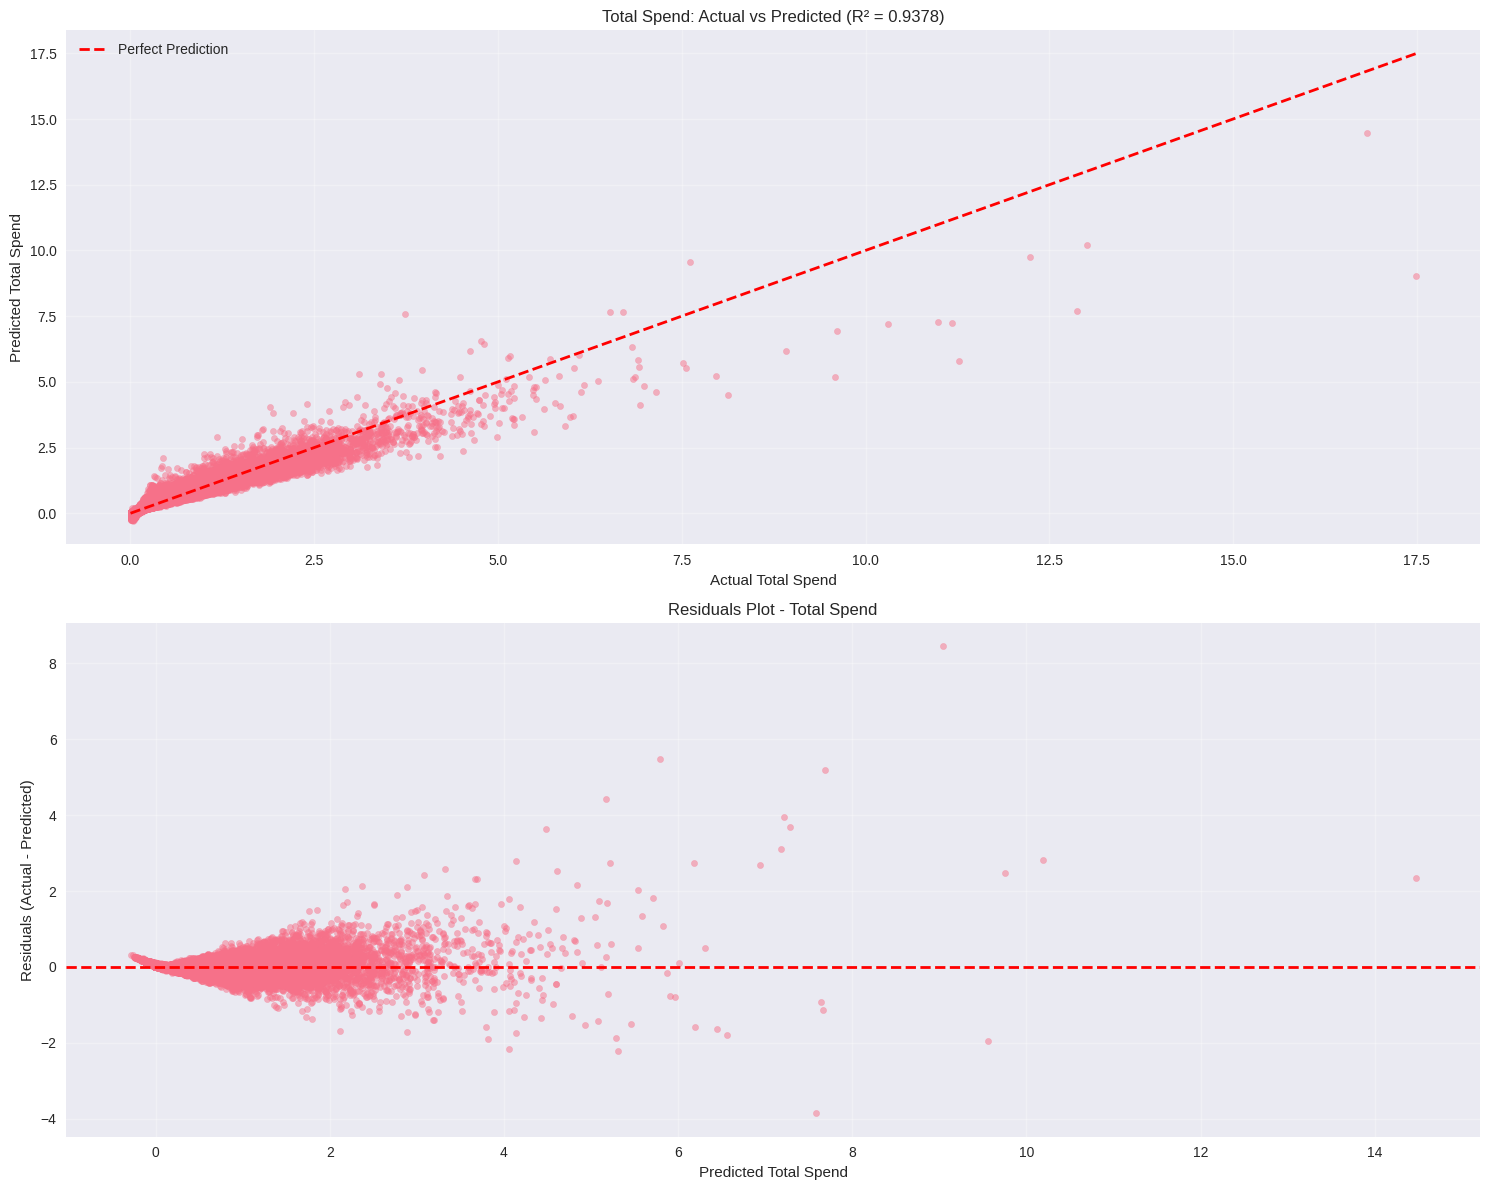

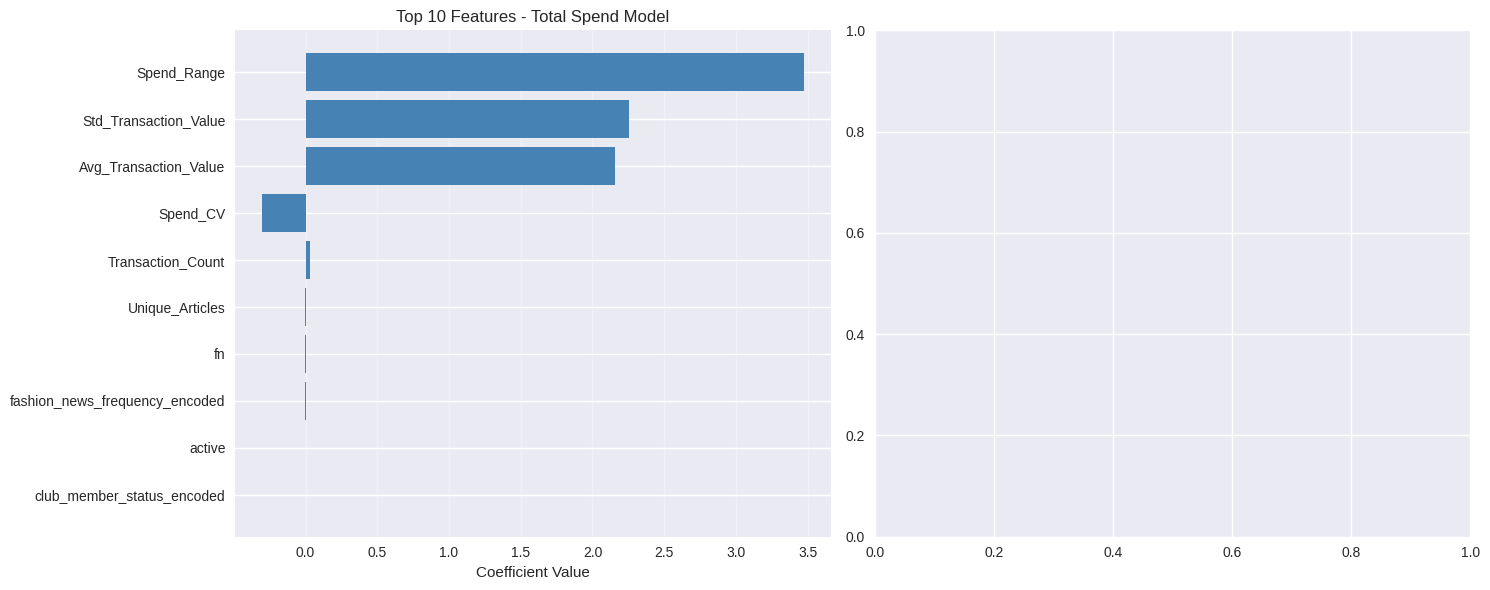


✓ Regression model visualizations created!


In [ ]:
# STEP 1d: REGRESSION MODEL VISUALIZATIONS

print("\n" + "="*80)
print("STEP 10d: REGRESSION MODEL VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 1. Actual vs Predicted - Total Spend
axes[0].scatter(y_test_reg, y_pred_test, alpha=0.5, s=20)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
                [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Total Spend')
axes[0].set_ylabel('Predicted Total Spend')
axes[0].set_title(f'Total Spend: Actual vs Predicted (R² = {r2_test:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residuals Plot - Total Spend
residuals = y_test_reg - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.5, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Total Spend')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residuals Plot - Total Spend')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_features_total = feature_importance.head(10)
axes[0].barh(range(len(top_features_total)), top_features_total['Coefficient'], color='steelblue')
axes[0].set_yticks(range(len(top_features_total)))
axes[0].set_yticklabels(top_features_total['Feature'])
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Top 10 Features - Total Spend Model')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✓ Regression model visualizations created!")

In [ ]:
# STEP 1e: LOGISTIC REGRESSION - PREDICTING HIGH-VALUE CUSTOMERS

print("\n" + "="*80)
print("STEP 10e: LOGISTIC REGRESSION - PREDICTING HIGH-VALUE CUSTOMERS")
print("="*80)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, precision_score, recall_score, f1_score

# Create binary target: High-value customer (above median total spend)
median_spend = regression_data['Total_Spend'].median()
reg_data_encoded['High_Value'] = (reg_data_encoded['Total_Spend'] >= median_spend).astype(int)

print(f"High-value threshold (median): {median_spend:.4f}")
print(f"High-value customers: {reg_data_encoded['High_Value'].sum():,} ({reg_data_encoded['High_Value'].mean()*100:.2f}%)")

# Prepare data
X_log = reg_data_encoded[feature_cols].fillna(0)
y_log = reg_data_encoded['High_Value']

# Split data
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.3, random_state=42, stratify=y_log
)

# Train logistic regression
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_model.fit(X_train_log, y_train_log)

# Predictions
y_pred_proba_log = log_model.predict_proba(X_test_log)[:, 1]
y_pred_log = log_model.predict(X_test_log)

# Metrics
accuracy_log = accuracy_score(y_test_log, y_pred_log)
roc_auc_log = roc_auc_score(y_test_log, y_pred_proba_log)
precision_log = precision_score(y_test_log, y_pred_log)
recall_log = recall_score(y_test_log, y_pred_log)
f1_log = f1_score(y_test_log, y_pred_log)

print(f"\n📊 LOGISTIC REGRESSION RESULTS (High-Value Customer Prediction):")
print(f"  Accuracy: {accuracy_log:.4f} ({accuracy_log*100:.2f}%)")
print(f"  ROC-AUC: {roc_auc_log:.4f}")
print(f"  Precision: {precision_log:.4f}")
print(f"  Recall: {recall_log:.4f}")
print(f"  F1-Score: {f1_log:.4f}")

# Confusion Matrix
cm_log = confusion_matrix(y_test_log, y_pred_log)
print(f"\n📊 Confusion Matrix:")
print(cm_log)
print(f"\n  True Negatives: {cm_log[0,0]:,}")
print(f"  False Positives: {cm_log[0,1]:,}")
print(f"  False Negatives: {cm_log[1,0]:,}")
print(f"  True Positives: {cm_log[1,1]:,}")

# Feature importance (coefficients)
feature_importance_log = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': log_model.coef_[0],
    'Odds_Ratio': np.exp(log_model.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n🔍 TOP 10 MOST IMPORTANT FEATURES (by absolute coefficient):")
display(feature_importance_log.head(10))


STEP 10e: LOGISTIC REGRESSION - PREDICTING HIGH-VALUE CUSTOMERS
High-value threshold (median): 0.1479
High-value customers: 374,027 (50.00%)

📊 LOGISTIC REGRESSION RESULTS (High-Value Customer Prediction):
  Accuracy: 0.9337 (93.37%)
  ROC-AUC: 0.9843
  Precision: 0.9465
  Recall: 0.9193
  F1-Score: 0.9327

📊 Confusion Matrix:
[[106382   5826]
 [  9057 103151]]

  True Negatives: 106,382
  False Positives: 5,826
  False Negatives: 9,057
  True Positives: 103,151

🔍 TOP 10 MOST IMPORTANT FEATURES (by absolute coefficient):


,Feature,Coefficient,Odds_Ratio
6,Avg_Transaction_Value,35.889,3856368491679012.500
8,Spend_Range,33.120,241890168880667.469
7,Std_Transaction_Value,14.029,1237634.953
14,fashion_news_frequency_encoded,-4.917,0.007
12,active,4.333,76.188
9,Spend_CV,-3.749,0.024
0,Transaction_Count,0.584,1.794
11,fn,0.445,1.560
5,Unique_Articles,0.284,1.328
13,club_member_status_encoded,0.005,1.005



STEP 10g: LOGISTIC REGRESSION VISUALIZATIONS


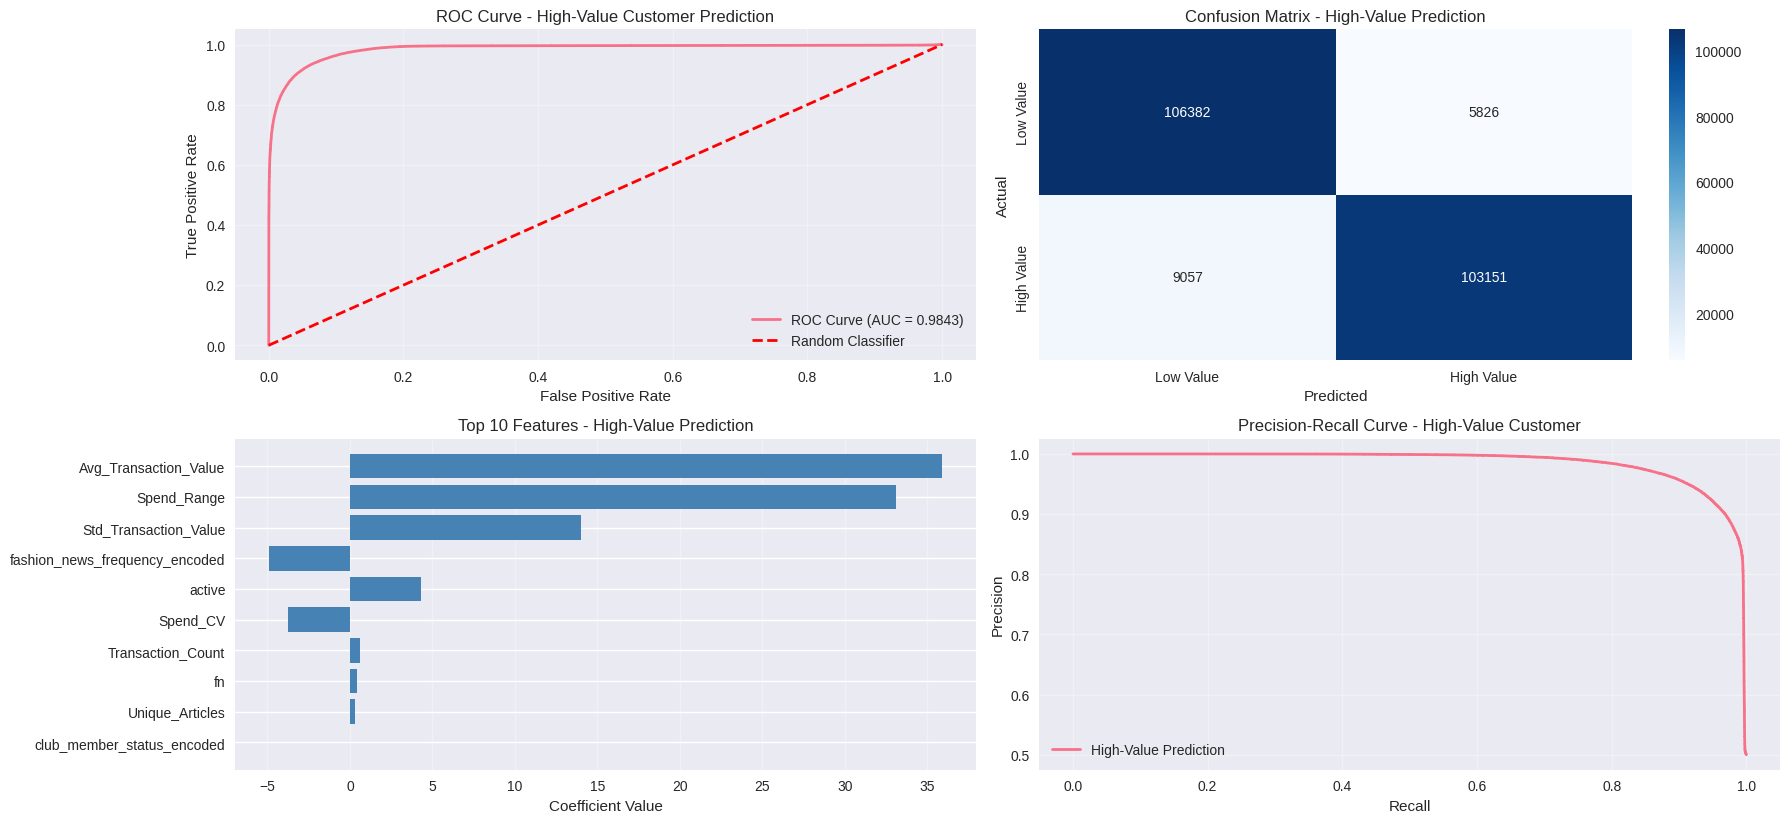


✓ Logistic regression visualizations created!


In [ ]:
# STEP 1: LOGISTIC REGRESSION VISUALIZATIONS

print("\n" + "="*80)
print("STEP 10g: LOGISTIC REGRESSION VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(3, 2, figsize=(18, 12))

# 1. ROC Curve - High-Value Prediction
fpr_log, tpr_log, _ = roc_curve(y_test_log, y_pred_proba_log)
axes[0, 0].plot(fpr_log, tpr_log, label=f'ROC Curve (AUC = {roc_auc_log:.4f})', linewidth=2)
axes[0, 0].plot([0, 1], [0, 1], 'r--', label='Random Classifier', linewidth=2)
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve - High-Value Customer Prediction')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Confusion Matrix - High-Value Prediction
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Low Value', 'High Value'],
            yticklabels=['Low Value', 'High Value'])
axes[0, 1].set_title('Confusion Matrix - High-Value Prediction')
axes[0, 1].set_ylabel('Actual')
axes[0, 1].set_xlabel('Predicted')

# 3. Feature Importance - High-Value Prediction (Moved to axes[1,0])
top_features_log = feature_importance_log.head(10)
axes[1, 0].barh(range(len(top_features_log)), top_features_log['Coefficient'], color='steelblue')
axes[1, 0].set_yticks(range(len(top_features_log)))
axes[1, 0].set_yticklabels(top_features_log['Feature'])
axes[1, 0].set_xlabel('Coefficient Value')
axes[1, 0].set_title('Top 10 Features - High-Value Prediction')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Precision-Recall Curves (Moved to axes[1,1])
precision_curve_log, recall_curve_log, _ = precision_recall_curve(y_test_log, y_pred_proba_log)
axes[1, 1].plot(recall_curve_log, precision_curve_log, label='High-Value Prediction', linewidth=2)
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision-Recall Curve - High-Value Customer')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Remove unused subplots in the third row
fig.delaxes(axes[2, 0])
fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()

print("\n✓ Logistic regression visualizations created!")

## STEP 2: RFM ANALYSIS

**Approach 1**: Manual RFM calculation (without RFM_utils)
- Monetary = Total sum of prices (sum of all transactions)

**Approach 2**: Using RFM_utils functions
- Monetary = Average per transaction (total / frequency)


In [ ]:
# STEP 2a: APPROACH 1 - MANUAL RFM CALCULATION (WITHOUT RFM_UTILS)

print("="*80)
print("APPROACH 1: MANUAL RFM ANALYSIS (WITHOUT RFM_UTILS)")
print("="*80)

# Calculate reference date (day after last transaction)
reference_date = transactions_recent['t_dat'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics for each customer manually
# Monetary = Total sum of prices (sum of all transactions)
rfm_manual = transactions_recent.groupby('customer_id').agg({
    't_dat': lambda x: (reference_date - x.max()).days,  # Recency: days since last purchase
    'article_id': 'count',  # Frequency: number of transactions
    'price': 'sum'  # Monetary: TOTAL SUM of prices (not average)
}).reset_index()

rfm_manual.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

print(f"\nReference date: {reference_date.date()}")
print(f"Customers analyzed: {len(rfm_manual)}")
print("⚠ Note: Monetary = Total sum of prices (sum of all transactions)")
display(rfm_manual.describe())


APPROACH 1: MANUAL RFM ANALYSIS (WITHOUT RFM_UTILS)



Reference date: 2020-09-23
Customers analyzed: 748053
⚠ Note: Monetary = Total sum of prices (sum of all transactions)


,Recency,Frequency,Monetary
count,748053.000,748053.000,748053.000
mean,66.542,9.960,0.266
std,50.838,12.684,0.372
min,1.000,1.000,0.001
25%,22.000,3.000,0.068
50%,56.000,6.000,0.148
75%,99.000,12.000,0.319
max,185.000,518.000,22.732


In [ ]:
# STEP 2b: APPROACH 1 - MANUAL RFM SCORING (WITHOUT RFM_UTILS)

print("="*80)
print("APPROACH 1: MANUAL RFM SCORING")
print("="*80)

# Manual scoring using quintiles (5 groups) for each RFM dimension
# Higher scores are better: R (5=most recent), F (5=most frequent), M (5=highest spending)

# For Recency: Lower is better (more recent), so we reverse the order
# R_Score: 5 = most recent, 1 = least recent
rfm_manual['R_Score'] = pd.qcut(rfm_manual['Recency'].rank(method='first'),
                                 q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')

# For Frequency: Higher is better
# F_Score: 5 = most frequent, 1 = least frequent
rfm_manual['F_Score'] = pd.qcut(rfm_manual['Frequency'].rank(method='first'),
                                q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# For Monetary: Higher is better
# M_Score: 5 = highest spending, 1 = lowest spending
rfm_manual['M_Score'] = pd.qcut(rfm_manual['Monetary'].rank(method='first'),
                                q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Convert scores to numeric
rfm_manual['R_Score'] = pd.to_numeric(rfm_manual['R_Score'], errors='coerce')
rfm_manual['F_Score'] = pd.to_numeric(rfm_manual['F_Score'], errors='coerce')
rfm_manual['M_Score'] = pd.to_numeric(rfm_manual['M_Score'], errors='coerce')

# Calculate total RFM score (simple sum)
rfm_manual['Total_Score'] = rfm_manual['R_Score'] + rfm_manual['F_Score'] + rfm_manual['M_Score']

# Rename for consistency (use ID column name)
rfm_manual_renamed = rfm_manual.rename(columns={'customer_id': 'ID'})

# Display results
print("\nManual RFM Scores (Approach 1):")
display(rfm_manual_renamed.head(10))
display(rfm_manual_renamed.describe())

# Store for later use
rfm_scores_manual = rfm_manual_renamed.copy()


APPROACH 1: MANUAL RFM SCORING

Manual RFM Scores (Approach 1):


,ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_Score
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,18,1,0.051,4,1,1,6
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,77,9,0.203,2,4,4,10
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,8,9,0.413,5,4,5,14
3,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,42,7,0.256,3,3,4,10
4,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,9,2,0.076,5,1,2,8
5,00007d2de826758b65a93dd24ce629ed66842531df6699...,133,10,0.175,1,4,3,8
6,0000945f66de1a11d9447609b8b41b1bc987ba185a5496...,64,2,0.042,3,1,1,5
7,00009c2aeae8761f738e4f937d9be6b49861a66339c2b1...,92,4,0.068,2,2,2,6
8,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,24,43,1.191,4,5,5,14
9,0000b2f1829e23b24feec422ef13df3ccedaedc85368e6...,25,16,0.322,4,5,4,13


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_Score
count,748053.000,748053.000,748053.000,748053.000,748053.000,748053.000,748053.000
mean,66.542,9.960,0.266,3.000,3.000,3.000,9.000
std,50.838,12.684,0.372,1.414,1.414,1.414,3.543
min,1.000,1.000,0.001,1.000,1.000,1.000,3.000
25%,22.000,3.000,0.068,2.000,2.000,2.000,6.000
50%,56.000,6.000,0.148,3.000,3.000,3.000,9.000
75%,99.000,12.000,0.319,4.000,4.000,4.000,12.000
max,185.000,518.000,22.732,5.000,5.000,5.000,15.000


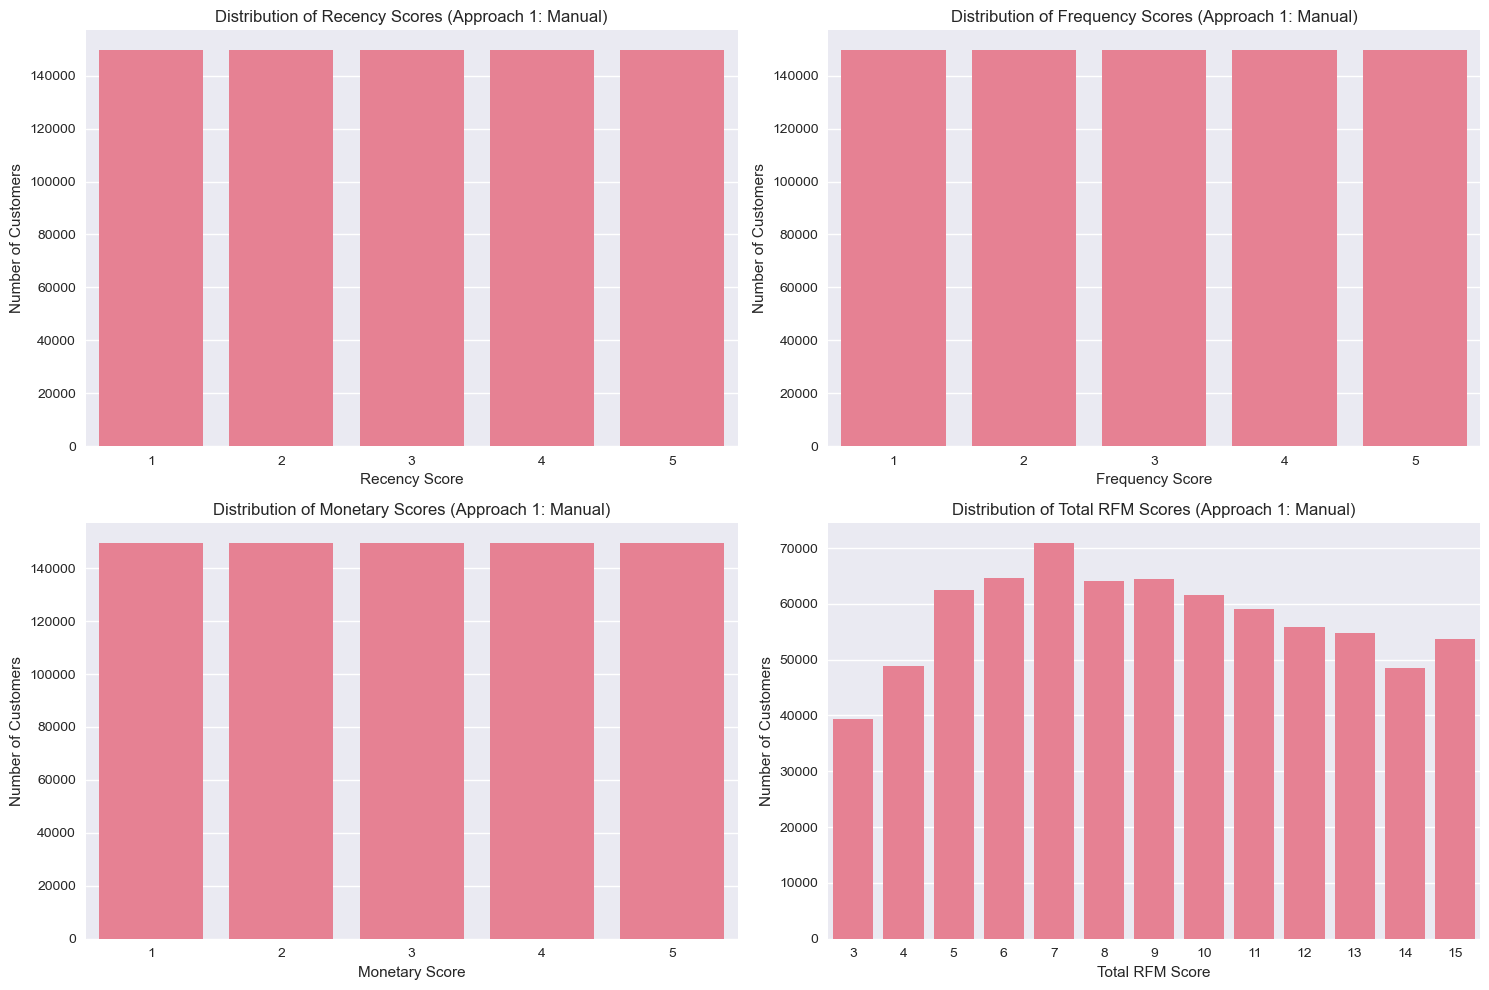

In [ ]:
# STEP 2c: APPROACH 1 - RFM VISUALIZATIONS

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Recency Score Distribution
recency_counts = rfm_scores_manual['R_Score'].value_counts().sort_index()
sns.barplot(x=recency_counts.index, y=recency_counts.values, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Recency Scores (Approach 1: Manual)')
axes[0, 0].set_xlabel('Recency Score')
axes[0, 0].set_ylabel('Number of Customers')

# Frequency Score Distribution
frequency_counts = rfm_scores_manual['F_Score'].value_counts().sort_index()
sns.barplot(x=frequency_counts.index, y=frequency_counts.values, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Frequency Scores (Approach 1: Manual)')
axes[0, 1].set_xlabel('Frequency Score')
axes[0, 1].set_ylabel('Number of Customers')

# Monetary Score Distribution
monetary_counts = rfm_scores_manual['M_Score'].value_counts().sort_index()
sns.barplot(x=monetary_counts.index, y=monetary_counts.values, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Monetary Scores (Approach 1: Manual)')
axes[1, 0].set_xlabel('Monetary Score')
axes[1, 0].set_ylabel('Number of Customers')

# Total RFM Score Distribution
total_counts = rfm_scores_manual['Total_Score'].value_counts().sort_index()
sns.barplot(x=total_counts.index, y=total_counts.values, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Total RFM Scores (Approach 1: Manual)')
axes[1, 1].set_xlabel('Total RFM Score')
axes[1, 1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()


## STEP 2d: APPROACH 2 - RFM ANALYSIS USING RFM_UTILS


In [ ]:
# STEP 2d-1: APPROACH 2 - PREPARE DATA USING getDataFrame FROM RFM_UTILS

print("="*80)
print("APPROACH 2: RFM ANALYSIS USING RFM_UTILS (getDataFrame + getIndependentScore)")
print("="*80)

# Prepare transaction data for getDataFrame function
# getDataFrame expects: ID, Date, Amount columns
transactions_for_rfm = transactions_recent[['customer_id', 't_dat', 'price']].copy()
transactions_for_rfm.columns = ['ID', 'Date', 'Amount']

# Define date range (using the 6-month window we already filtered)
start_date = transactions_recent['t_dat'].min()
end_date = transactions_recent['t_dat'].max()

print(f"Date range: {start_date.date()} to {end_date.date()}")
print(f"Total transactions: {len(transactions_for_rfm)}")

# Use getDataFrame to prepare RFM data
# This function calculates Recency, Frequency, and Monetary automatically
# Note: Monetary = Average per transaction (total / frequency)
rfm_data_utils = getDataFrame(
    df=transactions_for_rfm,
    startDate=start_date,
    endDate=end_date,
    tIDColName="ID",
    tDateColName="Date",
    tAmountColName="Amount"
)

print(f"\n✓ RFM data prepared using getDataFrame from rfm_utils")
print(f"Customers analyzed: {len(rfm_data_utils)}")
print("⚠ Note: Monetary = Average per transaction (total / frequency)")
display(rfm_data_utils.head(10))
display(rfm_data_utils.describe())


APPROACH 2: RFM ANALYSIS USING RFM_UTILS (getDataFrame + getIndependentScore)
Date range: 2020-03-22 to 2020-09-22
Total transactions: 7450387

✓ RFM data prepared using getDataFrame from rfm_utils
Customers analyzed: 748053
⚠ Note: Monetary = Average per transaction (total / frequency)


,ID,Recency,Frequency,Monetary
0,fffef3b6b73545df065b521e19f64bf6fe93bfd450ab20...,0,58,0.031
1,53d5f95331b01525404c3cbb2da6a84e1173dccb979d28...,0,20,0.035
2,53da4b44e81286ed175a46d8ffd5a2baf47843089dc03f...,0,20,0.024
3,53e3114ae37a37e34bff55eee908864ac2ca7b4204c2dc...,0,37,0.021
4,53e3f608cfa494ff8e8c4eef32ff1db92ec76b97e84729...,0,4,0.028
5,53f61faa4c4f2c3e838c226ab57c61142087f69a6b1464...,0,12,0.035
6,53fc32974ae9fb53dc7715aa5f5c21dad233d783d4208c...,0,14,0.024
7,54034a1a90e0235caec1199a6bf52354dc2a34ae654d26...,0,29,0.027
8,540fe0035cc9f36a1b0ee7bd7b2973beae7672cdf214a7...,0,25,0.029
9,53d894ef004472123c51784d6de628ae9efbb823c1295b...,0,2,0.034


,Recency,Frequency,Monetary
count,748053.000,748053.000,748053.000
mean,65.542,9.960,0.027
std,50.838,12.684,0.013
min,0.000,1.000,0.001
25%,21.000,3.000,0.020
50%,55.000,6.000,0.025
75%,98.000,12.000,0.032
max,184.000,518.000,0.507


In [ ]:
# STEP 2d-2: APPROACH 2 - CALCULATE RFM SCORES USING getIndependentScore

print("="*80)
print("APPROACH 2: CALCULATING RFM SCORES USING getIndependentScore")
print("="*80)

# Now use getIndependentScore on the data prepared by getDataFrame
rfm_scores_utils = getIndependentScore(rfm_data_utils)

# Display results
print("\nRFM Scores using rfm_utils (Approach 2):")
display(rfm_scores_utils.head(10))
display(rfm_scores_utils.describe())


APPROACH 2: CALCULATING RFM SCORES USING getIndependentScore

RFM Scores using rfm_utils (Approach 2):


,ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_Score
256647,5a17d6bbd2b841e56daeb0948db85b6c6b8a8ba825df9d...,32,1,0.507,4,1,5,415
22879,1cf6a524209e0802a82c08d31120180652ef00037286d1...,2,1,0.422,5,1,5,515
48629,9cb3f49f58bab8f2ecf974af0f0eb73859251df690c1b0...,4,1,0.422,5,1,5,515
61450,a1ae1531294dfb51c42bdedb20034bbbcf304e295b7568...,5,2,0.422,5,2,5,525
107120,fc0519450ae1cd77ee3be10a19c1d2acc2a2f261857516...,11,1,0.422,5,1,5,515
230839,e3616f75ec810013adedbe6e863458c2fc2dbba663e5d1...,27,1,0.422,4,1,5,415
242662,27a602db8432754b4ca76fc9be7f1b537b2d6422821646...,29,1,0.422,4,1,5,415
575691,950cee57154df8911ddb80b622f62e19a3fd3e8ca46948...,104,1,0.337,2,1,5,215
579422,133ea50c089cece8570c5226d1daf0aeb5db3d7a98fd56...,106,2,0.337,2,1,5,215
686558,8e7b1971ee7a3d2c9d42cb9b082aacf95da5e5940ed8aa...,153,1,0.337,1,1,5,115


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_Score
count,748053.000,748053.000,748053.000,748053.000,748053.000,748053.000,748053.000
mean,65.542,9.960,0.027,3.000,3.000,3.000,332.999
std,50.838,12.684,0.013,1.414,1.414,1.414,148.126
min,0.000,1.000,0.001,1.000,1.000,1.000,111.000
25%,21.000,3.000,0.020,2.000,2.000,2.000,215.000
50%,55.000,6.000,0.025,3.000,3.000,3.000,333.000
75%,98.000,12.000,0.032,4.000,4.000,4.000,452.000
max,184.000,518.000,0.507,5.000,5.000,5.000,555.000


In [ ]:
# STEP 2d-3: COMPARE BOTH RFM APPROACHES

print("="*80)
print("COMPARING BOTH RFM APPROACHES")
print("="*80)

# Compare the two approaches
print("\nApproach 1 (Manual RFM Calculation - WITHOUT rfm_utils):")
print(f"  - Number of customers: {len(rfm_scores_manual)}")
print(f"  - Recency range: {rfm_scores_manual['Recency'].min():.1f} to {rfm_scores_manual['Recency'].max():.1f}")
print(f"  - Frequency range: {rfm_scores_manual['Frequency'].min():.0f} to {rfm_scores_manual['Frequency'].max():.0f}")
print(f"  - Monetary range: {rfm_scores_manual['Monetary'].min():.2f} to {rfm_scores_manual['Monetary'].max():.2f}")
print(f"  - Monetary calculation: Total sum of prices (sum of all transactions)")

print("\nApproach 2 (Using rfm_utils - getDataFrame + getIndependentScore):")
print(f"  - Number of customers: {len(rfm_scores_utils)}")
print(f"  - Recency range: {rfm_scores_utils['Recency'].min():.1f} to {rfm_scores_utils['Recency'].max():.1f}")
print(f"  - Frequency range: {rfm_scores_utils['Frequency'].min():.0f} to {rfm_scores_utils['Frequency'].max():.0f}")
print(f"  - Monetary range: {rfm_scores_utils['Monetary'].min():.2f} to {rfm_scores_utils['Monetary'].max():.2f}")
print(f"  - Monetary calculation: Average per transaction (total / frequency)")

# Compare score distributions
print("\n\nScore Distribution Comparison:")
comparison = pd.DataFrame({
    'Approach1_R_Score': rfm_scores_manual['R_Score'].value_counts().sort_index(),
    'Approach2_R_Score': rfm_scores_utils['R_Score'].value_counts().sort_index(),
    'Approach1_F_Score': rfm_scores_manual['F_Score'].value_counts().sort_index(),
    'Approach2_F_Score': rfm_scores_utils['F_Score'].value_counts().sort_index(),
    'Approach1_M_Score': rfm_scores_manual['M_Score'].value_counts().sort_index(),
    'Approach2_M_Score': rfm_scores_utils['M_Score'].value_counts().sort_index()
}).fillna(0)

display(comparison)


COMPARING BOTH RFM APPROACHES

Approach 1 (Manual RFM Calculation - WITHOUT rfm_utils):
  - Number of customers: 748053
  - Recency range: 1.0 to 185.0
  - Frequency range: 1 to 518
  - Monetary range: 0.00 to 22.73
  - Monetary calculation: Total sum of prices (sum of all transactions)

Approach 2 (Using rfm_utils - getDataFrame + getIndependentScore):
  - Number of customers: 748053
  - Recency range: 0.0 to 184.0
  - Frequency range: 1 to 518
  - Monetary range: 0.00 to 0.51
  - Monetary calculation: Average per transaction (total / frequency)


Score Distribution Comparison:


,Approach1_R_Score,Approach2_R_Score,Approach1_F_Score,Approach2_F_Score,Approach1_M_Score,Approach2_M_Score
1,149611,149613,149611,149613,149611,149613
2,149610,149610,149610,149610,149610,149610
3,149611,149610,149611,149610,149611,149610
4,149610,149610,149610,149610,149610,149610
5,149611,149610,149611,149610,149611,149610


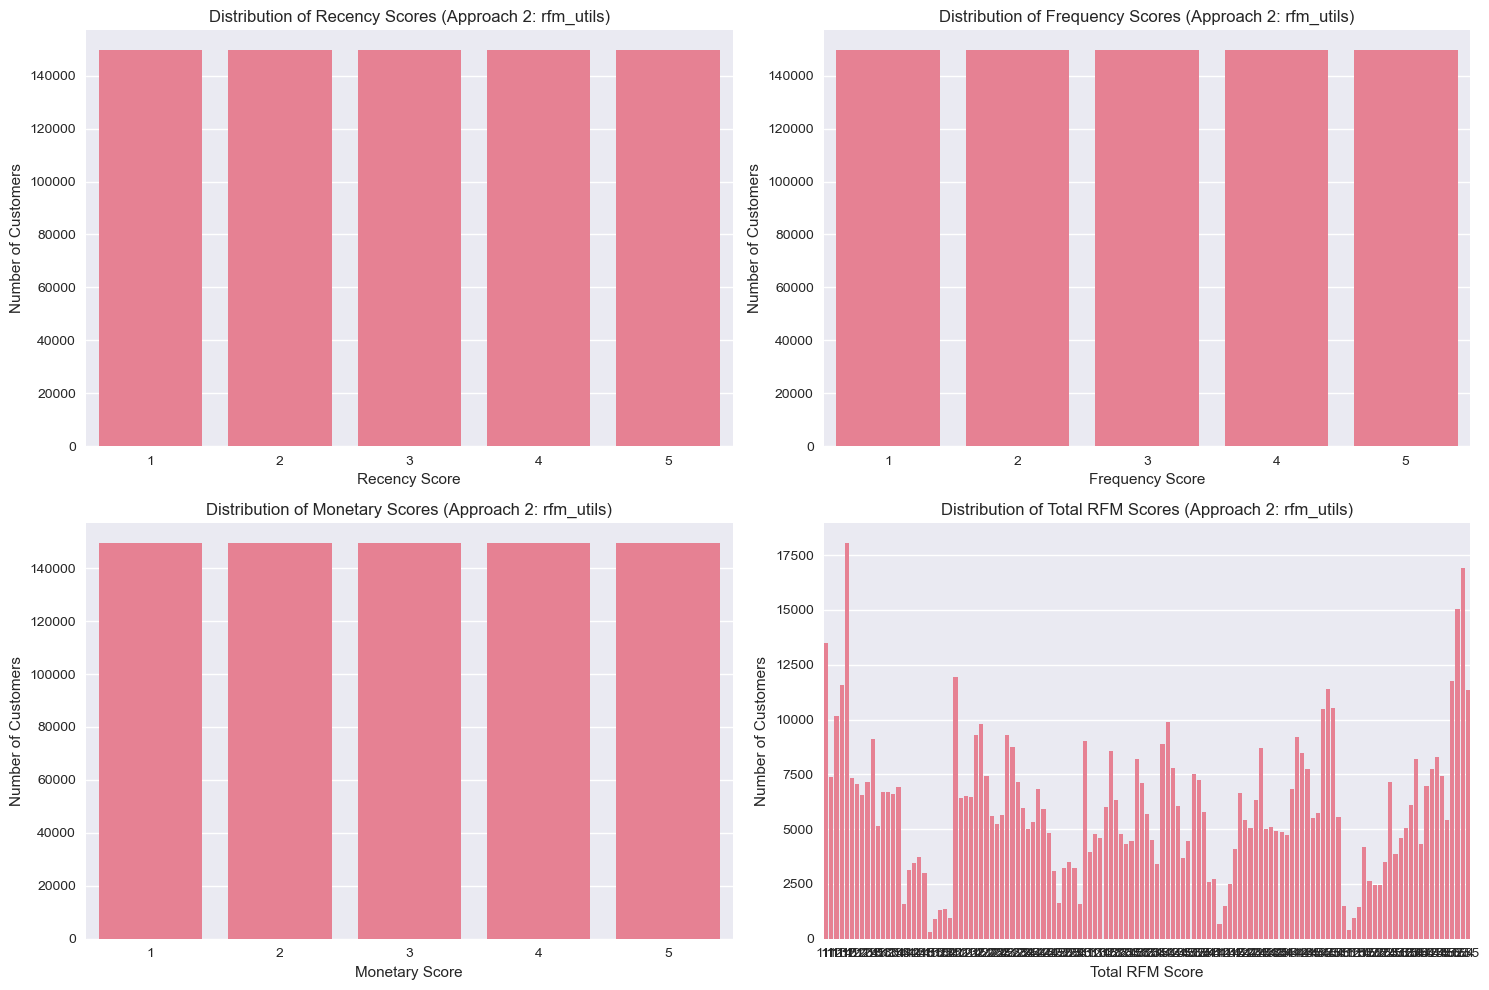

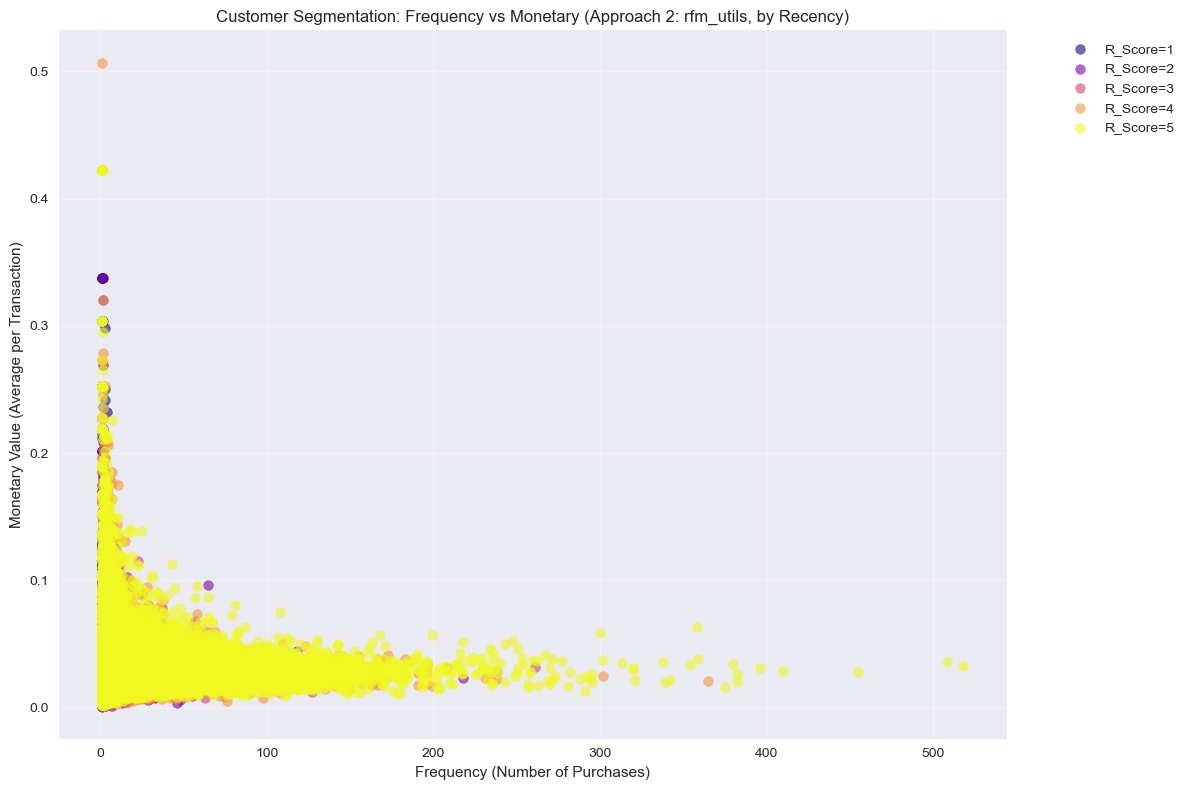


✓ RFM visualizations for Approach 2 created!


In [ ]:
# STEP 2d-4: APPROACH 2 - RFM VISUALIZATIONS

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Recency Score Distribution (Using rfm_utils)
recency_counts_utils = rfm_scores_utils['R_Score'].value_counts().sort_index()
sns.barplot(x=recency_counts_utils.index, y=recency_counts_utils.values, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Recency Scores (Approach 2: rfm_utils)')
axes[0, 0].set_xlabel('Recency Score')
axes[0, 0].set_ylabel('Number of Customers')

# Frequency Score Distribution (Using rfm_utils)
frequency_counts_utils = rfm_scores_utils['F_Score'].value_counts().sort_index()
sns.barplot(x=frequency_counts_utils.index, y=frequency_counts_utils.values, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Frequency Scores (Approach 2: rfm_utils)')
axes[0, 1].set_xlabel('Frequency Score')
axes[0, 1].set_ylabel('Number of Customers')

# Monetary Score Distribution (Using rfm_utils)
monetary_counts_utils = rfm_scores_utils['M_Score'].value_counts().sort_index()
sns.barplot(x=monetary_counts_utils.index, y=monetary_counts_utils.values, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Monetary Scores (Approach 2: rfm_utils)')
axes[1, 0].set_xlabel('Monetary Score')
axes[1, 0].set_ylabel('Number of Customers')

# Total RFM Score Distribution (Using rfm_utils)
total_counts_utils = rfm_scores_utils['Total_Score'].value_counts().sort_index()
sns.barplot(x=total_counts_utils.index, y=total_counts_utils.values, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Total RFM Scores (Approach 2: rfm_utils)')
axes[1, 1].set_xlabel('Total RFM Score')
axes[1, 1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

# Scatter plot: Frequency vs Monetary (Using rfm_utils)
plt.figure(figsize=(12, 8))
recency_scores_utils = rfm_scores_utils['R_Score'].unique()
colors = plt.cm.plasma(np.linspace(0, 1, len(recency_scores_utils)))
for i, r_score in enumerate(sorted(recency_scores_utils)):
    score_data = rfm_scores_utils[rfm_scores_utils['R_Score'] == r_score]
    plt.scatter(score_data['Frequency'], score_data['Monetary'],
               label=f'R_Score={r_score}', alpha=0.6, s=50, color=colors[i])

plt.xlabel('Frequency (Number of Purchases)')
plt.ylabel('Monetary Value (Average per Transaction)')
plt.title('Customer Segmentation: Frequency vs Monetary (Approach 2: rfm_utils, by Recency)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ RFM visualizations for Approach 2 created!")


## STEP 3: LIFETIME VALUE (LTV) ANALYSIS


## STEP 2e: CLOUT AND VULNERABILITY ANALYSIS

**Clout and Vulnerability Analysis** uses RFM scores to identify:
- **Clout**: High-value customers (high Monetary and Frequency) who are influential and valuable
- **Vulnerability**: At-risk customers (low Recency or declining engagement) who may churn

This creates a 2x2 matrix to guide customer retention and engagement strategies.


CLOUT AND VULNERABILITY ANALYSIS
✓ Using RFM scores from manual approach

STEP 1: CALCULATING CLOUT AND VULNERABILITY SCORES

✓ Clout and Vulnerability scores calculated
  Clout Score - Mean: 3.00, Median: 3.00
  Vulnerability Score - Mean: 3.00, Median: 3.00

STEP 2: SEGMENT DISTRIBUTION AND ANALYSIS

📊 SEGMENT DISTRIBUTION:


,Count,Percentage
Clout_Vulnerability_Segment,,
High Clout / Low Vulnerability,214331,28.650
High Clout / High Vulnerability,200107,26.750
Low Clout / High Vulnerability,193692,25.890
Low Clout / Low Vulnerability,139923,18.700



📊 AVERAGE RFM SCORES BY SEGMENT:


,R_Score,F_Score,M_Score,Total_Score,Clout_Score,Vulnerability_Score
Clout_Vulnerability_Segment,,,,,,
High Clout / High Vulnerability,2.180,3.870,3.860,9.910,3.860,3.820
High Clout / Low Vulnerability,4.530,4.270,4.280,13.080,4.280,1.730
Low Clout / High Vulnerability,1.530,1.690,1.640,4.860,1.660,4.220
Low Clout / Low Vulnerability,3.870,1.630,1.700,7.190,1.660,2.080



STEP 3: STRATEGIC RECOMMENDATIONS BY SEGMENT

📋 SEGMENT STRATEGIES:

  High Clout / Low Vulnerability:
    Count: 214,331 (28.6%)
    Description: Champions - High value, actively engaged
    Strategy: Retain and reward. VIP treatment, loyalty programs, exclusive offers
    Priority: Highest

  High Clout / High Vulnerability:
    Count: 200,107 (26.8%)
    Description: At-Risk Champions - High value but showing signs of disengagement
    Strategy: Urgent retention. Win-back campaigns, personalized outreach, special incentives
    Priority: Critical

  Low Clout / Low Vulnerability:
    Count: 139,923 (18.7%)
    Description: Potential Loyalists - Moderate value, stable engagement
    Strategy: Upsell and cross-sell. Increase frequency, introduce new products
    Priority: Medium

  Low Clout / High Vulnerability:
    Count: 193,692 (25.9%)
    Description: Hibernating/Lost - Low value, high churn risk
    Strategy: Reactivation or let go. Low-cost reactivation campaigns, or focus res

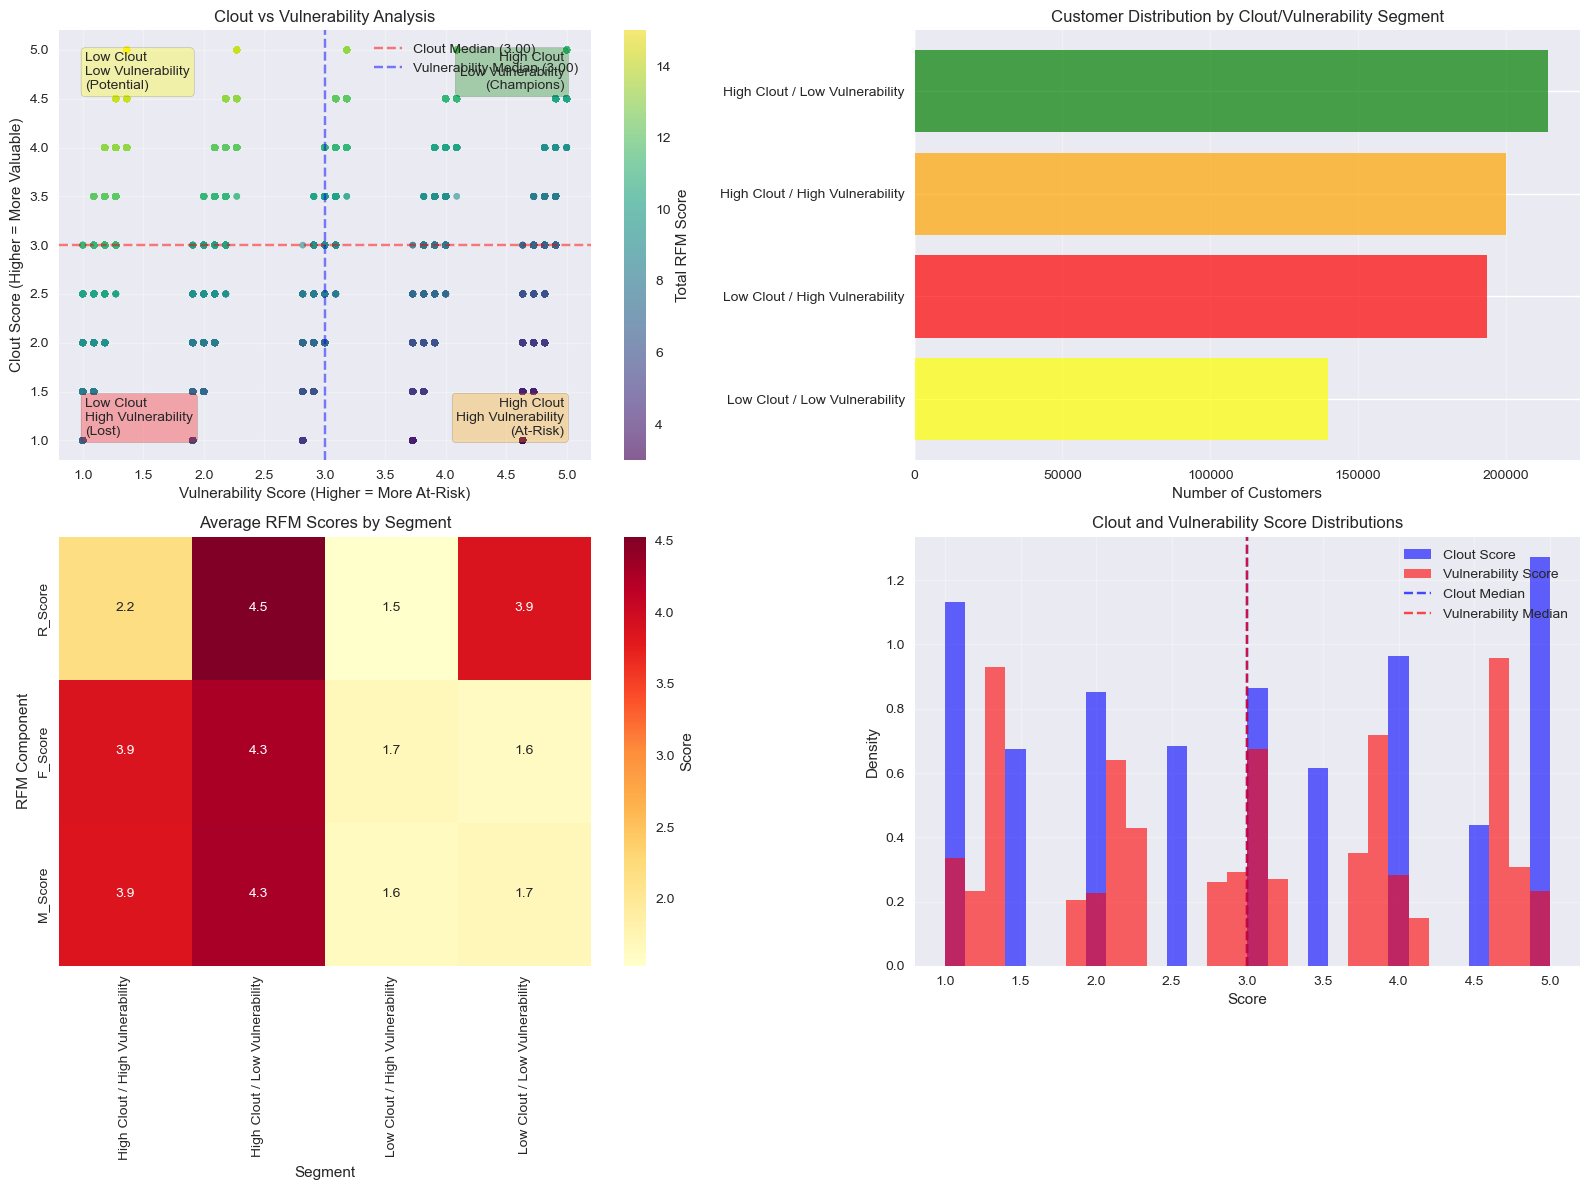


STEP 5: DETAILED SEGMENT PROFILES

📊 TRANSACTION METRICS BY SEGMENT:


,Avg_Transactions,Avg_Revenue,Avg_Transaction_Value,Total_Customers,Total_Revenue
High Clout / High Vulnerability,12.070,0.310,0.030,200107.000,62969.530
High Clout / Low Vulnerability,19.360,0.530,0.030,214331.000,114264.890
Low Clout / High Vulnerability,2.700,0.060,0.020,193692.000,12517.630
Low Clout / Low Vulnerability,2.600,0.070,0.030,139923.000,9436.510



✓ Clout and Vulnerability analysis completed!


In [ ]:
# STEP 2e: CLOUT AND VULNERABILITY ANALYSIS

print("="*80)
print("CLOUT AND VULNERABILITY ANALYSIS")
print("="*80)

# Use RFM scores from manual approach (or utils approach - user can choose)
# Default to manual approach if available
if 'rfm_scores_manual' in globals():
    rfm_for_clout = rfm_scores_manual.copy()
    print("✓ Using RFM scores from manual approach")
elif 'rfm_scores_utils' in globals():
    rfm_for_clout = rfm_scores_utils.copy()
    print("✓ Using RFM scores from rfm_utils approach")
else:
    print("⚠ No RFM scores found. Please run RFM analysis first.")
    rfm_for_clout = None

if rfm_for_clout is not None:
    # ============================================================================
    # STEP 1: CALCULATE CLOUT AND VULNERABILITY SCORES
    # ============================================================================
    print("\n" + "="*80)
    print("STEP 1: CALCULATING CLOUT AND VULNERABILITY SCORES")
    print("="*80)

    # Clout = Combination of Monetary and Frequency (high spenders, frequent buyers)
    # Higher M and F scores = Higher Clout
    rfm_for_clout['Clout_Score'] = (rfm_for_clout['M_Score'] + rfm_for_clout['F_Score']) / 2

    # Vulnerability = Inverse of Recency (low Recency = high vulnerability)
    # Lower R score = Higher Vulnerability (customers who haven't purchased recently)
    # Also consider: customers with high F but low R (engaged but inactive recently)
    rfm_for_clout['Vulnerability_Score'] = (6 - rfm_for_clout['R_Score']) + (rfm_for_clout['F_Score'] / 5) * 0.5
    # Normalize to 0-5 scale
    rfm_for_clout['Vulnerability_Score'] = (rfm_for_clout['Vulnerability_Score'] / rfm_for_clout['Vulnerability_Score'].max()) * 5

    # Create binary classifications (High/Low)
    clout_median = rfm_for_clout['Clout_Score'].median()
    vulnerability_median = rfm_for_clout['Vulnerability_Score'].median()

    rfm_for_clout['Clout_Level'] = rfm_for_clout['Clout_Score'].apply(lambda x: 'High Clout' if x >= clout_median else 'Low Clout')
    rfm_for_clout['Vulnerability_Level'] = rfm_for_clout['Vulnerability_Score'].apply(lambda x: 'High Vulnerability' if x >= vulnerability_median else 'Low Vulnerability')

    # Create combined segment
    rfm_for_clout['Clout_Vulnerability_Segment'] = (
        rfm_for_clout['Clout_Level'] + ' / ' + rfm_for_clout['Vulnerability_Level']
    )

    print(f"\n✓ Clout and Vulnerability scores calculated")
    print(f"  Clout Score - Mean: {rfm_for_clout['Clout_Score'].mean():.2f}, Median: {clout_median:.2f}")
    print(f"  Vulnerability Score - Mean: {rfm_for_clout['Vulnerability_Score'].mean():.2f}, Median: {vulnerability_median:.2f}")

    # ============================================================================
    # STEP 2: SEGMENT ANALYSIS
    # ============================================================================
    print("\n" + "="*80)
    print("STEP 2: SEGMENT DISTRIBUTION AND ANALYSIS")
    print("="*80)

    # Segment distribution
    segment_counts = rfm_for_clout['Clout_Vulnerability_Segment'].value_counts()
    segment_pct = (segment_counts / len(rfm_for_clout) * 100).round(2)

    segment_summary = pd.DataFrame({
        'Count': segment_counts,
        'Percentage': segment_pct
    })

    print("\n📊 SEGMENT DISTRIBUTION:")
    display(segment_summary)

    # Average RFM scores by segment
    segment_rfm = rfm_for_clout.groupby('Clout_Vulnerability_Segment').agg({
        'R_Score': 'mean',
        'F_Score': 'mean',
        'M_Score': 'mean',
        'Total_Score': 'mean',
        'Clout_Score': 'mean',
        'Vulnerability_Score': 'mean'
    }).round(2)

    print("\n📊 AVERAGE RFM SCORES BY SEGMENT:")
    display(segment_rfm)

    # ============================================================================
    # STEP 3: STRATEGIC RECOMMENDATIONS BY SEGMENT
    # ============================================================================
    print("\n" + "="*80)
    print("STEP 3: STRATEGIC RECOMMENDATIONS BY SEGMENT")
    print("="*80)

    segment_strategies = {
        'High Clout / Low Vulnerability': {
            'Description': 'Champions - High value, actively engaged',
            'Strategy': 'Retain and reward. VIP treatment, loyalty programs, exclusive offers',
            'Priority': 'Highest'
        },
        'High Clout / High Vulnerability': {
            'Description': 'At-Risk Champions - High value but showing signs of disengagement',
            'Strategy': 'Urgent retention. Win-back campaigns, personalized outreach, special incentives',
            'Priority': 'Critical'
        },
        'Low Clout / Low Vulnerability': {
            'Description': 'Potential Loyalists - Moderate value, stable engagement',
            'Strategy': 'Upsell and cross-sell. Increase frequency, introduce new products',
            'Priority': 'Medium'
        },
        'Low Clout / High Vulnerability': {
            'Description': 'Hibernating/Lost - Low value, high churn risk',
            'Strategy': 'Reactivation or let go. Low-cost reactivation campaigns, or focus resources elsewhere',
            'Priority': 'Low'
        }
    }

    print("\n📋 SEGMENT STRATEGIES:")
    for segment, strategy in segment_strategies.items():
        if segment in segment_counts.index:
            count = segment_counts[segment]
            pct = segment_pct[segment]
            print(f"\n  {segment}:")
            print(f"    Count: {count:,} ({pct:.1f}%)")
            print(f"    Description: {strategy['Description']}")
            print(f"    Strategy: {strategy['Strategy']}")
            print(f"    Priority: {strategy['Priority']}")

    # ============================================================================
    # STEP 4: VISUALIZATIONS
    # ============================================================================
    print("\n" + "="*80)
    print("STEP 4: VISUALIZATIONS")
    print("="*80)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Clout vs Vulnerability Scatter Plot
    scatter = axes[0, 0].scatter(rfm_for_clout['Vulnerability_Score'], rfm_for_clout['Clout_Score'],
                                c=rfm_for_clout['Total_Score'], cmap='viridis', alpha=0.6, s=20)
    axes[0, 0].axhline(y=clout_median, color='red', linestyle='--', alpha=0.5, label=f'Clout Median ({clout_median:.2f})')
    axes[0, 0].axvline(x=vulnerability_median, color='blue', linestyle='--', alpha=0.5, label=f'Vulnerability Median ({vulnerability_median:.2f})')
    axes[0, 0].set_xlabel('Vulnerability Score (Higher = More At-Risk)')
    axes[0, 0].set_ylabel('Clout Score (Higher = More Valuable)')
    axes[0, 0].set_title('Clout vs Vulnerability Analysis')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, 0], label='Total RFM Score')

    # Add quadrant labels
    axes[0, 0].text(0.95, 0.95, 'High Clout\nLow Vulnerability\n(Champions)',
                    transform=axes[0, 0].transAxes, fontsize=10,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))
    axes[0, 0].text(0.95, 0.05, 'High Clout\nHigh Vulnerability\n(At-Risk)',
                    transform=axes[0, 0].transAxes, fontsize=10,
                    verticalalignment='bottom', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))
    axes[0, 0].text(0.05, 0.95, 'Low Clout\nLow Vulnerability\n(Potential)',
                    transform=axes[0, 0].transAxes, fontsize=10,
                    verticalalignment='top', horizontalalignment='left',
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    axes[0, 0].text(0.05, 0.05, 'Low Clout\nHigh Vulnerability\n(Lost)',
                    transform=axes[0, 0].transAxes, fontsize=10,
                    verticalalignment='bottom', horizontalalignment='left',
                    bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

    # 2. Segment Distribution (Bar Chart)
    segment_counts_sorted = segment_counts.sort_values(ascending=False)
    colors_map = {
        'High Clout / Low Vulnerability': 'green',
        'High Clout / High Vulnerability': 'orange',
        'Low Clout / Low Vulnerability': 'yellow',
        'Low Clout / High Vulnerability': 'red'
    }
    colors = [colors_map.get(seg, 'gray') for seg in segment_counts_sorted.index]
    axes[0, 1].barh(range(len(segment_counts_sorted)), segment_counts_sorted.values, color=colors, alpha=0.7)
    axes[0, 1].set_yticks(range(len(segment_counts_sorted)))
    axes[0, 1].set_yticklabels(segment_counts_sorted.index)
    axes[0, 1].set_xlabel('Number of Customers')
    axes[0, 1].set_title('Customer Distribution by Clout/Vulnerability Segment')
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(True, alpha=0.3, axis='x')

    # 3. Average RFM Scores by Segment (Heatmap)
    segment_rfm_plot = segment_rfm[['R_Score', 'F_Score', 'M_Score']]
    sns.heatmap(segment_rfm_plot.T, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1, 0], cbar_kws={'label': 'Score'})
    axes[1, 0].set_title('Average RFM Scores by Segment')
    axes[1, 0].set_ylabel('RFM Component')
    axes[1, 0].set_xlabel('Segment')

    # 4. Clout and Vulnerability Score Distributions
    axes[1, 1].hist(rfm_for_clout['Clout_Score'], bins=30, alpha=0.6, label='Clout Score', color='blue', density=True)
    axes[1, 1].hist(rfm_for_clout['Vulnerability_Score'], bins=30, alpha=0.6, label='Vulnerability Score', color='red', density=True)
    axes[1, 1].axvline(x=clout_median, color='blue', linestyle='--', alpha=0.7, label=f'Clout Median')
    axes[1, 1].axvline(x=vulnerability_median, color='red', linestyle='--', alpha=0.7, label=f'Vulnerability Median')
    axes[1, 1].set_xlabel('Score')
    axes[1, 1].set_ylabel('Density')
    axes[1, 1].set_title('Clout and Vulnerability Score Distributions')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ============================================================================
    # STEP 5: DETAILED SEGMENT PROFILES
    # ============================================================================
    print("\n" + "="*80)
    print("STEP 5: DETAILED SEGMENT PROFILES")
    print("="*80)

    # Merge with transaction data if available to get additional metrics
    if 'transactions_recent' in globals():
        # Calculate additional metrics by segment
        # Check which column name is used for customer ID
        customer_id_col = 'ID' if 'ID' in rfm_for_clout.columns else 'customer_id'
        segment_customer_ids = rfm_for_clout.groupby('Clout_Vulnerability_Segment')[customer_id_col].apply(list).to_dict()

        segment_metrics = {}
        for segment, customer_list in segment_customer_ids.items():
            segment_trans = transactions_recent[transactions_recent['customer_id'].isin(customer_list)]
            if len(segment_trans) > 0:
                segment_metrics[segment] = {
                    'Avg_Transactions': segment_trans.groupby('customer_id').size().mean(),
                    'Avg_Revenue': segment_trans.groupby('customer_id')['price'].sum().mean(),
                    'Avg_Transaction_Value': segment_trans['price'].mean(),
                    'Total_Customers': len(customer_list),
                    'Total_Revenue': segment_trans['price'].sum()
                }

        if segment_metrics:
            segment_metrics_df = pd.DataFrame(segment_metrics).T
            print("\n📊 TRANSACTION METRICS BY SEGMENT:")
            display(segment_metrics_df.round(2))

    print("\n✓ Clout and Vulnerability analysis completed!")

    # Store results for later use
    clout_vulnerability_analysis = rfm_for_clout.copy()

else:
    print("⚠ Cannot perform Clout and Vulnerability analysis without RFM scores.")


In [ ]:
# STEP 3a: CALCULATE LIFETIME VALUE

print("="*80)
print("LIFETIME VALUE ANALYSIS")
print("="*80)

# Calculate customer-level metrics for LTV
customer_ltv = transactions_recent.groupby('customer_id').agg({
    'price': ['sum', 'mean', 'count'],  # Total revenue, avg transaction value, transaction count
    't_dat': ['min', 'max']  # First and last purchase dates
}).reset_index()

customer_ltv.columns = ['customer_id', 'Total_Revenue', 'Avg_Transaction_Value',
                        'Transaction_Count', 'First_Purchase', 'Last_Purchase']

# Calculate customer lifetime (days)
customer_ltv['Customer_Lifetime_Days'] = (customer_ltv['Last_Purchase'] -
                                          customer_ltv['First_Purchase']).dt.days
customer_ltv['Customer_Lifetime_Days'] = customer_ltv['Customer_Lifetime_Days'].fillna(0)

# Calculate average purchase frequency (purchases per month)
customer_ltv['Months_Active'] = customer_ltv['Customer_Lifetime_Days'] / 30.0
customer_ltv['Months_Active'] = customer_ltv['Months_Active'].replace(0, 1)  # Avoid division by zero
customer_ltv['Purchase_Frequency'] = customer_ltv['Transaction_Count'] / customer_ltv['Months_Active']

# Simple LTV calculation: Total Revenue (using standardized price values)
customer_ltv['LTV'] = customer_ltv['Total_Revenue']

# Merge with RFM scores (using manual approach)
customer_ltv = customer_ltv.merge(rfm_scores_manual[['ID', 'R_Score', 'F_Score', 'M_Score', 'Total_Score']],
                                  left_on='customer_id', right_on='ID', how='left')

print(f"\nLTV Summary Statistics:")
display(customer_ltv[['Total_Revenue', 'Avg_Transaction_Value', 'Transaction_Count',
                      'Customer_Lifetime_Days', 'Purchase_Frequency', 'LTV']].describe())


LIFETIME VALUE ANALYSIS

LTV Summary Statistics:


,Total_Revenue,Avg_Transaction_Value,Transaction_Count,Customer_Lifetime_Days,Purchase_Frequency,LTV
count,748053.000,748053.000,748053.000,748053.000,748053.000,748053.000
mean,0.266,0.027,9.960,50.235,8.451,0.266
std,0.372,0.013,12.684,57.291,26.667,0.372
min,0.001,0.001,1.000,0.000,0.326,0.001
25%,0.068,0.020,3.000,0.000,2.000,0.068
50%,0.148,0.025,6.000,23.000,3.636,0.148
75%,0.319,0.032,12.000,97.000,6.667,0.319
max,22.732,0.507,518.000,184.000,3060.000,22.732


LTV BY RFM SEGMENTS


,Avg_LTV,Median_LTV,Customer_Count,Avg_Revenue,Avg_Transactions
Total_Score,,,,,
15,0.990,0.770,53631,0.990,34.470
14,0.700,0.560,48578,0.700,25.680
13,0.470,0.380,54736,0.470,18.020
12,0.360,0.300,55764,0.360,13.820
11,0.270,0.240,59026,0.270,10.480
10,0.210,0.190,61499,0.210,8.120
9,0.170,0.150,64471,0.170,6.550
8,0.130,0.120,64067,0.130,4.940
7,0.100,0.090,70956,0.100,3.820


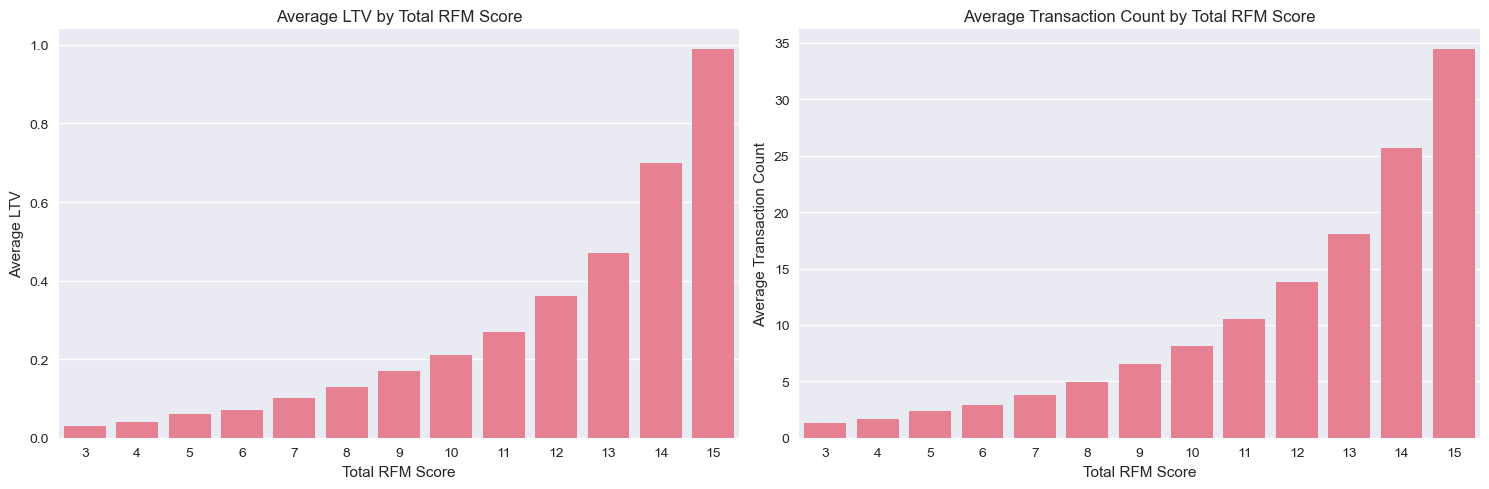

In [ ]:
# STEP 3b: LTV BY RFM SEGMENTS

print("="*80)
print("LTV BY RFM SEGMENTS")
print("="*80)

# Analyze LTV by RFM scores
ltv_by_rfm = customer_ltv.groupby('Total_Score').agg({
    'LTV': ['mean', 'median', 'count'],
    'Total_Revenue': 'mean',
    'Transaction_Count': 'mean'
}).round(2)

ltv_by_rfm.columns = ['Avg_LTV', 'Median_LTV', 'Customer_Count', 'Avg_Revenue', 'Avg_Transactions']
display(ltv_by_rfm.sort_index(ascending=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Average LTV by Total RFM Score
sns.barplot(x=ltv_by_rfm.index, y=ltv_by_rfm['Avg_LTV'], ax=axes[0])
axes[0].set_title('Average LTV by Total RFM Score')
axes[0].set_xlabel('Total RFM Score')
axes[0].set_ylabel('Average LTV')

# Average Transaction Count by Total RFM Score
sns.barplot(x=ltv_by_rfm.index, y=ltv_by_rfm['Avg_Transactions'], ax=axes[1])
axes[1].set_title('Average Transaction Count by Total RFM Score')
axes[1].set_xlabel('Total RFM Score')
axes[1].set_ylabel('Average Transaction Count')

plt.tight_layout()
plt.show()


## STEP 4: RESPONSE MODELING - LOGISTIC REGRESSION


In [ ]:
# STEP 4a: PREPARE DATA FOR RESPONSE MODELING

print("="*80)
print("RESPONSE MODELING - PREPARING DATA")
print("="*80)

# Merge customer data with RFM and LTV
modeling_data = customer_ltv.merge(customers[['customer_id', 'age', 'club_member_status',
                                              'fashion_news_frequency', 'fn', 'active']],
                                  on='customer_id', how='left')

# Create target variable: High-value customer (1 if LTV > median, 0 otherwise)
median_ltv = modeling_data['LTV'].median()
modeling_data['High_Value_Customer'] = (modeling_data['LTV'] > median_ltv).astype(int)

print(f"Median LTV: {median_ltv:.2f}")
print(f"High-value customers: {modeling_data['High_Value_Customer'].sum()} ({modeling_data['High_Value_Customer'].mean()*100:.1f}%)")

# Prepare features for modeling
# Handle missing values
modeling_data['age'] = pd.to_numeric(modeling_data['age'], errors='coerce')
modeling_data['age'] = modeling_data['age'].fillna(modeling_data['age'].median())

# Encode categorical variables
modeling_data['fn'] = modeling_data['fn'].replace('', 0)
modeling_data['fn'] = pd.to_numeric(modeling_data['fn'], errors='coerce').fillna(0)
modeling_data['active'] = modeling_data['active'].replace('', 0)
modeling_data['active'] = pd.to_numeric(modeling_data['active'], errors='coerce').fillna(0)

# Create dummy variables for categorical features
club_member_dummies = pd.get_dummies(modeling_data['club_member_status'], prefix='club', drop_first=True)
fashion_news_dummies = pd.get_dummies(modeling_data['fashion_news_frequency'], prefix='fashion', drop_first=True)

# CRITICAL: Convert dummy variables to int (they're often boolean/uint8)
club_member_dummies = club_member_dummies.astype(int)
fashion_news_dummies = fashion_news_dummies.astype(int)

# Combine features
X_features = pd.concat([
    modeling_data[['R_Score', 'F_Score', 'M_Score', 'Total_Score',
                   'Avg_Transaction_Value', 'Transaction_Count',
                   'Purchase_Frequency', 'age', 'fn', 'active']],
    club_member_dummies,
    fashion_news_dummies
], axis=1)

# Ensure all columns are numeric (convert to float64 to avoid object dtype issues)
for col in X_features.columns:
    X_features[col] = pd.to_numeric(X_features[col], errors='coerce')

# Fill any remaining NaN values with 0
X_features = X_features.fillna(0)

# CRITICAL: Convert entire DataFrame to float64 to ensure no object dtypes remain
# This handles boolean, int, and any other dtypes
X_features = X_features.astype(float)

# Reset index to ensure clean alignment
X_features = X_features.reset_index(drop=True)
modeling_data = modeling_data.reset_index(drop=True)

y_target = modeling_data['High_Value_Customer'].astype(int).reset_index(drop=True)

print(f"\nFeatures for modeling: {X_features.shape[1]} features")
print(f"Sample size: {len(X_features)} customers")
print(f"Data types: {X_features.dtypes.value_counts().to_dict()}")
print(f"✓ All columns are numeric: {X_features.dtypes.isin([np.dtype('float64'), np.dtype('int64')]).all()}")


RESPONSE MODELING - PREPARING DATA
Median LTV: 0.15
High-value customers: 374026 (50.0%)

Features for modeling: 16 features
Sample size: 748053 customers
Data types: {dtype('float64'): 16}
✓ All columns are numeric: True


In [ ]:
# STEP 4b: SPLIT DATA INTO TRAINING AND TESTING SETS

# TIME-BASED SPLIT: Use Last_Purchase date for time-based split
# Training: older customers (earlier last purchase dates)
# Testing: newer customers (more recent last purchase dates)

print("="*80)
print("TIME-BASED TRAIN-TEST SPLIT")
print("="*80)

# Get last purchase dates for each customer (from modeling_data)
if 'Last_Purchase' in modeling_data.columns:
    last_purchase_dates = modeling_data['Last_Purchase'].copy()

    # Align indices with X_features
    last_purchase_dates = last_purchase_dates.loc[X_features.index]

    # Sort by last purchase date
    sorted_indices = last_purchase_dates.sort_values().index

    # Use 70% for training (older customers), 30% for testing (newer customers)
    split_idx = int(len(sorted_indices) * 0.7)
    train_indices = sorted_indices[:split_idx]
    test_indices = sorted_indices[split_idx:]

    # Split the data
    X_train = X_features.loc[train_indices].copy()
    X_test = X_features.loc[test_indices].copy()
    y_train = y_target.loc[train_indices].copy()
    y_test = y_target.loc[test_indices].copy()

    # CRITICAL: Ensure all data is numeric after split
    X_train = X_train.astype(float)
    X_test = X_test.astype(float)
    y_train = y_train.astype(int)
    y_test = y_test.astype(int)

    # Reset indices for clean alignment
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)

    # Get date ranges
    train_date_range = (last_purchase_dates.loc[train_indices].min(),
                        last_purchase_dates.loc[train_indices].max())
    test_date_range = (last_purchase_dates.loc[test_indices].min(),
                       last_purchase_dates.loc[test_indices].max())

    print(f"\nTime-Based Split:")
    print(f"  Training set: {len(X_train)} customers (older customers)")
    print(f"    Date range: {train_date_range[0].date()} to {train_date_range[1].date()}")
    print(f"    High-value customers: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
    print(f"  Testing set: {len(X_test)} customers (newer customers)")
    print(f"    Date range: {test_date_range[0].date()} to {test_date_range[1].date()}")
    print(f"    High-value customers: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
else:
    # Fallback to random split if Last_Purchase not available
    print("⚠ Last_Purchase date not available, using random split")
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y_target, test_size=0.3, random_state=42, stratify=y_target
    )
    print(f"Training set: {len(X_train)} customers")
    print(f"Testing set: {len(X_test)} customers")
    print(f"Training set - High-value customers: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
    print(f"Testing set - High-value customers: {y_test.sum()} ({y_test.mean()*100:.1f}%)")


TIME-BASED TRAIN-TEST SPLIT

Time-Based Split:
  Training set: 523637 customers (older customers)
    Date range: 2020-03-22 to 2020-08-27
    High-value customers: 216552 (41.4%)
  Testing set: 224416 customers (newer customers)
    Date range: 2020-08-27 to 2020-09-22
    High-value customers: 157474 (70.2%)


In [ ]:
# STEP 4b-1: CLEAN DATA FOR MODELING (Fix dtype issues)

# Ensure all columns are numeric and convert problematic columns
print("Cleaning data for modeling...")
for col in X_features.columns:
    if X_features[col].dtype == 'object':
        X_features[col] = pd.to_numeric(X_features[col], errors='coerce')
    X_features[col] = pd.to_numeric(X_features[col], errors='coerce')

# Fill any NaN values
X_features = X_features.fillna(0)

# Ensure target is integer
y_target = y_target.astype(int)

print(f"✓ Data cleaned. Final dtypes: {X_features.dtypes.value_counts().to_dict()}")


Cleaning data for modeling...
✓ Data cleaned. Final dtypes: {dtype('float64'): 16}


LOGIT SCORING AND LIFT/GAIN ANALYSIS BY RFM SEGMENTS

STEP 1: GENERATING LOGIT SCORES FOR ALL CUSTOMERS
✓ Logit scores generated for 748053 customers
  Average logit score: 0.4980
  Score range: 0.0000 to 1.0000

STEP 2: LIFT AND GAIN ANALYSIS BY DECILES (LOGIT SCORES)

📊 LIFT AND GAIN BY DECILE (Based on Logit Scores):


,Decile,Total_Customers,High_Value_Count,Response_Rate,Lift,Cumulative_Pct_Customers,Gain
7,10,74806,0,0.000,0.000,10.000,0.000
6,9,74805,0,0.000,0.000,20.000,0.000
5,8,74811,0,0.000,0.000,30.000,0.000
4,7,74799,0,0.000,0.000,40.000,0.000
3,6,74806,12448,0.170,0.330,50.000,3.330
2,5,74806,62358,0.830,1.670,60.000,20.000
1,4,74932,74932,1.000,2.000,70.020,40.030
0,3,224288,224288,1.000,2.000,100.000,100.000



STEP 3: LIFT AND GAIN ANALYSIS BY RFM SEGMENTS

📊 LIFT AND GAIN BY RFM TOTAL SCORE:


,Total_Score,Total_Customers,High_Value_Count,Response_Rate,Lift,Cumulative_Pct_Customers,Gain
12,15,53631,53631,1.000,2.000,7.170,14.340
11,14,48578,48578,1.000,2.000,13.660,27.330
10,13,54736,54728,1.000,2.000,20.980,41.960
9,12,55764,54733,0.980,1.960,28.440,56.590
8,11,59026,51623,0.870,1.750,36.330,70.390
7,10,61499,43614,0.710,1.420,44.550,82.050
6,9,64471,32722,0.510,1.020,53.170,90.800
5,8,64067,19831,0.310,0.620,61.730,96.110
4,7,70956,11342,0.160,0.320,71.220,99.140
3,6,64556,2991,0.050,0.090,79.850,99.940



STEP 4: LIFT AND GAIN CHARTS


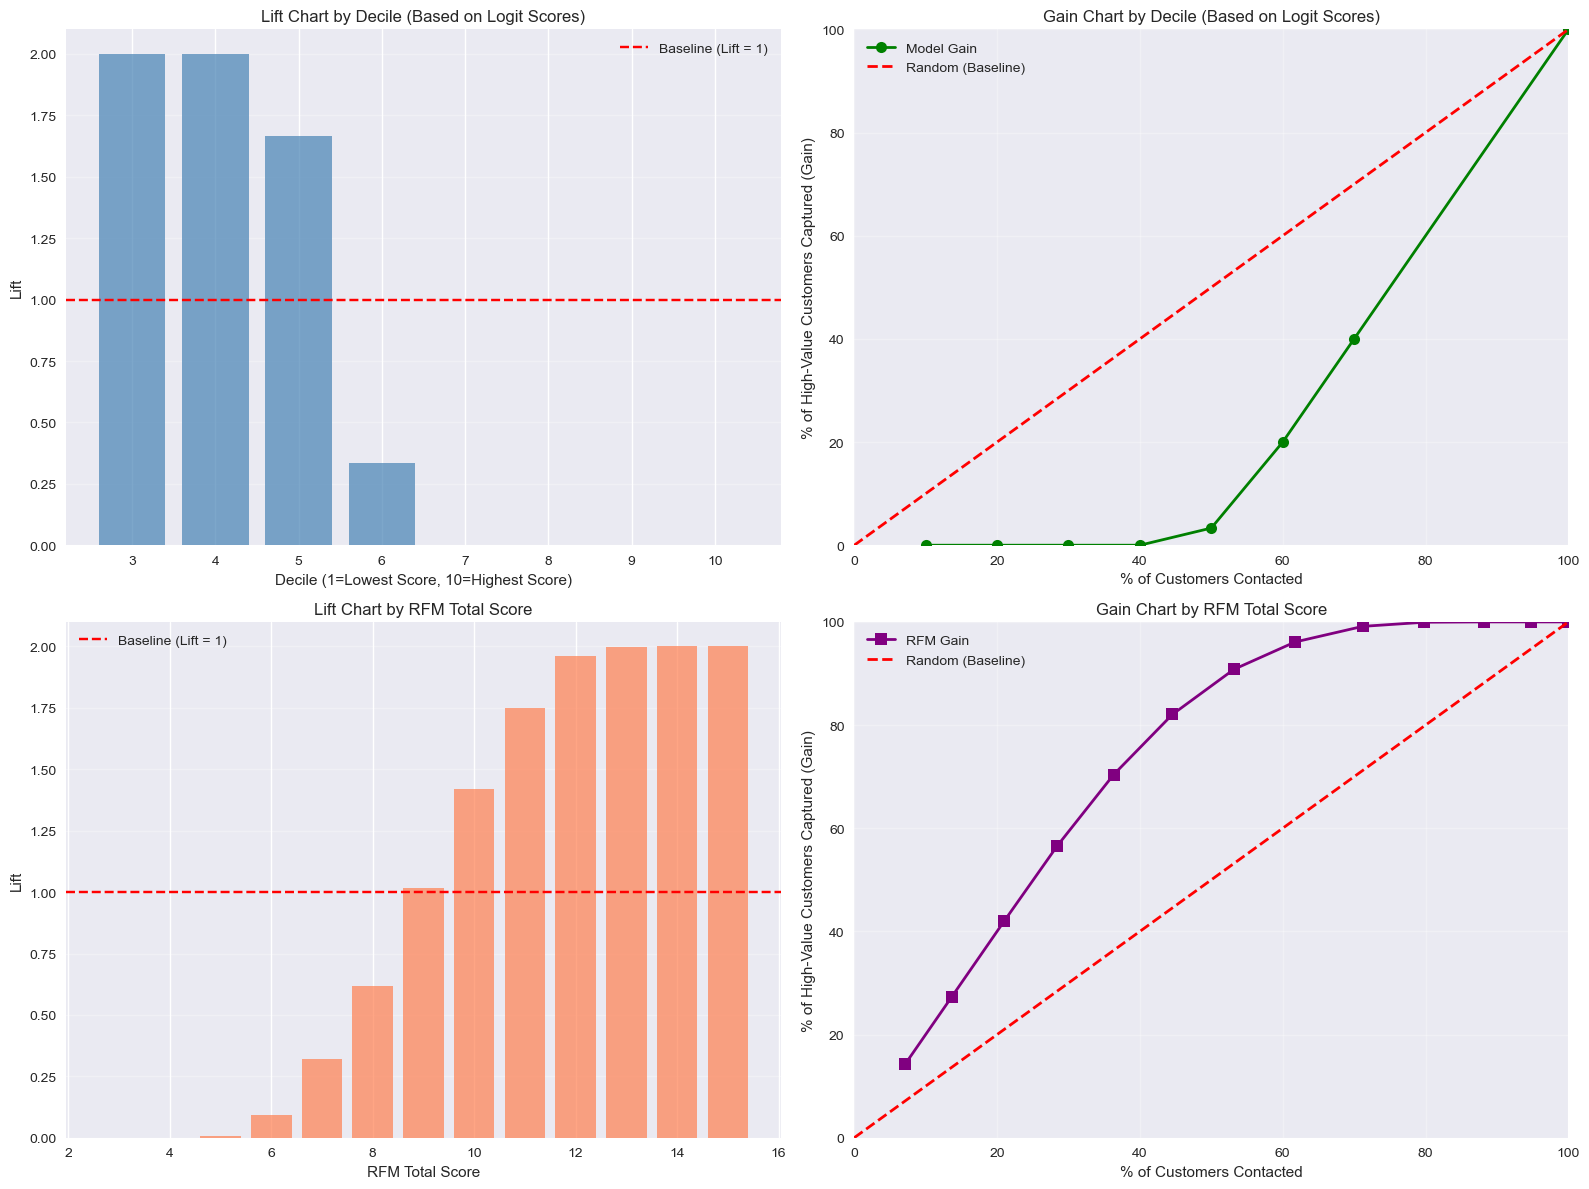


STEP 5: SUMMARY STATISTICS

📈 KEY INSIGHTS:
  Overall Response Rate: 50.00%

  Top Decile (Highest Logit Scores):
    - Response Rate: 0.00%
    - Lift: 0.00x
    - Gain: 0.0% (captures 0.0% of high-value customers with 10.0% of customers)

  Top RFM Segment (Total Score = 15):
    - Response Rate: 100.00%
    - Lift: 2.00x
    - Gain: 14.3% (captures 14.3% of high-value customers with 7.2% of customers)

  Model Efficiency:
    - Top 3 Deciles capture 0.0% of high-value customers
    - Top 5 Deciles capture 3.3% of high-value customers

✓ Lift and Gain analysis completed!


In [ ]:
# STEP 4e: LOGIT SCORING AND LIFT/GAIN ANALYSIS BY RFM

print("="*80)
print("LOGIT SCORING AND LIFT/GAIN ANALYSIS BY RFM SEGMENTS")
print("="*80)

# ============================================================================
# STEP 1: GENERATE LOGIT SCORES FOR ALL CUSTOMERS
# ============================================================================
print("\n" + "="*80)
print("STEP 1: GENERATING LOGIT SCORES FOR ALL CUSTOMERS")
print("="*80)

# Get predictions for all customers (combine train and test)
# Check if DataFrames exist, if not create them from fixed arrays
try:
    # Try to use existing DataFrames
    if 'X_train_df' not in globals():
        X_train_df = pd.DataFrame(X_train_fixed, columns=feature_names)
    if 'X_test_df' not in globals():
        X_test_df = pd.DataFrame(X_test_fixed, columns=feature_names)
    if 'y_train_series' not in globals():
        y_train_series = pd.Series(y_train_fixed, name='High_Value_Customer')

    X_all = pd.concat([X_train_df, X_test_df], axis=0).reset_index(drop=True)
    y_all = pd.concat([y_train_series, pd.Series(y_test_fixed, name='High_Value_Customer')], axis=0).reset_index(drop=True)
except:
    # Fallback: create DataFrames from fixed arrays
    X_train_df = pd.DataFrame(X_train_fixed, columns=feature_names)
    X_test_df = pd.DataFrame(X_test_fixed, columns=feature_names)
    y_train_series = pd.Series(y_train_fixed, name='High_Value_Customer')
    X_all = pd.concat([X_train_df, X_test_df], axis=0).reset_index(drop=True)
    y_all = pd.concat([y_train_series, pd.Series(y_test_fixed, name='High_Value_Customer')], axis=0).reset_index(drop=True)

# Add constant for statsmodels
X_all_const = sm.add_constant(X_all, has_constant='add')

# Generate logit scores (predicted probabilities) for all customers
logit_scores_all = logit_model.predict(X_all_const)

# Create scoring dataframe - need to align with modeling_data
# Get customer_ids in the same order as X_all
# Since X_features was created from modeling_data, we need to get the indices
try:
    # Get customer_ids from modeling_data in the same order as the split
    if 'train_indices' in globals() and 'test_indices' in globals():
        all_indices = list(train_indices) + list(test_indices)
        scoring_data = modeling_data.loc[all_indices, ['customer_id', 'R_Score', 'F_Score', 'M_Score', 'Total_Score']].copy().reset_index(drop=True)
    elif 'X_features' in globals():
        # Use the indices from X_features (which was created from modeling_data)
        scoring_data = modeling_data.loc[X_features.index, ['customer_id', 'R_Score', 'F_Score', 'M_Score', 'Total_Score']].copy().reset_index(drop=True)
    else:
        # Fallback: use all modeling_data
        scoring_data = modeling_data[['customer_id', 'R_Score', 'F_Score', 'M_Score', 'Total_Score']].copy().reset_index(drop=True)
        # Take only the rows that match the length of predictions
        if len(scoring_data) > len(logit_scores_all):
            scoring_data = scoring_data.iloc[:len(logit_scores_all)].copy()
except Exception as e:
    # Final fallback: create from available data
    print(f"⚠ Warning: Using fallback method for scoring_data creation: {e}")
    scoring_data = modeling_data[['customer_id', 'R_Score', 'F_Score', 'M_Score', 'Total_Score']].copy().reset_index(drop=True)
    if len(scoring_data) > len(logit_scores_all):
        scoring_data = scoring_data.iloc[:len(logit_scores_all)].copy()

# Ensure lengths match
min_len = min(len(scoring_data), len(logit_scores_all), len(y_all))
scoring_data = scoring_data.iloc[:min_len].copy()

# Add logit scores and target
scoring_data['Logit_Score'] = logit_scores_all[:min_len]
scoring_data['High_Value_Customer'] = y_all.values[:min_len]

print(f"✓ Logit scores generated for {len(scoring_data)} customers")
print(f"  Average logit score: {scoring_data['Logit_Score'].mean():.4f}")
print(f"  Score range: {scoring_data['Logit_Score'].min():.4f} to {scoring_data['Logit_Score'].max():.4f}")

# ============================================================================
# STEP 2: LIFT AND GAIN BY DECILES (BASED ON LOGIT SCORES)
# ============================================================================
print("\n" + "="*80)
print("STEP 2: LIFT AND GAIN ANALYSIS BY DECILES (LOGIT SCORES)")
print("="*80)

# Create deciles based on logit scores (1 = highest scores, 10 = lowest scores)
scoring_data['Decile'] = pd.qcut(scoring_data['Logit_Score'], q=10, labels=False, duplicates='drop')
scoring_data['Decile'] = 10 - scoring_data['Decile']  # Reverse so 1 = lowest, 10 = highest
scoring_data['Decile'] = scoring_data['Decile'].fillna(5).astype(int)

# Calculate lift and gain by decile
decile_analysis = scoring_data.groupby('Decile').agg({
    'customer_id': 'count',
    'High_Value_Customer': 'sum',
    'Logit_Score': 'mean'
}).reset_index()

decile_analysis.columns = ['Decile', 'Total_Customers', 'High_Value_Count', 'Avg_Logit_Score']

# Calculate response rate
decile_analysis['Response_Rate'] = decile_analysis['High_Value_Count'] / decile_analysis['Total_Customers']

# Overall response rate
overall_response_rate = scoring_data['High_Value_Customer'].mean()

# Calculate lift (response rate in decile / overall response rate)
decile_analysis['Lift'] = decile_analysis['Response_Rate'] / overall_response_rate

# Calculate cumulative metrics for gain
decile_analysis = decile_analysis.sort_values('Decile', ascending=False)
decile_analysis['Cumulative_Customers'] = decile_analysis['Total_Customers'].cumsum()
decile_analysis['Cumulative_High_Value'] = decile_analysis['High_Value_Count'].cumsum()
decile_analysis['Cumulative_Pct_Customers'] = (decile_analysis['Cumulative_Customers'] / len(scoring_data)) * 100
decile_analysis['Cumulative_Pct_High_Value'] = (decile_analysis['Cumulative_High_Value'] / scoring_data['High_Value_Customer'].sum()) * 100

# Gain = Cumulative % of high-value customers captured
decile_analysis['Gain'] = decile_analysis['Cumulative_Pct_High_Value']

print("\n📊 LIFT AND GAIN BY DECILE (Based on Logit Scores):")
display(decile_analysis[['Decile', 'Total_Customers', 'High_Value_Count', 'Response_Rate',
                         'Lift', 'Cumulative_Pct_Customers', 'Gain']].round(2))

# ============================================================================
# STEP 3: LIFT AND GAIN BY RFM SEGMENTS
# ============================================================================
print("\n" + "="*80)
print("STEP 3: LIFT AND GAIN ANALYSIS BY RFM SEGMENTS")
print("="*80)

# Calculate lift and gain by RFM Total_Score
rfm_analysis = scoring_data.groupby('Total_Score').agg({
    'customer_id': 'count',
    'High_Value_Customer': 'sum',
    'Logit_Score': 'mean',
    'R_Score': 'mean',
    'F_Score': 'mean',
    'M_Score': 'mean'
}).reset_index()

rfm_analysis.columns = ['Total_Score', 'Total_Customers', 'High_Value_Count',
                        'Avg_Logit_Score', 'Avg_R_Score', 'Avg_F_Score', 'Avg_M_Score']

# Calculate response rate by RFM
rfm_analysis['Response_Rate'] = rfm_analysis['High_Value_Count'] / rfm_analysis['Total_Customers']

# Calculate lift
rfm_analysis['Lift'] = rfm_analysis['Response_Rate'] / overall_response_rate

# Sort by Total_Score (descending) for cumulative calculations
rfm_analysis = rfm_analysis.sort_values('Total_Score', ascending=False)

# Calculate cumulative metrics for gain
rfm_analysis['Cumulative_Customers'] = rfm_analysis['Total_Customers'].cumsum()
rfm_analysis['Cumulative_High_Value'] = rfm_analysis['High_Value_Count'].cumsum()
rfm_analysis['Cumulative_Pct_Customers'] = (rfm_analysis['Cumulative_Customers'] / len(scoring_data)) * 100
rfm_analysis['Cumulative_Pct_High_Value'] = (rfm_analysis['Cumulative_High_Value'] / scoring_data['High_Value_Customer'].sum()) * 100

# Gain = Cumulative % of high-value customers captured
rfm_analysis['Gain'] = rfm_analysis['Cumulative_Pct_High_Value']

print("\n📊 LIFT AND GAIN BY RFM TOTAL SCORE:")
display(rfm_analysis[['Total_Score', 'Total_Customers', 'High_Value_Count', 'Response_Rate',
                       'Lift', 'Cumulative_Pct_Customers', 'Gain']].round(2))

# ============================================================================
# STEP 4: VISUALIZATIONS - LIFT AND GAIN CHARTS
# ============================================================================
print("\n" + "="*80)
print("STEP 4: LIFT AND GAIN CHARTS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Lift Chart by Decile (Logit Scores)
axes[0, 0].bar(decile_analysis['Decile'], decile_analysis['Lift'], color='steelblue', alpha=0.7)
axes[0, 0].axhline(y=1, color='red', linestyle='--', label='Baseline (Lift = 1)')
axes[0, 0].set_xlabel('Decile (1=Lowest Score, 10=Highest Score)')
axes[0, 0].set_ylabel('Lift')
axes[0, 0].set_title('Lift Chart by Decile (Based on Logit Scores)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Gain Chart by Decile (Logit Scores)
axes[0, 1].plot(decile_analysis['Cumulative_Pct_Customers'], decile_analysis['Gain'],
                marker='o', linewidth=2, markersize=8, label='Model Gain', color='green')
axes[0, 1].plot([0, 100], [0, 100], 'r--', label='Random (Baseline)', linewidth=2)
axes[0, 1].set_xlabel('% of Customers Contacted')
axes[0, 1].set_ylabel('% of High-Value Customers Captured (Gain)')
axes[0, 1].set_title('Gain Chart by Decile (Based on Logit Scores)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim([0, 100])
axes[0, 1].set_ylim([0, 100])

# 3. Lift Chart by RFM Total Score
axes[1, 0].bar(rfm_analysis['Total_Score'], rfm_analysis['Lift'], color='coral', alpha=0.7)
axes[1, 0].axhline(y=1, color='red', linestyle='--', label='Baseline (Lift = 1)')
axes[1, 0].set_xlabel('RFM Total Score')
axes[1, 0].set_ylabel('Lift')
axes[1, 0].set_title('Lift Chart by RFM Total Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Gain Chart by RFM Total Score
axes[1, 1].plot(rfm_analysis['Cumulative_Pct_Customers'], rfm_analysis['Gain'],
                marker='s', linewidth=2, markersize=8, label='RFM Gain', color='purple')
axes[1, 1].plot([0, 100], [0, 100], 'r--', label='Random (Baseline)', linewidth=2)
axes[1, 1].set_xlabel('% of Customers Contacted')
axes[1, 1].set_ylabel('% of High-Value Customers Captured (Gain)')
axes[1, 1].set_title('Gain Chart by RFM Total Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([0, 100])
axes[1, 1].set_ylim([0, 100])

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 5: SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("STEP 5: SUMMARY STATISTICS")
print("="*80)

print(f"\n📈 KEY INSIGHTS:")
print(f"  Overall Response Rate: {overall_response_rate:.2%}")

# Top decile performance
top_decile = decile_analysis[decile_analysis['Decile'] == 10]
print(f"\n  Top Decile (Highest Logit Scores):")
print(f"    - Response Rate: {top_decile['Response_Rate'].values[0]:.2%}")
print(f"    - Lift: {top_decile['Lift'].values[0]:.2f}x")
print(f"    - Gain: {top_decile['Gain'].values[0]:.1f}% (captures {top_decile['Gain'].values[0]:.1f}% of high-value customers with {top_decile['Cumulative_Pct_Customers'].values[0]:.1f}% of customers)")

# Top RFM segment performance
top_rfm = rfm_analysis.iloc[0]  # Highest Total_Score
print(f"\n  Top RFM Segment (Total Score = {top_rfm['Total_Score']:.0f}):")
print(f"    - Response Rate: {top_rfm['Response_Rate']:.2%}")
print(f"    - Lift: {top_rfm['Lift']:.2f}x")
print(f"    - Gain: {top_rfm['Gain']:.1f}% (captures {top_rfm['Gain']:.1f}% of high-value customers with {top_rfm['Cumulative_Pct_Customers']:.1f}% of customers)")

# Calculate efficiency metrics
print(f"\n  Model Efficiency:")
print(f"    - Top 3 Deciles capture {decile_analysis[decile_analysis['Decile'] >= 8]['Gain'].max():.1f}% of high-value customers")
print(f"    - Top 5 Deciles capture {decile_analysis[decile_analysis['Decile'] >= 6]['Gain'].max():.1f}% of high-value customers")

print("\n✓ Lift and Gain analysis completed!")


In [ ]:
# STEP 4c-0: FIX DATA TYPES FOR STATSMODELS (Critical Fix)

# Convert pandas DataFrames to numpy arrays with proper dtypes
# This fixes the "Pandas data cast to numpy dtype of object" error

print("="*80)
print("FIXING DATA TYPES FOR STATSMODELS")
print("="*80)

# First ensure all columns are float64 (explicit conversion)
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Check for any remaining object dtypes
train_obj_cols = X_train.select_dtypes(include=['object']).columns
test_obj_cols = X_test.select_dtypes(include=['object']).columns
if len(train_obj_cols) > 0 or len(test_obj_cols) > 0:
    print(f"⚠ Warning: Found object columns in X_train: {list(train_obj_cols)}")
    print(f"⚠ Warning: Found object columns in X_test: {list(test_obj_cols)}")
    for col in train_obj_cols:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce').fillna(0).astype(float)
    for col in test_obj_cols:
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce').fillna(0).astype(float)

# Use .to_numpy() instead of .values for more reliable conversion
# This ensures proper dtype conversion
X_train_fixed = X_train.to_numpy(dtype=np.float64)
X_test_fixed = X_test.to_numpy(dtype=np.float64)
y_train_fixed = y_train.to_numpy(dtype=np.int64)
y_test_fixed = y_test.to_numpy(dtype=np.int64)

# Final verification - ensure arrays are contiguous and correct dtype
if X_train_fixed.dtype != np.float64:
    print(f"⚠ Converting X_train_fixed from {X_train_fixed.dtype} to float64")
    X_train_fixed = X_train_fixed.astype(np.float64)
if X_test_fixed.dtype != np.float64:
    print(f"⚠ Converting X_test_fixed from {X_test_fixed.dtype} to float64")
    X_test_fixed = X_test_fixed.astype(np.float64)
if y_train_fixed.dtype != np.int64:
    print(f"⚠ Converting y_train_fixed from {y_train_fixed.dtype} to int64")
    y_train_fixed = y_train_fixed.astype(np.int64)
if y_test_fixed.dtype != np.int64:
    print(f"⚠ Converting y_test_fixed from {y_test_fixed.dtype} to int64")
    y_test_fixed = y_test_fixed.astype(np.int64)

# Ensure arrays are C-contiguous (required by some statsmodels operations)
X_train_fixed = np.ascontiguousarray(X_train_fixed, dtype=np.float64)
X_test_fixed = np.ascontiguousarray(X_test_fixed, dtype=np.float64)
y_train_fixed = np.ascontiguousarray(y_train_fixed, dtype=np.int64)
y_test_fixed = np.ascontiguousarray(y_test_fixed, dtype=np.int64)

# Store feature names before converting to numpy (for model interpretation)
feature_names = list(X_train.columns)

print(f"\n✓ Data converted to numpy arrays")
print(f"  X_train: shape={X_train_fixed.shape}, dtype={X_train_fixed.dtype}, contiguous={X_train_fixed.flags['C_CONTIGUOUS']}")
print(f"  X_test: shape={X_test_fixed.shape}, dtype={X_test_fixed.dtype}, contiguous={X_test_fixed.flags['C_CONTIGUOUS']}")
print(f"  y_train: shape={y_train_fixed.shape}, dtype={y_train_fixed.dtype}")
print(f"  y_test: shape={y_test_fixed.shape}, dtype={y_test_fixed.dtype}")
print(f"  Feature names preserved: {len(feature_names)} features")
print(f"\n✓ All data types verified - ready for statsmodels")


FIXING DATA TYPES FOR STATSMODELS

✓ Data converted to numpy arrays
  X_train: shape=(523637, 16), dtype=float64, contiguous=True
  X_test: shape=(224416, 16), dtype=float64, contiguous=True
  y_train: shape=(523637,), dtype=int64
  y_test: shape=(224416,), dtype=int64
  Feature names preserved: 16 features

✓ All data types verified - ready for statsmodels


In [ ]:
# STEP 4c: TRAIN LOGISTIC REGRESSION MODEL

print("="*80)
print("LOGISTIC REGRESSION MODEL")
print("="*80)

# Create DataFrames with feature names for statsmodels (preserves column names)
# This allows statsmodels to display actual feature names instead of x1, x2, etc.
X_train_df = pd.DataFrame(X_train_fixed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_fixed, columns=feature_names)
y_train_series = pd.Series(y_train_fixed, name='High_Value_Customer')

# Add constant for intercept (using DataFrames preserves names)
X_train_const = sm.add_constant(X_train_df, has_constant='add')
X_test_const = sm.add_constant(X_test_df, has_constant='add')

# Estimate Logistic Regression model
# Using pandas Series/DataFrame allows statsmodels to use column names automatically
logit_model = sm.Logit(y_train_series, X_train_const).fit()

# Display model results (will show actual feature names)
print(logit_model.summary())


LOGISTIC REGRESSION MODEL
         Current function value: 0.097432
         Iterations: 35
                            Logit Regression Results                           
Dep. Variable:     High_Value_Customer   No. Observations:               523637
Model:                           Logit   Df Residuals:                   523620
Method:                            MLE   Df Model:                           16
Date:                 Sun, 07 Dec 2025   Pseudo R-squ.:                  0.8563
Time:                         17:04:14   Log-Likelihood:                -51019.
converged:                       False   LL-Null:                   -3.5509e+05
Covariance Type:             nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -93.4635    180.613     -0.517      0.605    -447.459     260.53

LOGISTIC REGRESSION - MODEL EVALUATION


Accuracy: 0.9646

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94     66942
           1       0.98      0.97      0.97    157474

    accuracy                           0.96    224416
   macro avg       0.95      0.96      0.96    224416
weighted avg       0.97      0.96      0.96    224416


Confusion Matrix:
[[ 64058   2884]
 [  5067 152407]]


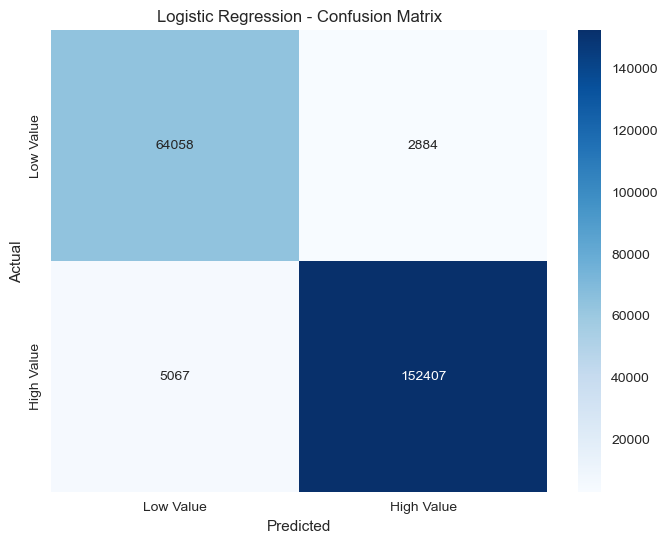

In [ ]:
# STEP 4d: TEST LOGISTIC REGRESSION MODEL

print("="*80)
print("LOGISTIC REGRESSION - MODEL EVALUATION")
print("="*80)

# Generate predictions
logit_pred_probs = logit_model.predict(X_test_const)
logit_pred_class = (logit_pred_probs >= 0.5).astype(int)

# Evaluate model (using fixed y_test)
print(f"Accuracy: {accuracy_score(y_test_fixed, logit_pred_class):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_fixed, logit_pred_class))

# Confusion Matrix
cm = confusion_matrix(y_test_fixed, logit_pred_class)
print(f"\nConfusion Matrix:")
print(cm)

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Value', 'High Value'],
            yticklabels=['Low Value', 'High Value'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## STEP 5: RESPONSE MODELING - DECISION TREE


In [ ]:
# STEP 5a: TRAIN DECISION TREE MODEL

print("="*80)
print("DECISION TREE MODEL")
print("="*80)

# Train Decision Tree
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

print("Decision Tree Model Trained")
print(f"Max depth: {tree_model.max_depth}")
print(f"Number of features: {tree_model.n_features_in_}")


DECISION TREE MODEL
Decision Tree Model Trained
Max depth: 5
Number of features: 16


DECISION TREE - MODEL EVALUATION


Accuracy: 0.9628

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     66942
           1       0.99      0.96      0.97    157474

    accuracy                           0.96    224416
   macro avg       0.95      0.96      0.96    224416
weighted avg       0.96      0.96      0.96    224416


Confusion Matrix:
[[ 64871   2071]
 [  6279 151195]]


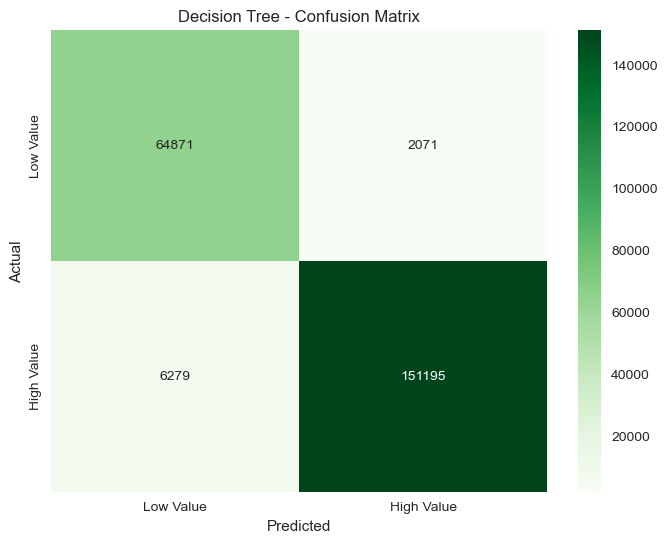


Top 10 Most Important Features:


,Feature,Importance
2,M_Score,0.881
5,Transaction_Count,0.076
4,Avg_Transaction_Value,0.043
0,R_Score,0.000
3,Total_Score,0.000
1,F_Score,0.000
6,Purchase_Frequency,0.000
7,age,0.000
8,fn,0.000
9,active,0.000


In [ ]:
# STEP 5b: TEST DECISION TREE MODEL

print("="*80)
print("DECISION TREE - MODEL EVALUATION")
print("="*80)

# Generate predictions
tree_pred_probs = tree_model.predict_proba(X_test)[:, 1]
tree_pred_class = tree_model.predict(X_test)

# Evaluate model
print(f"Accuracy: {accuracy_score(y_test, tree_pred_class):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, tree_pred_class))

# Confusion Matrix
cm_tree = confusion_matrix(y_test, tree_pred_class)
print(f"\nConfusion Matrix:")
print(cm_tree)

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low Value', 'High Value'],
            yticklabels=['Low Value', 'High Value'])
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Most Important Features:")
display(feature_importance.head(10))


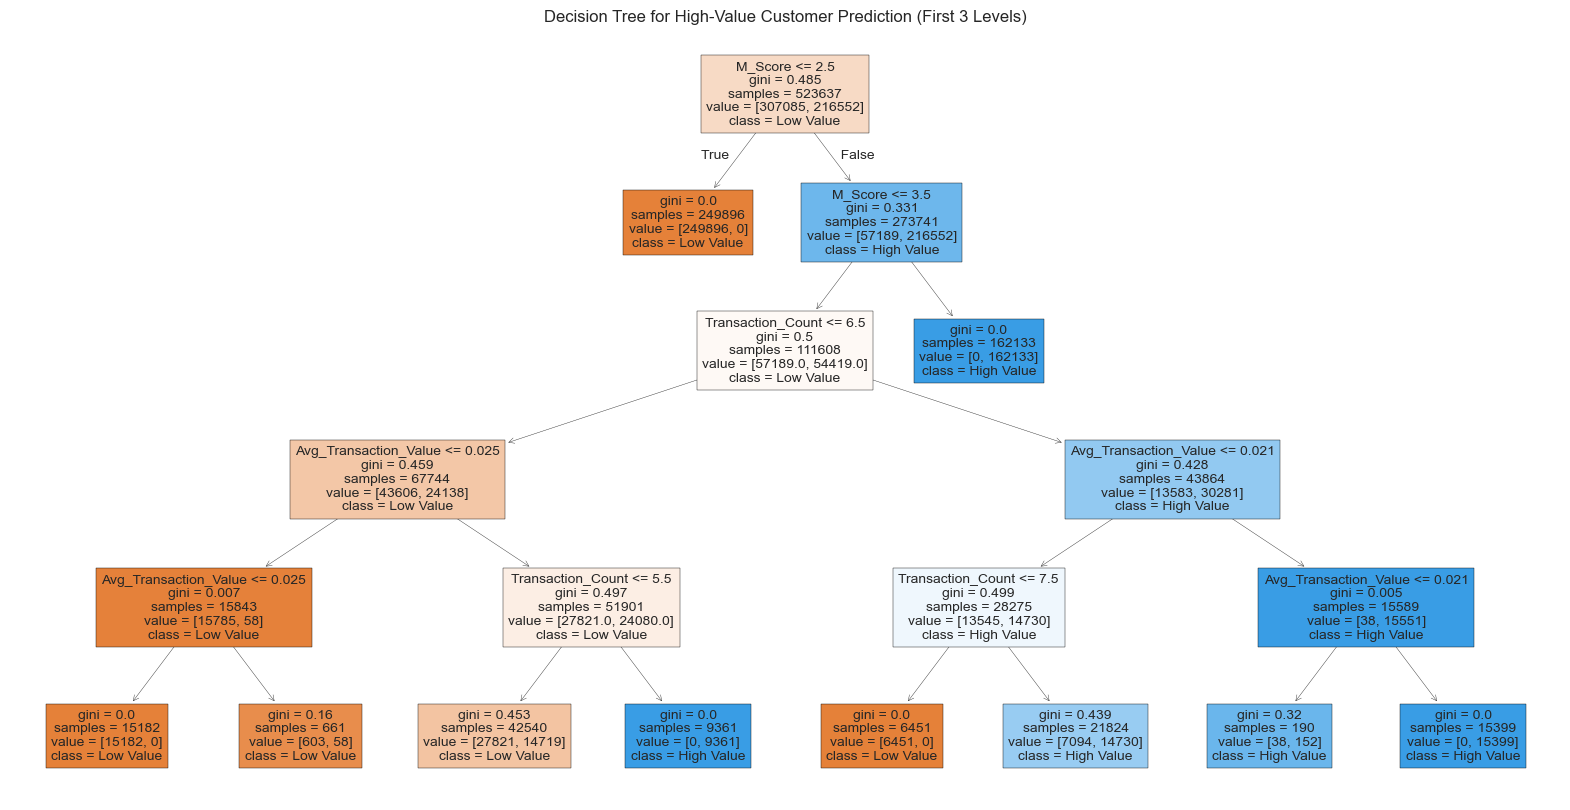

In [ ]:
# STEP 5c: VISUALIZE DECISION TREE (Simplified)

plt.figure(figsize=(20, 10))
plot_tree(tree_model, filled=True, feature_names=X_train.columns,
          class_names=['Low Value', 'High Value'], max_depth=5, fontsize=10)
plt.title("Decision Tree for High-Value Customer Prediction (First 3 Levels)")
plt.show()


## STEP 6: FACTOR ANALYSIS (PCA)


In [ ]:
# STEP 6a: PREPARE DATA FOR FACTOR ANALYSIS

print("="*80)
print("FACTOR ANALYSIS (PCA) - PREPARING DATA")
print("="*80)

# Select numeric features for factor analysis
pca_features = modeling_data[['R_Score', 'F_Score', 'M_Score', 'Total_Score',
                               'Total_Revenue', 'Avg_Transaction_Value',
                               'Transaction_Count', 'Purchase_Frequency',
                               'Customer_Lifetime_Days', 'age']].copy()

# Remove any remaining missing values
pca_features = pca_features.dropna()

# Standardize features
scaler_pca = StandardScaler()
pca_features_scaled = scaler_pca.fit_transform(pca_features)

print(f"Features for PCA: {pca_features.shape[1]}")
print(f"Sample size: {pca_features.shape[0]} customers")


FACTOR ANALYSIS (PCA) - PREPARING DATA
Features for PCA: 10
Sample size: 748053 customers


In [ ]:
# STEP 6b: RUN PCA

print("="*80)
print("FACTOR ANALYSIS (PCA) - RUNNING ANALYSIS")
print("="*80)

# Run PCA
pca = PCA()
pca_components = pca.fit_transform(pca_features_scaled)

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Display results
pca_results = pd.DataFrame({
    'Component': range(1, len(explained_variance) + 1),
    'Eigenvalue': pca.explained_variance_,
    'Variance_Explained': explained_variance,
    'Cumulative_Variance': cumulative_variance
})

display(pca_results)

# Determine number of components to retain (typically keep components with eigenvalue > 1)
n_components = sum(pca.explained_variance_ > 1)
print(f"\nComponents with eigenvalue > 1: {n_components}")
print(f"Variance explained by first {n_components} components: {cumulative_variance[n_components-1]:.2%}")


FACTOR ANALYSIS (PCA) - RUNNING ANALYSIS


,Component,Eigenvalue,Variance_Explained,Cumulative_Variance
0,1,4.932,0.493,0.493
1,2,1.176,0.118,0.611
2,3,1.163,0.116,0.727
3,4,0.905,0.090,0.818
4,5,0.828,0.083,0.900
5,6,0.615,0.061,0.962
6,7,0.287,0.029,0.991
7,8,0.053,0.005,0.996
8,9,0.040,0.004,1.000
9,10,0.000,0.000,1.000



Components with eigenvalue > 1: 3
Variance explained by first 3 components: 72.71%


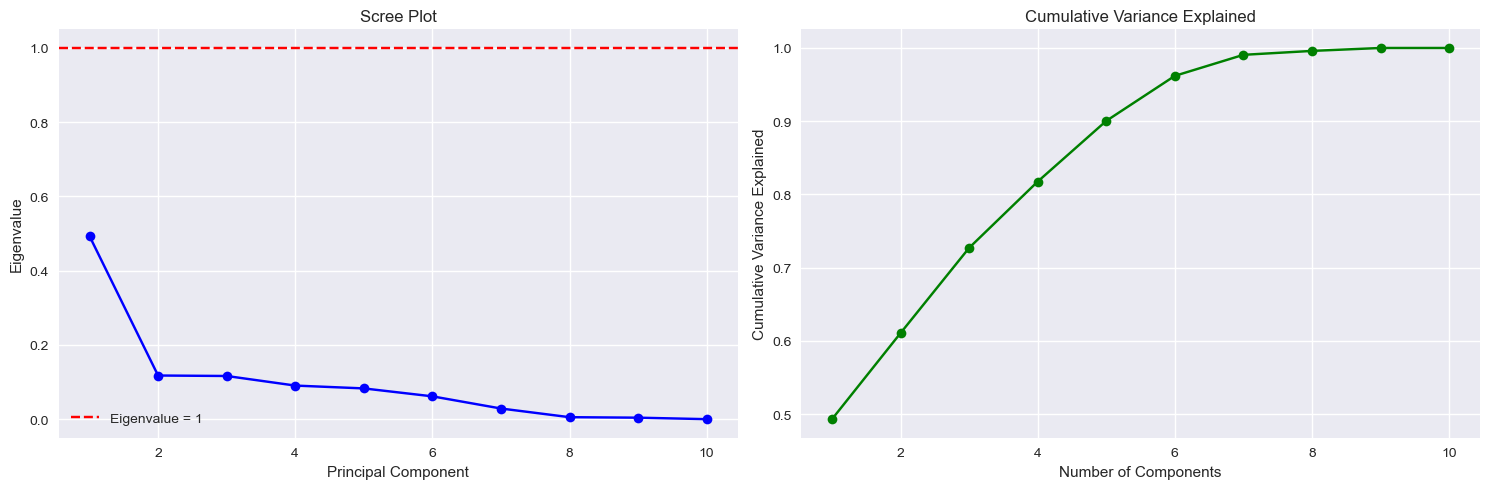


Component Loadings (First 3 Components):


,PC1,PC2,PC3
R_Score,0.270,-0.441,0.140
F_Score,0.405,0.068,-0.165
M_Score,0.405,0.141,0.061
Total_Score,0.431,-0.092,0.015
Total_Revenue,0.366,0.226,0.046
Avg_Transaction_Value,0.019,0.246,0.721
Transaction_Count,0.378,0.179,-0.092
Purchase_Frequency,0.045,0.700,-0.306
Customer_Lifetime_Days,0.367,-0.307,0.043
age,-0.001,0.213,0.568


In [ ]:
# STEP 6c: PCA VISUALIZATIONS

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree Plot
axes[0].plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-')
axes[0].axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1')
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Eigenvalue')
axes[0].legend()
axes[0].grid(True)

# Cumulative Variance Explained
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'go-')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Component Loadings (first 3 components)
n_show = min(3, n_components)
component_loadings = pd.DataFrame(
    pca.components_[:n_show].T,
    columns=[f'PC{i+1}' for i in range(n_show)],
    index=pca_features.columns
)

print(f"\nComponent Loadings (First {n_show} Components):")
display(component_loadings.round(3))


## STEP 7: CLUSTER ANALYSIS (K-MEANS)


In [ ]:
# STEP 7a: PREPARE DATA FOR CLUSTERING

print("="*80)
print("K-MEANS CLUSTERING - PREPARING DATA")
print("="*80)

# Use RFM metrics and key customer features for clustering
clustering_features = ['R_Score', 'F_Score', 'M_Score', 'Total_Score',
                      'Total_Revenue', 'Avg_Transaction_Value',
                      'Transaction_Count', 'Purchase_Frequency']

clustering_data = modeling_data[clustering_features + ['customer_id']].copy()
clustering_data = clustering_data.dropna()

# Standardize features
scaler_cluster = StandardScaler()
X_cluster = clustering_data[clustering_features]
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Features for clustering: {len(clustering_features)}")
print(f"Sample size: {len(clustering_data)} customers")


K-MEANS CLUSTERING - PREPARING DATA


Features for clustering: 8
Sample size: 748053 customers


K-MEANS CLUSTERING - FINDING OPTIMAL K


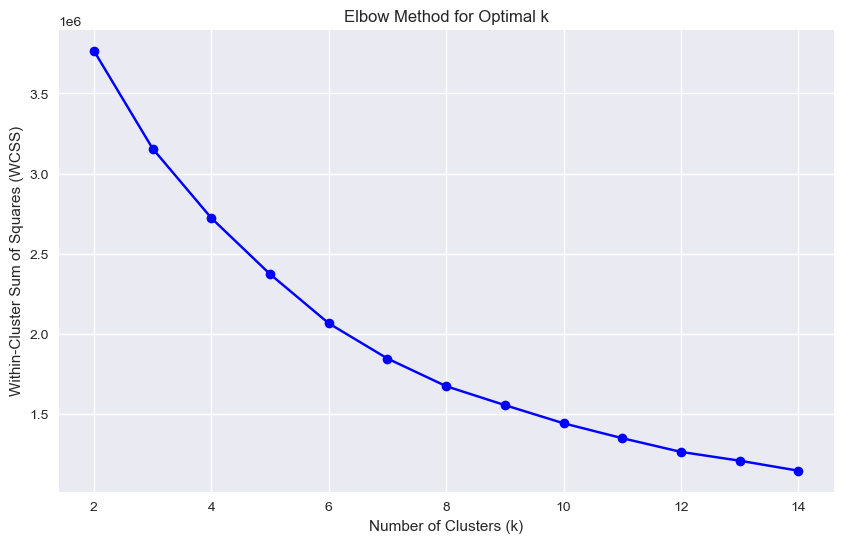

WCSS values:
k=2: WCSS=3766356.98
k=3: WCSS=3156263.15
k=4: WCSS=2722884.22
k=5: WCSS=2373034.41
k=6: WCSS=2066064.74
k=7: WCSS=1846328.15
k=8: WCSS=1673915.42
k=9: WCSS=1555837.10
k=10: WCSS=1442458.60
k=11: WCSS=1349481.46
k=12: WCSS=1264049.24
k=13: WCSS=1209101.18
k=14: WCSS=1146640.52


In [ ]:
# STEP 7b: FIND OPTIMAL NUMBER OF CLUSTERS (Elbow Method)

print("="*80)
print("K-MEANS CLUSTERING - FINDING OPTIMAL K")
print("="*80)

# Calculate WCSS for different values of k
wcss = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

print("WCSS values:")
for k, w in zip(k_range, wcss):
    print(f"k={k}: WCSS={w:.2f}")


In [ ]:
# STEP 7c: RUN K-MEANS CLUSTERING

print("="*80)
print("K-MEANS CLUSTERING - RUNNING MODEL")
print("="*80)

# Choose number of clusters (based on elbow method, typically 4-6)
n_clusters = 5

# Run K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Add cluster labels to data
clustering_data['Cluster'] = clusters

# Display cluster distribution
print(f"\nCluster Distribution (k={n_clusters}):")
cluster_counts = clustering_data['Cluster'].value_counts().sort_index()
cluster_pct = (clustering_data['Cluster'].value_counts(normalize=True) * 100).round(2)
cluster_summary = pd.DataFrame({
    'Count': cluster_counts,
    'Percentage': cluster_pct
})
display(cluster_summary)


K-MEANS CLUSTERING - RUNNING MODEL

Cluster Distribution (k=5):


,Count,Percentage
Cluster,,
0,179881,24.050
1,265619,35.510
2,5763,0.770
3,22700,3.030
4,274090,36.640


In [ ]:
# STEP 7d: ANALYZE CLUSTERS

print("="*80)
print("K-MEANS CLUSTERING - CLUSTER ANALYSIS")
print("="*80)

# Calculate average metrics by cluster
cluster_metrics = clustering_data.groupby('Cluster').agg({
    'R_Score': 'mean',
    'F_Score': 'mean',
    'M_Score': 'mean',
    'Total_Score': 'mean',
    'Total_Revenue': 'mean',
    'Avg_Transaction_Value': 'mean',
    'Transaction_Count': 'mean',
    'Purchase_Frequency': 'mean'
}).round(2)

print("\nAverage Metrics by Cluster:")
display(cluster_metrics)

# Cluster centers (in original scale)
cluster_centers_original = scaler_cluster.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers_original, columns=clustering_features)
centers_df.index = [f'Cluster {i}' for i in range(n_clusters)]

print("\nCluster Centers (in original feature scale):")
display(centers_df)


K-MEANS CLUSTERING - CLUSTER ANALYSIS

Average Metrics by Cluster:


,R_Score,F_Score,M_Score,Total_Score,Total_Revenue,Avg_Transaction_Value,Transaction_Count,Purchase_Frequency
Cluster,,,,,,,,
0,4.010,4.680,4.670,13.370,0.520,0.030,19.450,7.730
1,3.050,3.190,3.200,9.440,0.180,0.030,7.110,8.490
2,2.280,3.970,3.830,10.080,0.320,0.030,12.520,241.140
3,4.460,5.000,5.000,14.460,1.740,0.030,59.260,13.400
4,2.180,1.520,1.520,5.230,0.060,0.030,2.350,3.580



Cluster Centers (in original feature scale):


,R_Score,F_Score,M_Score,Total_Score,Total_Revenue,Avg_Transaction_Value,Transaction_Count,Purchase_Frequency
Cluster 0,4.014,4.682,4.673,13.369,0.519,0.028,19.431,7.730
Cluster 1,3.049,3.192,3.201,9.442,0.182,0.027,7.111,8.492
Cluster 2,2.284,3.966,3.832,10.082,0.323,0.026,12.523,241.141
Cluster 3,4.464,5.000,5.000,14.464,1.741,0.030,59.206,13.388
Cluster 4,2.180,1.522,1.523,5.225,0.058,0.027,2.353,3.583


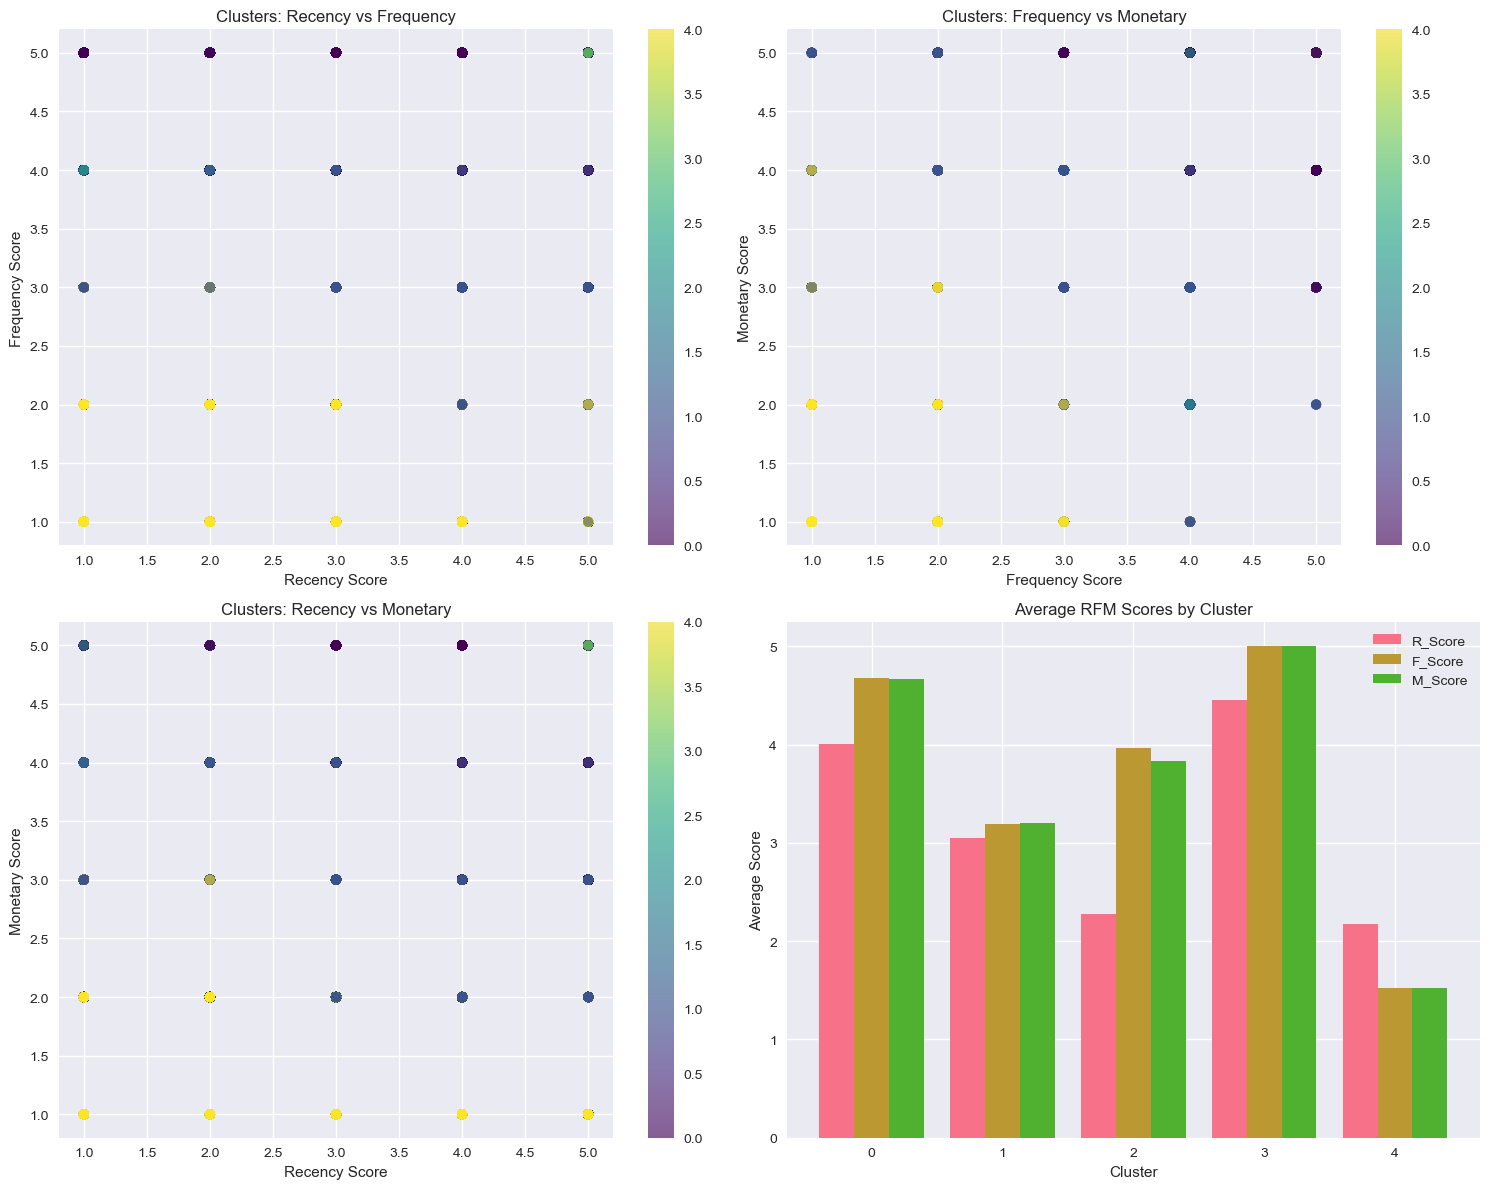

In [ ]:
# STEP 7e: CLUSTER VISUALIZATIONS

# Visualize clusters using RFM dimensions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Recency vs Frequency
scatter1 = axes[0, 0].scatter(clustering_data['R_Score'], clustering_data['F_Score'],
                              c=clustering_data['Cluster'], cmap='viridis', alpha=0.6)
axes[0, 0].set_xlabel('Recency Score')
axes[0, 0].set_ylabel('Frequency Score')
axes[0, 0].set_title('Clusters: Recency vs Frequency')
plt.colorbar(scatter1, ax=axes[0, 0])

# Frequency vs Monetary
scatter2 = axes[0, 1].scatter(clustering_data['F_Score'], clustering_data['M_Score'],
                              c=clustering_data['Cluster'], cmap='viridis', alpha=0.6)
axes[0, 1].set_xlabel('Frequency Score')
axes[0, 1].set_ylabel('Monetary Score')
axes[0, 1].set_title('Clusters: Frequency vs Monetary')
plt.colorbar(scatter2, ax=axes[0, 1])

# Recency vs Monetary
scatter3 = axes[1, 0].scatter(clustering_data['R_Score'], clustering_data['M_Score'],
                              c=clustering_data['Cluster'], cmap='viridis', alpha=0.6)
axes[1, 0].set_xlabel('Recency Score')
axes[1, 0].set_ylabel('Monetary Score')
axes[1, 0].set_title('Clusters: Recency vs Monetary')
plt.colorbar(scatter3, ax=axes[1, 0])

# Average metrics by cluster (bar chart)
cluster_metrics_plot = cluster_metrics[['R_Score', 'F_Score', 'M_Score']]
cluster_metrics_plot.plot(kind='bar', ax=axes[1, 1], width=0.8)
axes[1, 1].set_title('Average RFM Scores by Cluster')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Average Score')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## STEP 8: CHURN PREDICTION

**Note**: This section uses the **complete 2-year transaction data** (not just the 6-month subset) for more comprehensive churn analysis.


In [ ]:
# STEP 8a: DEFINE CHURN AND PREPARE DATA

print("="*80)
print("CHURN PREDICTION - PREPARING DATA (USING FULL 2-YEAR DATA)")
print("="*80)

# Using FULL 2-year transaction data for churn analysis
# Define churn: Customers who haven't purchased in the last observation period
# We'll use the last 60 days as the "observation period" and define churn as no purchase in that period
# Training period: Most of the 2-year data (excluding observation period)

observation_end = transactions['t_dat'].max()
observation_start = observation_end - pd.Timedelta(days=60)  # 2 months observation period
training_end = observation_start - pd.Timedelta(days=1)
training_start = transactions['t_dat'].min()  # Use all available data from start

print(f"Full data range: {transactions['t_dat'].min().date()} to {transactions['t_dat'].max().date()}")
print(f"Training period: {training_start.date()} to {training_end.date()} ({len(transactions[(transactions['t_dat'] >= training_start) & (transactions['t_dat'] <= training_end)])} transactions)")
print(f"Observation period: {observation_start.date()} to {observation_end.date()} ({len(transactions[(transactions['t_dat'] >= observation_start) & (transactions['t_dat'] <= observation_end)])} transactions)")

# Split transactions into training and observation periods (using FULL data)
transactions_training = transactions[
    (transactions['t_dat'] >= training_start) &
    (transactions['t_dat'] <= training_end)
].copy()

transactions_observation = transactions[
    (transactions['t_dat'] >= observation_start) &
    (transactions['t_dat'] <= observation_end)
].copy()

# Identify customers who purchased in training period
customers_training = transactions_training['customer_id'].unique()
customers_observed = transactions_observation['customer_id'].unique()

# Define churn: Customer was active in training period but not in observation period
churn_data = pd.DataFrame({'customer_id': customers_training})
churn_data['Churned'] = (~churn_data['customer_id'].isin(customers_observed)).astype(int)

print(f"\nCustomers in training period: {len(customers_training):,}")
print(f"Customers in observation period: {len(customers_observed):,}")
print(f"Churned customers: {churn_data['Churned'].sum():,} ({churn_data['Churned'].mean()*100:.1f}%)")


CHURN PREDICTION - PREPARING DATA (USING FULL 2-YEAR DATA)
Full data range: 2018-09-20 to 2020-09-22
Training period: 2018-09-20 to 2020-07-23 (26635635 transactions)
Observation period: 2020-07-24 to 2020-09-22 (2177784 transactions)

Customers in training period: 1,315,676
Customers in observation period: 400,458
Churned customers: 961,823 (73.1%)


In [ ]:
# STEP 8b: CREATE FEATURES FOR CHURN PREDICTION

print("="*80)
print("CHURN PREDICTION - CREATING FEATURES (FROM FULL 2-YEAR DATA)")
print("="*80)

# Calculate customer features from training period (using full 2-year data)
customer_features = transactions_training.groupby('customer_id').agg({
    't_dat': ['min', 'max', 'count'],
    'price': ['sum', 'mean', 'std']
}).reset_index()

customer_features.columns = ['customer_id', 'First_Purchase', 'Last_Purchase',
                             'Transaction_Count', 'Total_Revenue', 'Avg_Price', 'Std_Price']

# Calculate additional features
customer_features['Customer_Lifetime_Days'] = (
    customer_features['Last_Purchase'] - customer_features['First_Purchase']
).dt.days
customer_features['Customer_Lifetime_Days'] = customer_features['Customer_Lifetime_Days'].fillna(0)

# Days since last purchase (at end of training period)
customer_features['Days_Since_Last_Purchase'] = (
    training_end - customer_features['Last_Purchase']
).dt.days

# Purchase frequency (transactions per month)
customer_features['Months_Active'] = customer_features['Customer_Lifetime_Days'] / 30.0
customer_features['Months_Active'] = customer_features['Months_Active'].replace(0, 1)
customer_features['Purchase_Frequency'] = customer_features['Transaction_Count'] / customer_features['Months_Active']

# Fill missing values
customer_features['Std_Price'] = customer_features['Std_Price'].fillna(0)

# ============================================================================
# IMPORTANT: RFM scores (R_Score, F_Score, M_Score, Total_Score) are NOT used
# in churn prediction modeling. We rely on raw behavioral features instead:
# - Transaction_Count, Total_Revenue, Avg_Price, Std_Price
# - Customer_Lifetime_Days, Days_Since_Last_Purchase
# - Purchase_Frequency
# - Customer demographics (age, club_member_status, etc.)
# ============================================================================

# Merge with customer demographics
customer_features = customer_features.merge(
    customers[['customer_id', 'age', 'club_member_status', 'fashion_news_frequency', 'fn', 'active']],
    on='customer_id', how='left'
)

# Merge with churn label
churn_modeling = customer_features.merge(churn_data, on='customer_id', how='inner')

print(f"\nFeatures created: {churn_modeling.shape[1]} features")
print(f"Customers for modeling: {len(churn_modeling)}")
print(f"Churn rate: {churn_modeling['Churned'].mean()*100:.1f}%")


CHURN PREDICTION - CREATING FEATURES (FROM FULL 2-YEAR DATA)

Features created: 17 features
Customers for modeling: 1315676
Churn rate: 73.1%


In [ ]:
# STEP 8c: PREPARE FEATURES FOR MODELING

# Handle missing values
churn_modeling['age'] = pd.to_numeric(churn_modeling['age'], errors='coerce')
churn_modeling['age'] = churn_modeling['age'].fillna(churn_modeling['age'].median())

# Encode categorical variables
churn_modeling['fn'] = churn_modeling['fn'].replace('', 0)
churn_modeling['fn'] = pd.to_numeric(churn_modeling['fn'], errors='coerce').fillna(0)
churn_modeling['active'] = churn_modeling['active'].replace('', 0)
churn_modeling['active'] = pd.to_numeric(churn_modeling['active'], errors='coerce').fillna(0)

# Create dummy variables
club_dummies = pd.get_dummies(churn_modeling['club_member_status'], prefix='club', drop_first=True)
fashion_dummies = pd.get_dummies(churn_modeling['fashion_news_frequency'], prefix='fashion', drop_first=True)

# CRITICAL: Convert dummy variables to int (they're often boolean/uint8)
club_dummies = club_dummies.astype(int)
fashion_dummies = fashion_dummies.astype(int)

# Select numeric features for churn modeling
# ============================================================================
# EXCLUDED: RFM scores (R_Score, F_Score, M_Score, Total_Score) are NOT used
# ============================================================================

# Base behavioral features
base_features = ['Transaction_Count', 'Total_Revenue', 'Avg_Price', 'Std_Price',
                 'Min_Price', 'Max_Price', 'Price_Range',
                 'Customer_Lifetime_Days', 'Days_Since_Last_Purchase',
                 'Purchase_Frequency', 'Unique_Products', 'Avg_Products_Per_Transaction']

# Sales channel features (if available)
channel_features = []
if 'Preferred_Channel' in churn_modeling.columns:
    channel_features = ['Preferred_Channel', 'Channel_Diversity']
    # Add channel percentage columns
    channel_pct_cols = [col for col in churn_modeling.columns
                        if col.startswith('Channel_') and col.endswith('_Pct')]
    channel_features.extend(channel_pct_cols)

# Timing features
timing_features = ['Weekend_Purchase_Pct', 'Last_Purchase_Month']

# Demographic features
demographic_features = ['age', 'fn', 'active']

# Combine all numeric features
numeric_features = base_features + channel_features + timing_features + demographic_features

# Filter to only include features that exist in churn_modeling
numeric_features = [f for f in numeric_features if f in churn_modeling.columns]

print(f"\n✓ Selected {len(numeric_features)} numeric features (RFM scores excluded)")
print(f"  Base behavioral: {len(base_features)} features")
print(f"  Sales channel: {len(channel_features)} features")
print(f"  Timing: {len(timing_features)} features")
print(f"  Demographics: {len(demographic_features)} features")
print(f"\n  All features: {', '.join(numeric_features)}")

# Combine all features
X_churn = pd.concat([
    churn_modeling[numeric_features],
    club_dummies,
    fashion_dummies
], axis=1)

# Ensure all columns are numeric (convert to float64 to avoid object dtype issues)
for col in X_churn.columns:
    X_churn[col] = pd.to_numeric(X_churn[col], errors='coerce')

# Fill any remaining NaN values with 0
X_churn = X_churn.fillna(0)

y_churn = churn_modeling['Churned'].astype(int)

# Store customer_id before filtering
churn_customer_ids = churn_modeling['customer_id'].copy()

# Remove any remaining missing values
mask = ~X_churn.isnull().any(axis=1)
X_churn = X_churn[mask]
y_churn = y_churn[mask]
churn_customer_ids = churn_customer_ids[mask].reset_index(drop=True)

# Reset index to ensure proper alignment
X_churn = X_churn.reset_index(drop=True)
y_churn = y_churn.reset_index(drop=True)

print(f"Final feature set: {X_churn.shape[1]} features")
print(f"Final sample size: {len(X_churn)} customers")
print(f"Churn rate in final dataset: {y_churn.mean()*100:.1f}%")
print(f"Data types: {X_churn.dtypes.value_counts().to_dict()}")



✓ Selected 10 numeric features (RFM scores excluded)
  Base behavioral: 12 features
  Sales channel: 0 features
  Timing: 2 features
  Demographics: 3 features

  All features: Transaction_Count, Total_Revenue, Avg_Price, Std_Price, Customer_Lifetime_Days, Days_Since_Last_Purchase, Purchase_Frequency, age, fn, active
Final feature set: 16 features
Final sample size: 1315676 customers
Churn rate in final dataset: 73.1%
Data types: {dtype('int64'): 11, dtype('float64'): 5}


In [ ]:
# STEP 8d: TRAIN CHURN PREDICTION MODEL (LOGISTIC REGRESSION)

print("="*80)
print("CHURN PREDICTION - LOGISTIC REGRESSION MODEL")
print("="*80)

# TIME-BASED SPLIT: Use Last_Purchase date from customer_features
# Training: customers with earlier last purchase dates
# Testing: customers with more recent last purchase dates

# Get last purchase dates for churn modeling data
if 'Last_Purchase' in churn_modeling.columns:
    churn_last_purchase = churn_modeling.loc[X_churn.index, 'Last_Purchase'].copy()

    # Sort by last purchase date
    churn_sorted_indices = churn_last_purchase.sort_values().index

    # Use 70% for training (older customers), 30% for testing (newer customers)
    churn_split_idx = int(len(churn_sorted_indices) * 0.7)
    churn_train_indices = churn_sorted_indices[:churn_split_idx]
    churn_test_indices = churn_sorted_indices[churn_split_idx:]

    # Split the data
    X_churn_train = X_churn.loc[churn_train_indices].copy()
    X_churn_test = X_churn.loc[churn_test_indices].copy()
    y_churn_train = y_churn.loc[churn_train_indices].copy()
    y_churn_test = y_churn.loc[churn_test_indices].copy()

    # CRITICAL: Ensure all data is numeric after split
    X_churn_train = X_churn_train.astype(float)
    X_churn_test = X_churn_test.astype(float)
    y_churn_train = y_churn_train.astype(int)
    y_churn_test = y_churn_test.astype(int)

    # Reset indices for clean alignment
    X_churn_train = X_churn_train.reset_index(drop=True)
    X_churn_test = X_churn_test.reset_index(drop=True)
    y_churn_train = y_churn_train.reset_index(drop=True)
    y_churn_test = y_churn_test.reset_index(drop=True)

    # Get date ranges
    churn_train_date_range = (churn_last_purchase.loc[churn_train_indices].min(),
                              churn_last_purchase.loc[churn_train_indices].max())
    churn_test_date_range = (churn_last_purchase.loc[churn_test_indices].min(),
                             churn_last_purchase.loc[churn_test_indices].max())

    print(f"\nTime-Based Split:")
    print(f"  Training set: {len(X_churn_train)} customers (older customers)")
    print(f"    Date range: {churn_train_date_range[0].date()} to {churn_train_date_range[1].date()}")
    print(f"    Churn rate: {y_churn_train.mean()*100:.1f}%")
    print(f"  Testing set: {len(X_churn_test)} customers (newer customers)")
    print(f"    Date range: {churn_test_date_range[0].date()} to {churn_test_date_range[1].date()}")
    print(f"    Churn rate: {y_churn_test.mean()*100:.1f}%")
else:
    # Fallback to random split if Last_Purchase not available
    print("⚠ Last_Purchase date not available, using random split")
    X_churn_train, X_churn_test, y_churn_train, y_churn_test = train_test_split(
        X_churn, y_churn, test_size=0.3, random_state=42, stratify=y_churn
    )
    print(f"Training set: {len(X_churn_train)} customers")
    print(f"Testing set: {len(X_churn_test)} customers")

# Convert to numpy arrays to fix dtype issues
print("="*80)
print("FIXING DATA TYPES FOR CHURN STATSMODELS")
print("="*80)

# First ensure all columns are float64 (explicit conversion)
X_churn_train = X_churn_train.astype(float)
X_churn_test = X_churn_test.astype(float)
y_churn_train = y_churn_train.astype(int)
y_churn_test = y_churn_test.astype(int)

# Check for any remaining object dtypes
churn_train_obj_cols = X_churn_train.select_dtypes(include=['object']).columns
churn_test_obj_cols = X_churn_test.select_dtypes(include=['object']).columns
if len(churn_train_obj_cols) > 0 or len(churn_test_obj_cols) > 0:
    print(f"⚠ Warning: Found object columns in X_churn_train: {list(churn_train_obj_cols)}")
    print(f"⚠ Warning: Found object columns in X_churn_test: {list(churn_test_obj_cols)}")
    for col in churn_train_obj_cols:
        X_churn_train[col] = pd.to_numeric(X_churn_train[col], errors='coerce').fillna(0).astype(float)
    for col in churn_test_obj_cols:
        X_churn_test[col] = pd.to_numeric(X_churn_test[col], errors='coerce').fillna(0).astype(float)

# Use .to_numpy() instead of .values for more reliable conversion
X_churn_train_fixed = X_churn_train.to_numpy(dtype=np.float64)
X_churn_test_fixed = X_churn_test.to_numpy(dtype=np.float64)
y_churn_train_fixed = y_churn_train.to_numpy(dtype=np.int64)
y_churn_test_fixed = y_churn_test.to_numpy(dtype=np.int64)

# Final verification - ensure arrays are contiguous and correct dtype
if X_churn_train_fixed.dtype != np.float64:
    X_churn_train_fixed = X_churn_train_fixed.astype(np.float64)
if X_churn_test_fixed.dtype != np.float64:
    X_churn_test_fixed = X_churn_test_fixed.astype(np.float64)
if y_churn_train_fixed.dtype != np.int64:
    y_churn_train_fixed = y_churn_train_fixed.astype(np.int64)
if y_churn_test_fixed.dtype != np.int64:
    y_churn_test_fixed = y_churn_test_fixed.astype(np.int64)

# Ensure arrays are C-contiguous (required by some statsmodels operations)
X_churn_train_fixed = np.ascontiguousarray(X_churn_train_fixed, dtype=np.float64)
X_churn_test_fixed = np.ascontiguousarray(X_churn_test_fixed, dtype=np.float64)
y_churn_train_fixed = np.ascontiguousarray(y_churn_train_fixed, dtype=np.int64)
y_churn_test_fixed = np.ascontiguousarray(y_churn_test_fixed, dtype=np.int64)

# Store feature names before converting to numpy (for model interpretation)
churn_feature_names = list(X_churn_train.columns)

print(f"\n✓ Churn data converted to numpy arrays")
print(f"  X_churn_train: shape={X_churn_train_fixed.shape}, dtype={X_churn_train_fixed.dtype}")
print(f"  X_churn_test: shape={X_churn_test_fixed.shape}, dtype={X_churn_test_fixed.dtype}")
print(f"  y_churn_train: shape={y_churn_train_fixed.shape}, dtype={y_churn_train_fixed.dtype}")
print(f"  y_churn_test: shape={y_churn_test_fixed.shape}, dtype={y_churn_test_fixed.dtype}")
print(f"  Feature names preserved: {len(churn_feature_names)} features")
print(f"\n✓ All churn data types verified - ready for statsmodels")

# Create DataFrames with feature names for statsmodels (preserves column names)
# This allows statsmodels to display actual feature names instead of x1, x2, etc.
X_churn_train_df = pd.DataFrame(X_churn_train_fixed, columns=churn_feature_names)
X_churn_test_df = pd.DataFrame(X_churn_test_fixed, columns=churn_feature_names)
y_churn_train_series = pd.Series(y_churn_train_fixed, name='Churned')

# Add constant for intercept (using DataFrames preserves names)
X_churn_train_const = sm.add_constant(X_churn_train_df, has_constant='add')
X_churn_test_const = sm.add_constant(X_churn_test_df, has_constant='add')

# Train model
# Using pandas Series/DataFrame allows statsmodels to use column names automatically
churn_logit = sm.Logit(y_churn_train_series, X_churn_train_const).fit()

# Display results (will show actual feature names)
print(churn_logit.summary())


CHURN PREDICTION - LOGISTIC REGRESSION MODEL

Time-Based Split:
  Training set: 920973 customers (older customers)
    Date range: 2018-09-20 to 2020-06-05
    Churn rate: 84.2%
  Testing set: 394703 customers (newer customers)
    Date range: 2020-06-05 to 2020-07-23
    Churn rate: 47.2%
FIXING DATA TYPES FOR CHURN STATSMODELS

✓ Churn data converted to numpy arrays
  X_churn_train: shape=(920973, 16), dtype=float64
  X_churn_test: shape=(394703, 16), dtype=float64
  y_churn_train: shape=(920973,), dtype=int64
  y_churn_test: shape=(394703,), dtype=int64
  Feature names preserved: 16 features

✓ All churn data types verified - ready for statsmodels
Optimization terminated successfully.
         Current function value: 0.364045
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                Churned   No. Observations:               920973
Model:                          Logit   Df Residuals:                   920956
Me

CHURN PREDICTION - COMPREHENSIVE EVALUATION & IMPROVEMENTS

STEP 1: BASELINE LOGISTIC REGRESSION EVALUATION

📊 BASELINE MODEL METRICS:
  Accuracy: 0.6520 (65.20%)
  ROC-AUC: 0.7169 (Higher is better, >0.7 is good)
  F1-Score: 0.6636
  Precision: 0.6097
  Recall: 0.7279

  Baseline (always predict majority): 0.5285 (52.85%)
  Improvement over baseline: 12.35 percentage points

📋 CONFUSION MATRIX (Baseline):
                Predicted
              No Churn  Churn
Actual No Churn   121883   86711
       Churn       50637  135472

STEP 2: OPTIMAL THRESHOLD OPTIMIZATION

🎯 THRESHOLD ANALYSIS:
  Current threshold: 0.5
  Optimal threshold (F1): 0.4223
  F1 at optimal threshold: 0.6832

  Metrics at optimal threshold:
    Accuracy: 0.6206 (62.06%)
    F1-Score: 0.6832
    Precision: 0.5635
    Recall: 0.8674
    Improvement: +-3.14 percentage points

STEP 3: LOGISTIC REGRESSION WITH CLASS BALANCING
  Class weights: {0: np.float64(3.170106499425165), 1: np.float64(0.5936292241728266)}

📊 BALANC

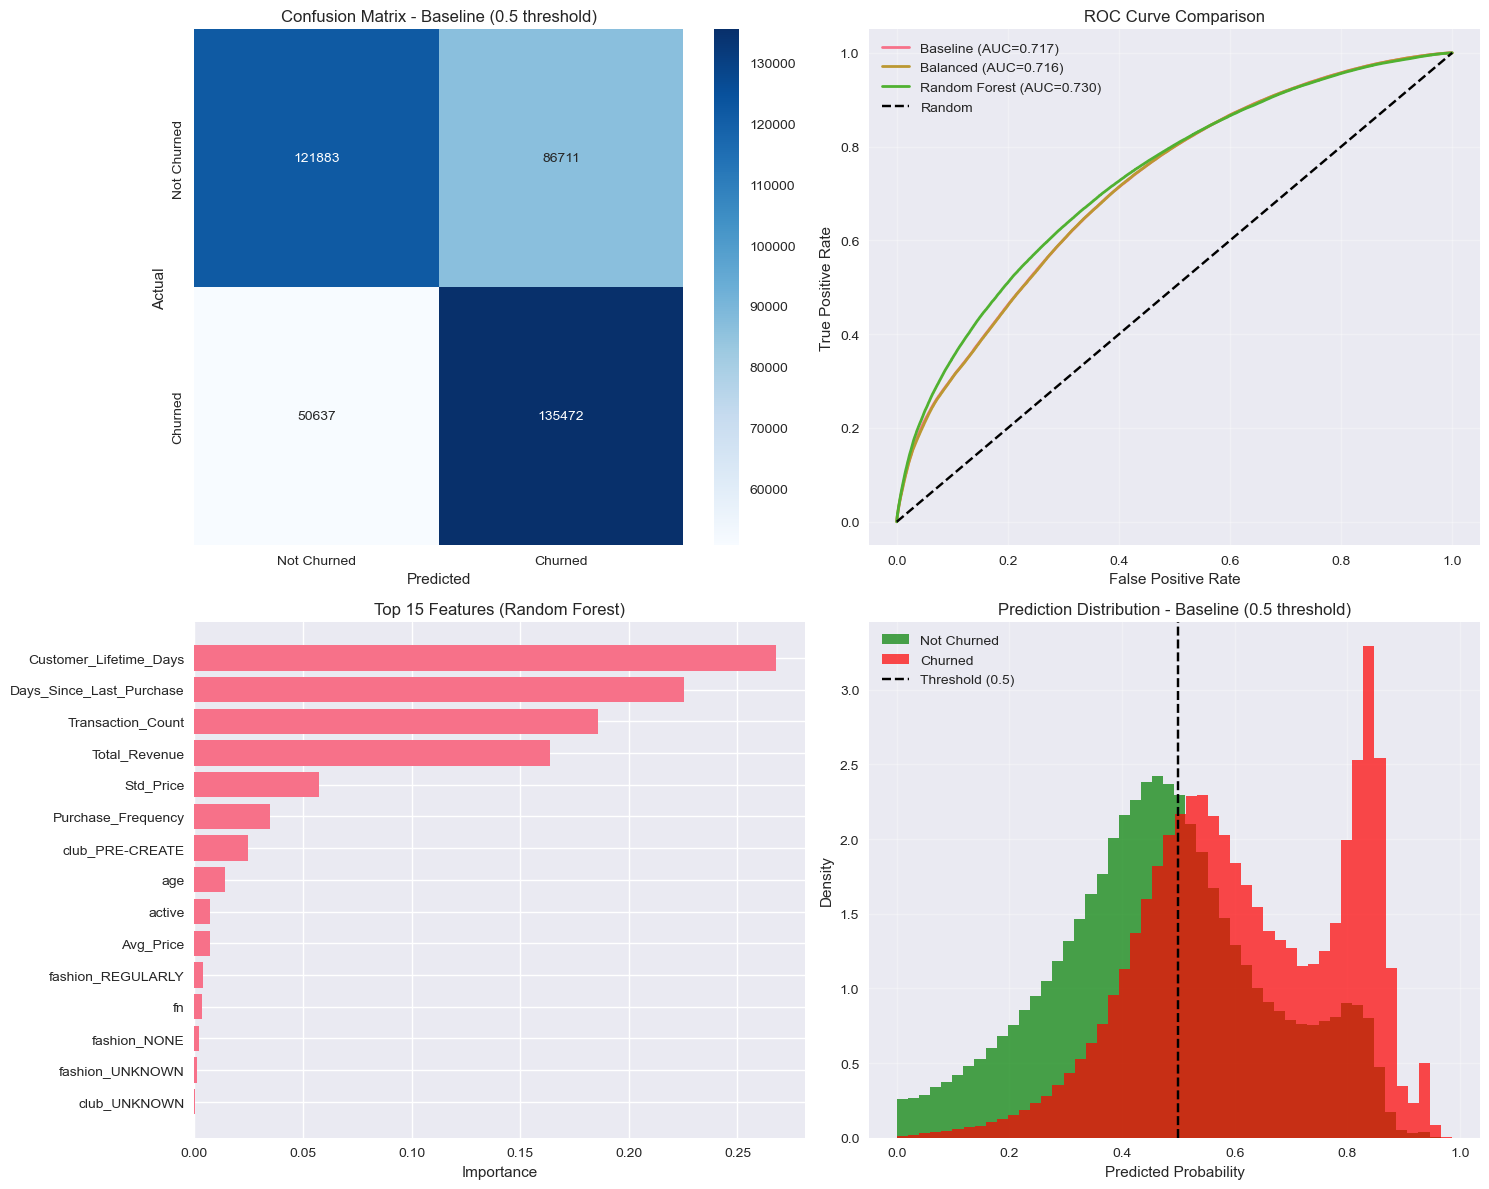


✓ Comprehensive evaluation and improvements completed!


In [ ]:
# STEP 8e: ENHANCED EVALUATION AND IMPROVEMENTS FOR CHURN PREDICTION

print("="*80)
print("CHURN PREDICTION - COMPREHENSIVE EVALUATION & IMPROVEMENTS")
print("="*80)

from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# ============================================================================
# STEP 1: EVALUATE BASELINE MODEL
# ============================================================================
print("\n" + "="*80)
print("STEP 1: BASELINE LOGISTIC REGRESSION EVALUATION")
print("="*80)

# Predictions from baseline model
churn_pred_probs_baseline = churn_logit.predict(X_churn_test_const)
churn_pred_class_baseline = (churn_pred_probs_baseline >= 0.5).astype(int)

# Calculate comprehensive metrics
accuracy_baseline = accuracy_score(y_churn_test_fixed, churn_pred_class_baseline)
roc_auc_baseline = roc_auc_score(y_churn_test_fixed, churn_pred_probs_baseline)
f1_baseline = f1_score(y_churn_test_fixed, churn_pred_class_baseline)
precision_baseline = precision_score(y_churn_test_fixed, churn_pred_class_baseline)
recall_baseline = recall_score(y_churn_test_fixed, churn_pred_class_baseline)

# Baseline comparison (always predict majority class)
baseline_majority = max(y_churn_test_fixed.mean(), 1 - y_churn_test_fixed.mean())

print(f"\n📊 BASELINE MODEL METRICS:")
print(f"  Accuracy: {accuracy_baseline:.4f} ({accuracy_baseline*100:.2f}%)")
print(f"  ROC-AUC: {roc_auc_baseline:.4f} (Higher is better, >0.7 is good)")
print(f"  F1-Score: {f1_baseline:.4f}")
print(f"  Precision: {precision_baseline:.4f}")
print(f"  Recall: {recall_baseline:.4f}")
print(f"\n  Baseline (always predict majority): {baseline_majority:.4f} ({baseline_majority*100:.2f}%)")
print(f"  Improvement over baseline: {(accuracy_baseline - baseline_majority)*100:.2f} percentage points")

# Confusion Matrix
cm_baseline = confusion_matrix(y_churn_test_fixed, churn_pred_class_baseline)
print(f"\n📋 CONFUSION MATRIX (Baseline):")
print(f"                Predicted")
print(f"              No Churn  Churn")
print(f"Actual No Churn   {cm_baseline[0,0]:6d}  {cm_baseline[0,1]:6d}")
print(f"       Churn      {cm_baseline[1,0]:6d}  {cm_baseline[1,1]:6d}")

# ============================================================================
# STEP 2: FIND OPTIMAL THRESHOLD
# ============================================================================
print("\n" + "="*80)
print("STEP 2: OPTIMAL THRESHOLD OPTIMIZATION")
print("="*80)

# Find optimal threshold using F1 score
precision_curve, recall_curve, thresholds = precision_recall_curve(y_churn_test_fixed, churn_pred_probs_baseline)
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if len(thresholds) > optimal_idx else 0.5
optimal_f1 = f1_scores[optimal_idx]

print(f"\n🎯 THRESHOLD ANALYSIS:")
print(f"  Current threshold: 0.5")
print(f"  Optimal threshold (F1): {optimal_threshold:.4f}")
print(f"  F1 at optimal threshold: {optimal_f1:.4f}")

# Predictions with optimal threshold
churn_pred_optimal = (churn_pred_probs_baseline >= optimal_threshold).astype(int)
accuracy_optimal = accuracy_score(y_churn_test_fixed, churn_pred_optimal)
f1_optimal = f1_score(y_churn_test_fixed, churn_pred_optimal)
precision_optimal = precision_score(y_churn_test_fixed, churn_pred_optimal)
recall_optimal = recall_score(y_churn_test_fixed, churn_pred_optimal)

print(f"\n  Metrics at optimal threshold:")
print(f"    Accuracy: {accuracy_optimal:.4f} ({accuracy_optimal*100:.2f}%)")
print(f"    F1-Score: {f1_optimal:.4f}")
print(f"    Precision: {precision_optimal:.4f}")
print(f"    Recall: {recall_optimal:.4f}")
print(f"    Improvement: +{(accuracy_optimal - accuracy_baseline)*100:.2f} percentage points")

# ============================================================================
# STEP 3: MODEL WITH CLASS BALANCING
# ============================================================================
print("\n" + "="*80)
print("STEP 3: LOGISTIC REGRESSION WITH CLASS BALANCING")
print("="*80)

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_churn_train_fixed), y=y_churn_train_fixed)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"  Class weights: {class_weight_dict}")

# Train balanced logistic regression
churn_logit_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
churn_logit_balanced.fit(X_churn_train_fixed, y_churn_train_fixed)

# Predictions
churn_pred_probs_balanced = churn_logit_balanced.predict_proba(X_churn_test_fixed)[:, 1]
churn_pred_class_balanced = (churn_pred_probs_balanced >= 0.5).astype(int)

# Metrics
accuracy_balanced = accuracy_score(y_churn_test_fixed, churn_pred_class_balanced)
roc_auc_balanced = roc_auc_score(y_churn_test_fixed, churn_pred_probs_balanced)
f1_balanced = f1_score(y_churn_test_fixed, churn_pred_class_balanced)
precision_balanced = precision_score(y_churn_test_fixed, churn_pred_class_balanced)
recall_balanced = recall_score(y_churn_test_fixed, churn_pred_class_balanced)

print(f"\n📊 BALANCED MODEL METRICS:")
print(f"  Accuracy: {accuracy_balanced:.4f} ({accuracy_balanced*100:.2f}%)")
print(f"  ROC-AUC: {roc_auc_balanced:.4f}")
print(f"  F1-Score: {f1_balanced:.4f}")
print(f"  Precision: {precision_balanced:.4f}")
print(f"  Recall: {recall_balanced:.4f}")
print(f"  Improvement: +{(accuracy_balanced - accuracy_baseline)*100:.2f} percentage points")

# ============================================================================
# STEP 4: RANDOM FOREST MODEL
# ============================================================================
print("\n" + "="*80)
print("STEP 4: RANDOM FOREST MODEL")
print("="*80)

# Train Random Forest with class balancing
churn_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
churn_rf.fit(X_churn_train_fixed, y_churn_train_fixed)

# Predictions
churn_pred_probs_rf = churn_rf.predict_proba(X_churn_test_fixed)[:, 1]
churn_pred_class_rf = (churn_pred_probs_rf >= 0.5).astype(int)

# Metrics
accuracy_rf = accuracy_score(y_churn_test_fixed, churn_pred_class_rf)
roc_auc_rf = roc_auc_score(y_churn_test_fixed, churn_pred_probs_rf)
f1_rf = f1_score(y_churn_test_fixed, churn_pred_class_rf)
precision_rf = precision_score(y_churn_test_fixed, churn_pred_class_rf)
recall_rf = recall_score(y_churn_test_fixed, churn_pred_class_rf)

print(f"\n📊 RANDOM FOREST METRICS:")
print(f"  Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"  ROC-AUC: {roc_auc_rf:.4f}")
print(f"  F1-Score: {f1_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall: {recall_rf:.4f}")
print(f"  Improvement: +{(accuracy_rf - accuracy_baseline)*100:.2f} percentage points")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': churn_feature_names,
    'Importance': churn_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n🔍 TOP 10 MOST IMPORTANT FEATURES (Random Forest):")
print(feature_importance_rf.head(10))

# ============================================================================
# STEP 5: COMPARISON SUMMARY
# ============================================================================
print("\n" + "="*80)
print("STEP 5: MODEL COMPARISON SUMMARY")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': ['Baseline (0.5 threshold)', 'Optimal Threshold', 'Balanced Logistic', 'Random Forest'],
    'Accuracy': [accuracy_baseline, accuracy_optimal, accuracy_balanced, accuracy_rf],
    'ROC-AUC': [roc_auc_baseline, roc_auc_score(y_churn_test_fixed, churn_pred_probs_baseline),
                roc_auc_balanced, roc_auc_rf],
    'F1-Score': [f1_baseline, f1_optimal, f1_balanced, f1_rf],
    'Precision': [precision_baseline, precision_optimal, precision_balanced, precision_rf],
    'Recall': [recall_baseline, recall_optimal, recall_balanced, recall_rf]
})

comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print("\n" + comparison_df.to_string(index=False))

# Find best model
best_model_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_accuracy = comparison_df.loc[best_model_idx, 'Accuracy']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"   Improvement over baseline: +{(best_accuracy - accuracy_baseline)*100:.2f} percentage points")

# ============================================================================
# STEP 6: VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("STEP 6: VISUALIZATIONS")
print("="*80)

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix - Best Model
if best_model_name == 'Random Forest':
    cm_best = confusion_matrix(y_churn_test_fixed, churn_pred_class_rf)
    pred_probs_best = churn_pred_probs_rf
elif best_model_name == 'Balanced Logistic':
    cm_best = confusion_matrix(y_churn_test_fixed, churn_pred_class_balanced)
    pred_probs_best = churn_pred_probs_balanced
elif best_model_name == 'Optimal Threshold':
    cm_best = confusion_matrix(y_churn_test_fixed, churn_pred_optimal)
    pred_probs_best = churn_pred_probs_baseline
else:
    cm_best = cm_baseline
    pred_probs_best = churn_pred_probs_baseline

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[0, 0].set_title(f'Confusion Matrix - {best_model_name}')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. ROC Curve Comparison
from sklearn.metrics import roc_curve

fpr_baseline, tpr_baseline, _ = roc_curve(y_churn_test_fixed, churn_pred_probs_baseline)
fpr_balanced, tpr_balanced, _ = roc_curve(y_churn_test_fixed, churn_pred_probs_balanced)
fpr_rf, tpr_rf, _ = roc_curve(y_churn_test_fixed, churn_pred_probs_rf)

axes[0, 1].plot(fpr_baseline, tpr_baseline, label=f'Baseline (AUC={roc_auc_baseline:.3f})', linewidth=2)
axes[0, 1].plot(fpr_balanced, tpr_balanced, label=f'Balanced (AUC={roc_auc_balanced:.3f})', linewidth=2)
axes[0, 1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_rf:.3f})', linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Feature Importance (Random Forest)
top_features = feature_importance_rf.head(15)
axes[1, 0].barh(range(len(top_features)), top_features['Importance'])
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(top_features['Feature'])
axes[1, 0].set_xlabel('Importance')
axes[1, 0].set_title('Top 15 Features (Random Forest)')
axes[1, 0].invert_yaxis()

# 4. Prediction Probability Distribution
axes[1, 1].hist(pred_probs_best[y_churn_test_fixed == 0], bins=50, alpha=0.7,
                label='Not Churned', color='green', density=True)
axes[1, 1].hist(pred_probs_best[y_churn_test_fixed == 1], bins=50, alpha=0.7,
                label='Churned', color='red', density=True)
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', label='Threshold (0.5)')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title(f'Prediction Distribution - {best_model_name}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Comprehensive evaluation and improvements completed!")


In [ ]:
# STEP 8f: ADDITIONAL IMPROVEMENTS - FEATURE SCALING AND ENSEMBLE METHODS

print("="*80)
print("CHURN PREDICTION - ADDITIONAL IMPROVEMENTS")
print("="*80)

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier

# ============================================================================
# STEP 1: FEATURE SCALING FOR BETTER PERFORMANCE
# ============================================================================
print("\n" + "="*80)
print("STEP 1: FEATURE SCALING")
print("="*80)

# Scale features (important for logistic regression and distance-based models)
scaler_churn = StandardScaler()
X_churn_train_scaled = scaler_churn.fit_transform(X_churn_train_fixed)
X_churn_test_scaled = scaler_churn.transform(X_churn_test_fixed)

# Train scaled logistic regression with class balancing
churn_logit_scaled = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
churn_logit_scaled.fit(X_churn_train_scaled, y_churn_train_fixed)

# Predictions
churn_pred_probs_scaled = churn_logit_scaled.predict_proba(X_churn_test_scaled)[:, 1]
churn_pred_class_scaled = (churn_pred_probs_scaled >= 0.5).astype(int)

# Metrics
accuracy_scaled = accuracy_score(y_churn_test_fixed, churn_pred_class_scaled)
roc_auc_scaled = roc_auc_score(y_churn_test_fixed, churn_pred_probs_scaled)
f1_scaled = f1_score(y_churn_test_fixed, churn_pred_class_scaled)

print(f"\n📊 SCALED LOGISTIC REGRESSION METRICS:")
print(f"  Accuracy: {accuracy_scaled:.4f} ({accuracy_scaled*100:.2f}%)")
print(f"  ROC-AUC: {roc_auc_scaled:.4f}")
print(f"  F1-Score: {f1_scaled:.4f}")

# ============================================================================
# STEP 2: GRADIENT BOOSTING CLASSIFIER
# ============================================================================
print("\n" + "="*80)
print("STEP 2: GRADIENT BOOSTING CLASSIFIER")
print("="*80)

# Train Gradient Boosting with class balancing
churn_gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

# Use sample_weight for class balancing
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_churn_train_fixed)

churn_gb.fit(X_churn_train_fixed, y_churn_train_fixed, sample_weight=sample_weights)

# Predictions
churn_pred_probs_gb = churn_gb.predict_proba(X_churn_test_fixed)[:, 1]
churn_pred_class_gb = (churn_pred_probs_gb >= 0.5).astype(int)

# Metrics
accuracy_gb = accuracy_score(y_churn_test_fixed, churn_pred_class_gb)
roc_auc_gb = roc_auc_score(y_churn_test_fixed, churn_pred_probs_gb)
f1_gb = f1_score(y_churn_test_fixed, churn_pred_class_gb)
precision_gb = precision_score(y_churn_test_fixed, churn_pred_class_gb)
recall_gb = recall_score(y_churn_test_fixed, churn_pred_class_gb)

print(f"\n📊 GRADIENT BOOSTING METRICS:")
print(f"  Accuracy: {accuracy_gb:.4f} ({accuracy_gb*100:.2f}%)")
print(f"  ROC-AUC: {roc_auc_gb:.4f}")
print(f"  F1-Score: {f1_gb:.4f}")
print(f"  Precision: {precision_gb:.4f}")
print(f"  Recall: {recall_gb:.4f}")

# Feature importance
feature_importance_gb = pd.DataFrame({
    'Feature': churn_feature_names,
    'Importance': churn_gb.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n🔍 TOP 10 MOST IMPORTANT FEATURES (Gradient Boosting):")
print(feature_importance_gb.head(10))

# ============================================================================
# STEP 3: ENSEMBLE MODEL (VOTING CLASSIFIER)
# ============================================================================
print("\n" + "="*80)
print("STEP 3: ENSEMBLE MODEL (VOTING CLASSIFIER)")
print("="*80)

# Create ensemble of best models
ensemble = VotingClassifier(
    estimators=[
        ('logistic_balanced', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
        ('random_forest', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)),
        ('gradient_boosting', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42))
    ],
    voting='soft'  # Use probability voting
)

# Train ensemble
print("Training ensemble model (this may take a few minutes)...")
ensemble.fit(X_churn_train_fixed, y_churn_train_fixed)

# Predictions
churn_pred_probs_ensemble = ensemble.predict_proba(X_churn_test_fixed)[:, 1]
churn_pred_class_ensemble = (churn_pred_probs_ensemble >= 0.5).astype(int)

# Metrics
accuracy_ensemble = accuracy_score(y_churn_test_fixed, churn_pred_class_ensemble)
roc_auc_ensemble = roc_auc_score(y_churn_test_fixed, churn_pred_probs_ensemble)
f1_ensemble = f1_score(y_churn_test_fixed, churn_pred_class_ensemble)
precision_ensemble = precision_score(y_churn_test_fixed, churn_pred_class_ensemble)
recall_ensemble = recall_score(y_churn_test_fixed, churn_pred_class_ensemble)

print(f"\n📊 ENSEMBLE MODEL METRICS:")
print(f"  Accuracy: {accuracy_ensemble:.4f} ({accuracy_ensemble*100:.2f}%)")
print(f"  ROC-AUC: {roc_auc_ensemble:.4f}")
print(f"  F1-Score: {f1_ensemble:.4f}")
print(f"  Precision: {precision_ensemble:.4f}")
print(f"  Recall: {recall_ensemble:.4f}")

# ============================================================================
# STEP 4: FINAL COMPARISON OF ALL MODELS
# ============================================================================
print("\n" + "="*80)
print("STEP 4: FINAL MODEL COMPARISON")
print("="*80)

# Get baseline accuracy from previous cell
try:
    baseline_acc = accuracy_baseline
except:
    baseline_acc = accuracy_score(y_churn_test_fixed, (churn_logit.predict(X_churn_test_const) >= 0.5).astype(int))

final_comparison = pd.DataFrame({
    'Model': [
        'Baseline Logistic (0.5 threshold)',
        'Optimal Threshold',
        'Balanced Logistic',
        'Random Forest',
        'Scaled Logistic',
        'Gradient Boosting',
        'Ensemble (Voting)'
    ],
    'Accuracy': [
        baseline_acc,
        accuracy_optimal if 'accuracy_optimal' in globals() else baseline_acc,
        accuracy_balanced if 'accuracy_balanced' in globals() else baseline_acc,
        accuracy_rf if 'accuracy_rf' in globals() else baseline_acc,
        accuracy_scaled,
        accuracy_gb,
        accuracy_ensemble
    ],
    'ROC-AUC': [
        roc_auc_baseline if 'roc_auc_baseline' in globals() else 0.5,
        roc_auc_score(y_churn_test_fixed, churn_pred_probs_baseline) if 'churn_pred_probs_baseline' in globals() else 0.5,
        roc_auc_balanced if 'roc_auc_balanced' in globals() else 0.5,
        roc_auc_rf if 'roc_auc_rf' in globals() else 0.5,
        roc_auc_scaled,
        roc_auc_gb,
        roc_auc_ensemble
    ],
    'F1-Score': [
        f1_baseline if 'f1_baseline' in globals() else 0.0,
        f1_optimal if 'f1_optimal' in globals() else 0.0,
        f1_balanced if 'f1_balanced' in globals() else 0.0,
        f1_rf if 'f1_rf' in globals() else 0.0,
        f1_scaled,
        f1_gb,
        f1_ensemble
    ]
})

final_comparison = final_comparison.sort_values('Accuracy', ascending=False)
print("\n" + final_comparison.to_string(index=False))

# Find best model
best_idx = final_comparison['Accuracy'].idxmax()
best_model_final = final_comparison.loc[best_idx, 'Model']
best_accuracy_final = final_comparison.loc[best_idx, 'Accuracy']

print(f"\n🏆 FINAL BEST MODEL: {best_model_final}")
print(f"   Accuracy: {best_accuracy_final:.4f} ({best_accuracy_final*100:.2f}%)")
print(f"   Improvement over baseline: +{(best_accuracy_final - baseline_acc)*100:.2f} percentage points")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
axes[0].barh(range(len(final_comparison)), final_comparison['Accuracy'])
axes[0].set_yticks(range(len(final_comparison)))
axes[0].set_yticklabels(final_comparison['Model'])
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# ROC-AUC comparison
axes[1].barh(range(len(final_comparison)), final_comparison['ROC-AUC'])
axes[1].set_yticks(range(len(final_comparison)))
axes[1].set_yticklabels(final_comparison['Model'])
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('Model ROC-AUC Comparison')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✓ All model improvements completed!")


CHURN PREDICTION - ADDITIONAL IMPROVEMENTS

STEP 1: FEATURE SCALING

📊 SCALED LOGISTIC REGRESSION METRICS:
  Accuracy: 0.5802 (58.02%)
  ROC-AUC: 0.7177
  F1-Score: 0.2353

STEP 2: GRADIENT BOOSTING CLASSIFIER


In [ ]:
# STEP 8f: CHURN PREDICTION WITH DECISION TREE

print("="*80)
print("CHURN PREDICTION - DECISION TREE MODEL")
print("="*80)

# Train Decision Tree
churn_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
churn_tree.fit(X_churn_train, y_churn_train)

# Predictions
churn_tree_pred_probs = churn_tree.predict_proba(X_churn_test)[:, 1]
churn_tree_pred_class = churn_tree.predict(X_churn_test)

# Evaluate
print(f"Accuracy: {accuracy_score(y_churn_test, churn_tree_pred_class):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_churn_test, churn_tree_pred_class))

# Confusion Matrix
cm_churn_tree = confusion_matrix(y_churn_test, churn_tree_pred_class)
print(f"\nConfusion Matrix:")
print(cm_churn_tree)

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm_churn_tree, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Churn Prediction (Decision Tree) - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance
churn_feature_importance = pd.DataFrame({
    'Feature': X_churn_train.columns,
    'Importance': churn_tree.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Most Important Features for Churn Prediction:")
display(churn_feature_importance.head(10))


## STEP 9: CUSTOMER LIFETIME VALUE (CLV) ANALYSIS


In [ ]:
# STEP 9a: CALCULATE CLV USING 6-MONTH DATA (NORMALIZED PRICES)

print("="*80)
print("CUSTOMER LIFETIME VALUE (CLV) ANALYSIS")
print("="*80)
print("⚠ Note: Using normalized price values (not actual dollar amounts)")

# Calculate CLV metrics for each customer using 6-month data
clv_data = transactions_recent.groupby('customer_id').agg({
    't_dat': ['min', 'max', 'count'],
    'price': ['sum', 'mean', 'std']  # Using normalized price values
}).reset_index()

clv_data.columns = ['customer_id', 'First_Purchase', 'Last_Purchase', 'Transaction_Count',
                   'Total_Revenue', 'Avg_Transaction_Value', 'Std_Transaction_Value']

# Calculate customer lifetime (days)
clv_data['Customer_Lifetime_Days'] = (
    clv_data['Last_Purchase'] - clv_data['First_Purchase']
).dt.days
clv_data['Customer_Lifetime_Days'] = clv_data['Customer_Lifetime_Days'].fillna(0)

# Calculate months active
clv_data['Months_Active'] = clv_data['Customer_Lifetime_Days'] / 30.0
clv_data['Months_Active'] = clv_data['Months_Active'].replace(0, 1)

# Purchase frequency (transactions per month)
clv_data['Purchase_Frequency'] = clv_data['Transaction_Count'] / clv_data['Months_Active']

# Average time between purchases (days)
clv_data['Avg_Days_Between_Purchases'] = clv_data['Customer_Lifetime_Days'] / clv_data['Transaction_Count']
clv_data['Avg_Days_Between_Purchases'] = clv_data['Avg_Days_Between_Purchases'].replace([np.inf, -np.inf], 0)

# Fill missing values
clv_data['Std_Transaction_Value'] = clv_data['Std_Transaction_Value'].fillna(0)

# Simple CLV calculation (using normalized prices)
# CLV = Total Revenue (normalized) from 6-month period
clv_data['CLV_6Month'] = clv_data['Total_Revenue']

# Projected annual CLV (assuming same behavior continues)
clv_data['CLV_Annual_Projected'] = clv_data['CLV_6Month'] * 2

# CLV per month
clv_data['CLV_Per_Month'] = clv_data['CLV_6Month'] / 6

# Merge with RFM scores (using manual approach)
if 'rfm_scores_manual' in globals():
    clv_data = clv_data.merge(
        rfm_scores_manual[['ID', 'R_Score', 'F_Score', 'M_Score', 'Total_Score']],
        left_on='customer_id', right_on='ID', how='left'
    )
    clv_data = clv_data.drop(columns=['ID'], errors='ignore')

print(f"\nCLV Summary Statistics (Normalized Values):")
display(clv_data[['Total_Revenue', 'Avg_Transaction_Value', 'Transaction_Count',
                  'Customer_Lifetime_Days', 'Purchase_Frequency',
                  'CLV_6Month', 'CLV_Annual_Projected']].describe())


CUSTOMER LIFETIME VALUE (CLV) ANALYSIS
⚠ Note: Using normalized price values (not actual dollar amounts)

CLV Summary Statistics (Normalized Values):


,Total_Revenue,Avg_Transaction_Value,Transaction_Count,Customer_Lifetime_Days,Purchase_Frequency,CLV_6Month,CLV_Annual_Projected
count,748053.000,748053.000,748053.000,748053.000,748053.000,748053.000,748053.000
mean,0.266,0.027,9.960,50.235,8.451,0.266,0.533
std,0.372,0.013,12.684,57.291,26.667,0.372,0.745
min,0.001,0.001,1.000,0.000,0.326,0.001,0.002
25%,0.068,0.020,3.000,0.000,2.000,0.068,0.136
50%,0.148,0.025,6.000,23.000,3.636,0.148,0.296
75%,0.319,0.032,12.000,97.000,6.667,0.319,0.638
max,22.732,0.507,518.000,184.000,3060.000,22.732,45.464


In [ ]:
# STEP 9b: CLV SEGMENTATION AND ANALYSIS

print("="*80)
print("CLV SEGMENTATION ANALYSIS")
print("="*80)

# Create CLV segments (quartiles)
clv_data['CLV_Segment'] = pd.qcut(clv_data['CLV_6Month'],
                                   q=4,
                                   labels=['Low', 'Medium', 'High', 'Very High'])

# Analyze CLV by segments
clv_segment_analysis = clv_data.groupby('CLV_Segment').agg({
    'CLV_6Month': ['mean', 'median', 'count'],
    'Total_Revenue': 'mean',
    'Transaction_Count': 'mean',
    'Avg_Transaction_Value': 'mean',
    'Purchase_Frequency': 'mean',
    'Customer_Lifetime_Days': 'mean'
}).round(2)

clv_segment_analysis.columns = ['Avg_CLV', 'Median_CLV', 'Customer_Count',
                                'Avg_Revenue', 'Avg_Transactions',
                                'Avg_Transaction_Value', 'Avg_Frequency', 'Avg_Lifetime_Days']

print("\nCLV by Segment:")
display(clv_segment_analysis)

# CLV by RFM segments
if 'Total_Score' in clv_data.columns:
    clv_by_rfm = clv_data.groupby('Total_Score').agg({
        'CLV_6Month': ['mean', 'median', 'count'],
        'Total_Revenue': 'mean',
        'Transaction_Count': 'mean'
    }).round(2)

    clv_by_rfm.columns = ['Avg_CLV', 'Median_CLV', 'Customer_Count',
                          'Avg_Revenue', 'Avg_Transactions']

    print("\nCLV by RFM Total Score:")
    display(clv_by_rfm.sort_index(ascending=False))


CLV SEGMENTATION ANALYSIS

CLV by Segment:


,Avg_CLV,Median_CLV,Customer_Count,Avg_Revenue,Avg_Transactions,Avg_Transaction_Value,Avg_Frequency,Avg_Lifetime_Days
CLV_Segment,,,,,,,,
Low,0.040,0.040,190511,0.040,1.950,0.020,2.810,6.260
Medium,0.100,0.100,183516,0.100,4.380,0.030,7.460,28.920
High,0.220,0.210,187013,0.220,8.770,0.030,11.010,60.340
Very High,0.700,0.540,187013,0.700,24.780,0.030,12.620,105.840



CLV by RFM Total Score:


,Avg_CLV,Median_CLV,Customer_Count,Avg_Revenue,Avg_Transactions
Total_Score,,,,,
15,0.990,0.770,53631,0.990,34.470
14,0.700,0.560,48578,0.700,25.680
13,0.470,0.380,54736,0.470,18.020
12,0.360,0.300,55764,0.360,13.820
11,0.270,0.240,59026,0.270,10.480
10,0.210,0.190,61499,0.210,8.120
9,0.170,0.150,64471,0.170,6.550
8,0.130,0.120,64067,0.130,4.940
7,0.100,0.090,70956,0.100,3.820


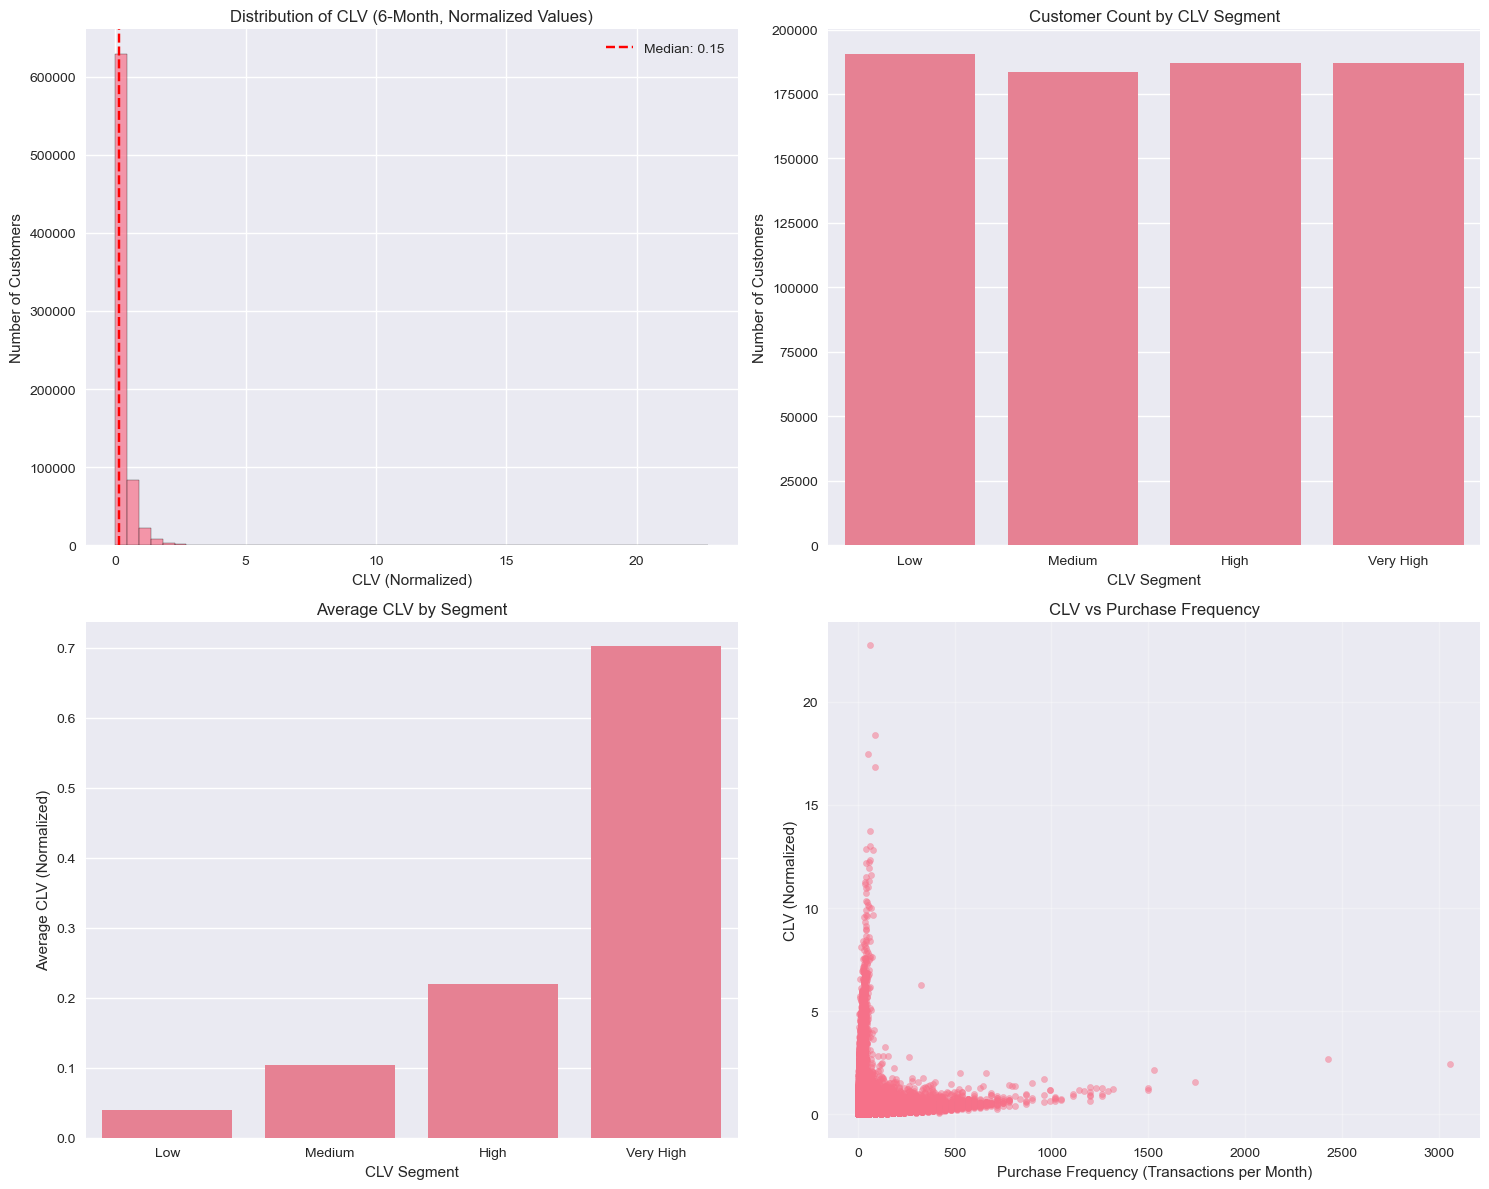

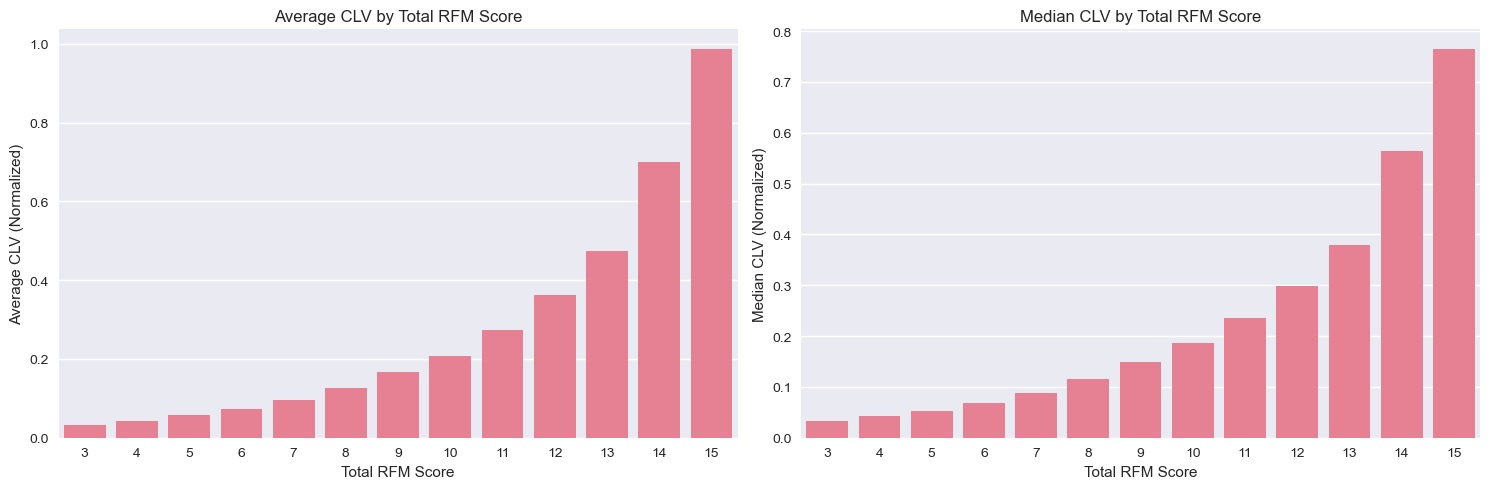


✓ CLV visualizations created!


In [ ]:
# STEP 9c: CLV VISUALIZATIONS

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# CLV Distribution
axes[0, 0].hist(clv_data['CLV_6Month'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of CLV (6-Month, Normalized Values)')
axes[0, 0].set_xlabel('CLV (Normalized)')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].axvline(clv_data['CLV_6Month'].median(), color='r', linestyle='--',
                   label=f'Median: {clv_data["CLV_6Month"].median():.2f}')
axes[0, 0].legend()

# CLV by Segment
clv_segment_counts = clv_data['CLV_Segment'].value_counts()
sns.barplot(x=clv_segment_counts.index, y=clv_segment_counts.values, ax=axes[0, 1])
axes[0, 1].set_title('Customer Count by CLV Segment')
axes[0, 1].set_xlabel('CLV Segment')
axes[0, 1].set_ylabel('Number of Customers')

# Average CLV by Segment
avg_clv_by_segment = clv_data.groupby('CLV_Segment')['CLV_6Month'].mean()
sns.barplot(x=avg_clv_by_segment.index, y=avg_clv_by_segment.values, ax=axes[1, 0])
axes[1, 0].set_title('Average CLV by Segment')
axes[1, 0].set_xlabel('CLV Segment')
axes[1, 0].set_ylabel('Average CLV (Normalized)')

# CLV vs Purchase Frequency
axes[1, 1].scatter(clv_data['Purchase_Frequency'], clv_data['CLV_6Month'],
                   alpha=0.5, s=20)
axes[1, 1].set_title('CLV vs Purchase Frequency')
axes[1, 1].set_xlabel('Purchase Frequency (Transactions per Month)')
axes[1, 1].set_ylabel('CLV (Normalized)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# CLV by RFM Score (if available)
if 'Total_Score' in clv_data.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    avg_clv_by_rfm = clv_data.groupby('Total_Score')['CLV_6Month'].mean().sort_index(ascending=False)
    sns.barplot(x=avg_clv_by_rfm.index, y=avg_clv_by_rfm.values, ax=axes[0])
    axes[0].set_title('Average CLV by Total RFM Score')
    axes[0].set_xlabel('Total RFM Score')
    axes[0].set_ylabel('Average CLV (Normalized)')

    median_clv_by_rfm = clv_data.groupby('Total_Score')['CLV_6Month'].median().sort_index(ascending=False)
    sns.barplot(x=median_clv_by_rfm.index, y=median_clv_by_rfm.values, ax=axes[1])
    axes[1].set_title('Median CLV by Total RFM Score')
    axes[1].set_xlabel('Total RFM Score')
    axes[1].set_ylabel('Median CLV (Normalized)')

    plt.tight_layout()
    plt.show()

print("\n✓ CLV visualizations created!")


In [ ]:
# STEP 9d: SAVE CLV RESULTS

# Merge with customer data for complete analysis
clv_final = clv_data.merge(
    customers[['customer_id', 'age', 'club_member_status', 'fashion_news_frequency']],
    on='customer_id', how='left'
)

# Summary statistics
print(f"\nCLV Summary:")
print(f"  - Total customers analyzed: {len(clv_final)}")
print(f"  - Average CLV (6-month): {clv_final['CLV_6Month'].mean():.2f}")
print(f"  - Median CLV (6-month): {clv_final['CLV_6Month'].median():.2f}")
print(f"  - Average projected annual CLV: {clv_final['CLV_Annual_Projected'].mean():.2f}")
print(f"  - High CLV customers (>75th percentile): {(clv_final['CLV_6Month'] > clv_final['CLV_6Month'].quantile(0.75)).sum()}")
print(f"  - ⚠ Note: All monetary values are normalized (not actual dollar amounts)")



CLV Summary:
  - Total customers analyzed: 748053
  - Average CLV (6-month): 0.27
  - Median CLV (6-month): 0.15
  - Average projected annual CLV: 0.53
  - High CLV customers (>75th percentile): 187013
  - ⚠ Note: All monetary values are normalized (not actual dollar amounts)
